<p><img alt="UdeA logo" height="250px" src="https://upload.wikimedia.org/wikipedia/commons/f/fb/Escudo-UdeA.svg" align="left" hspace="10px" ></p>

<h1><b>Practice 1 - Boltzmann constant - Experimental Physics IV<b></h1>
<div align="left+">
<h2><b>Institute of Physics<b></h2>

<font size=3>
Estiven Castrillon - estiven.castrillon2@udea.edu.co<br>
Ana Sofía Mora - ana.mora@udea.edu.co<br>
Sebastián Duque - sebastian.duque6@udea.edu.co<br>
Alejandro Arboleda - dalejandro.arboleda1@udea.edu.co<br>
</font>
</div>

# Introduction

Semiconductor devices, such as the diode, exhibit behavior governed by solid-state physics and charge transport mechanisms. Among the various external factors that significantly influence these properties is temperature, which can considerably modify the relationship between voltage and current of the device.

This experimental setup seeks to determine the Boltzmann constant, the saturation current value, and the ideality factor value of the diode through the study of the thermal dependence of the current-voltage (I-V) characteristics of a semiconductor diode when subjected to different temperatures using liquid nitrogen. Under these conditions, the voltage and current of the diode were measured to analyze how the decrease in temperature affects electrical conduction and the calculation (numerical approximation) of the aforementioned parameters.

# Theoretical framework

The Boltzmann constant is a universal constant that is fundamental in thermodynamics as it is the proportionality constant that relates entropy to the number of internal microstates of a system. It also appears in the third law of thermodynamics when approaching zero kelvin temperature. For the reasons stated above, it is of great interest to have an adequate measurement of this constant, initially introduced by Ludwig Boltzmann in [1] (English translation).

A diode is an electrical component composed of an anode (+) and a cathode (-). By having these two terminals, the diode has the ability to control the direction in which current flows, allowing current to pass when it goes from the anode to the cathode, but not in the opposite direction [2]. For this experiment, it is necessary to know the intensity of the current passing through the diode at all times, which is achieved by using Shockley's diode equation introduced in 1949 by William Bradford Shockley [3].

$$I = I_S \left (e^{\frac{qV}{nkT}} - 1 \right )$$

Where:

* $I$ is the current flowing through the diode.
* $I_S$ is the reverse saturation current or leakage current of the diode in the absence of light.
* $V$ is the voltage applied across the diode.
* $q$ is the charge of the charge carrier.
* $k$ is the Boltzmann constant.
* $T$ is the absolute temperature in Kelvin.
* $n$ is the ideality factor of the diode.

## Development

A STTH1 type semiconductor diode [4] is available, polarized at a determined voltage and current. Initially, these values were measured at room temperature (Medellín, Colombia). Subsequently, the diode was immersed in liquid nitrogen, and the voltage and current values flowing through the device were recorded as its temperature decreased. The collection of these data was done by the students using an Arduino ESP32 device and simple code using analogRead, PWM pins, and the relationship equation between current, voltage, and resistance. In addition to this, the analysis is also performed with data collected by the professor using a nanoammeter. The experimental results obtained by us students are compared with those obtained by the professor.

Image of the experimental setup with Arduino:
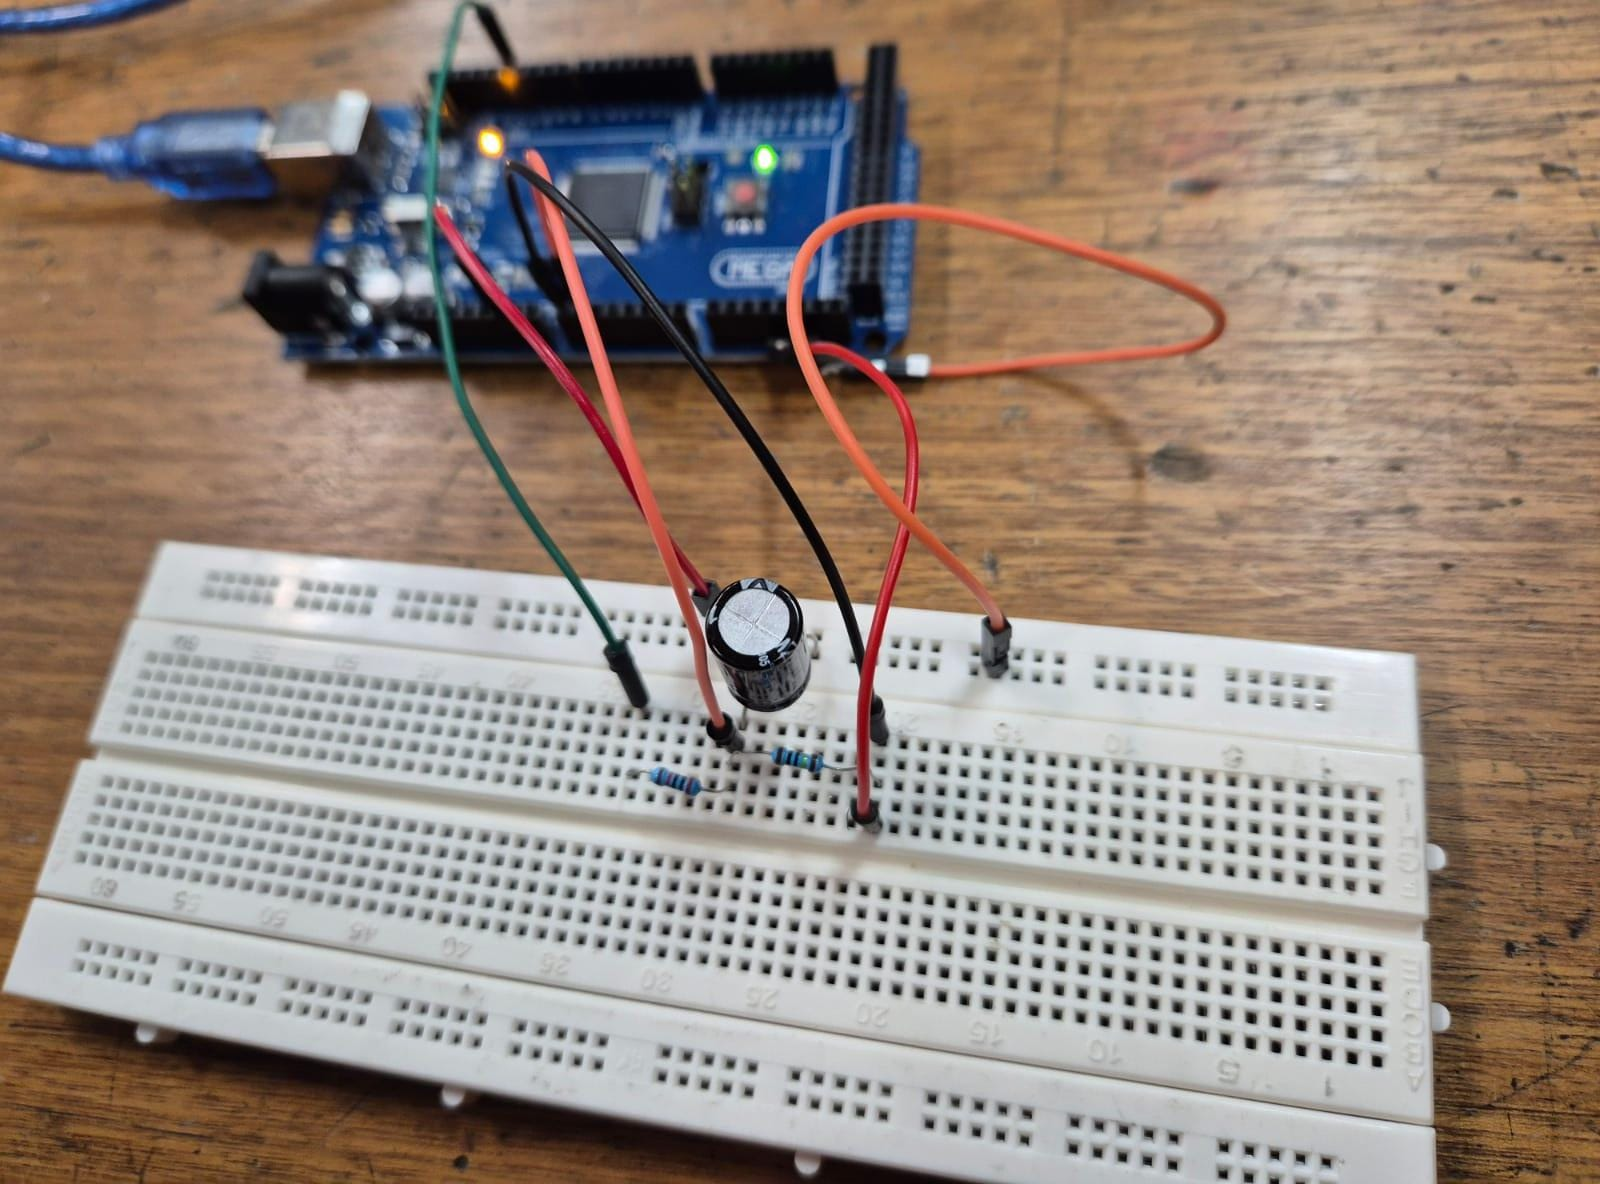

# Results

In [13]:
# Data and imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.optimize import curve_fit
from matplotlib.ticker import ScalarFormatter
from io import StringIO
from scipy.optimize import curve_fit
from scipy.stats import ks_2samp


# Plotting style
sns.set_theme(context='paper', style='whitegrid', font='serif', font_scale=1.2)
plt.rcParams.update({
    "axes.linewidth": 1.2,
    "axes.labelweight": "bold",
    "axes.grid": True,
    "grid.alpha": 0.4,
    "grid.linestyle": "--",
    "legend.frameon": True,
    "legend.edgecolor": "black",
    "legend.fancybox": False,
    "legend.fontsize": 10,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "ytick.minor.visible": True,
    "xtick.minor.visible": True,
    "figure.dpi": 150,
})

diode_room_temperature_json = StringIO('{"Vdiodo(V)":{"0":0.3519,"1":0.347,"2":0.347,"3":0.3421,"4":0.3372,"5":0.3324,"6":0.3275,"7":0.3275,"8":0.3226,"9":0.3177,"10":0.3128,"11":0.3079,"12":0.303,"13":0.2981,"14":0.2981,"15":0.2933,"16":0.2884,"17":0.2835,"18":0.2786,"19":0.2786,"20":0.2786,"21":0.2933,"22":0.2786,"23":0.2786,"24":0.2981,"25":0.2835,"26":0.2835,"27":0.303,"28":0.2835,"29":0.2835,"30":0.2884,"31":0.2884,"32":0.2884,"33":0.2884,"34":0.2933,"35":0.2933,"36":0.2933,"37":0.2933,"38":0.2981,"39":0.2933,"40":0.2981,"41":0.3128,"42":0.303,"43":0.303,"44":0.3128,"45":0.3079,"46":0.303,"47":0.3177,"48":0.3079,"49":0.3128,"50":0.3226,"51":0.3079,"52":0.3079,"53":0.3275,"54":0.3128,"55":0.3128,"56":0.3128,"57":0.3128,"58":0.3128,"59":0.3128,"60":0.3128,"61":0.3128,"62":0.3177,"63":0.3128,"64":0.3324,"65":0.3177,"66":0.3177,"67":0.3324,"68":0.3177,"69":0.3226,"70":0.3324,"71":0.3226,"72":0.3226,"73":0.3324,"74":0.3226,"75":0.3226,"76":0.3372,"77":0.3226,"78":0.3226,"79":0.3275,"80":0.3226,"81":0.3324,"82":0.3275,"83":0.3275,"84":0.3372,"85":0.3275,"86":0.3275,"87":0.3421,"88":0.3275,"89":0.3275,"90":0.3421,"91":0.3275,"92":0.3275,"93":0.3421,"94":0.3324,"95":0.3275,"96":0.3421,"97":0.3324,"98":0.3421,"99":0.347,"100":0.3324,"101":0.3421,"102":0.3324,"103":0.3324,"104":0.347,"105":0.3324,"106":0.3324,"107":0.347,"108":0.3324,"109":0.3324,"110":0.347,"111":0.3324,"112":0.3372,"113":0.347,"114":0.3324,"115":0.347,"116":0.3519,"117":0.3372,"118":0.347,"119":0.3519,"120":0.3372,"121":0.3519,"122":0.3519,"123":0.3372,"124":0.3519,"125":0.3372,"126":0.3372,"127":0.3519,"128":0.3421,"129":0.3372,"130":0.3519,"131":0.3421,"132":0.3372,"133":0.3519,"134":0.3421,"135":0.3519,"136":0.3519,"137":0.3421,"138":0.3519,"139":0.3519,"140":0.3421,"141":0.3568,"142":0.3568,"143":0.3421,"144":0.3519,"145":0.3421,"146":0.3421,"147":0.3519,"148":0.3421,"149":0.3519,"150":0.3568,"151":0.347,"152":0.3568,"153":0.3568,"154":0.3421,"155":0.3568,"156":0.3568,"157":0.3421,"158":0.3568,"159":0.3568,"160":0.3421,"161":0.3568,"162":0.347,"163":0.3421,"164":0.3568,"165":0.3421,"166":0.3568,"167":0.3568,"168":0.347,"169":0.3568,"170":0.3617,"171":0.347,"172":0.3617,"173":0.3617,"174":0.347,"175":0.3617,"176":0.3617,"177":0.347,"178":0.3617,"179":0.3617,"180":0.3568,"181":0.3617,"182":0.347,"183":0.3617,"184":0.3617,"185":0.3519,"186":0.3617,"187":0.3617,"188":0.3519,"189":0.3617,"190":0.3617,"191":0.3519,"192":0.3617,"193":0.3617,"194":0.347,"195":0.3617,"196":0.3617,"197":0.3617,"198":0.3617,"199":0.3519,"200":0.3617,"201":0.3617,"202":0.3519,"203":0.3617,"204":0.3617,"205":0.3519,"206":0.3666,"207":0.3666,"208":0.3519,"209":0.3666,"210":0.3617,"211":0.3666,"212":0.3666,"213":0.3666,"214":0.3617,"215":0.3617,"216":0.3666,"217":0.3617,"218":0.3617,"219":0.3568,"220":0.3666,"221":0.3666,"222":0.3568,"223":0.3666,"224":0.3666,"225":0.3666,"226":0.3666,"227":0.3666,"228":0.3617,"229":0.3666,"230":0.3666,"231":0.3666,"232":0.3666,"233":0.3666,"234":0.3666,"235":0.3666,"236":0.3666,"237":0.3666,"238":0.3666,"239":0.3568,"240":0.3666,"241":0.3666,"242":0.3666,"243":0.3666,"244":0.3666,"245":0.3666,"246":0.3666,"247":0.3666,"248":0.3666,"249":0.3715,"250":0.3666,"251":0.3666,"252":0.3666,"253":0.3666,"254":0.3715,"255":0.3666},"Idiodo(A)":{"0":0.00018,"1":0.000152,"2":0.000127,"3":0.000107,"4":0.00009,"5":0.000076,"6":0.000063,"7":0.000053,"8":0.000045,"9":0.000037,"10":0.000032,"11":0.000027,"12":0.000023,"13":0.00002,"14":0.000017,"15":0.000014,"16":0.000013,"17":0.000012,"18":0.000012,"19":0.00001,"20":0.00001,"21":0.00001,"22":0.000009,"23":0.000009,"24":0.000008,"25":0.000009,"26":0.000009,"27":0.000009,"28":0.00001,"29":0.000011,"30":0.000011,"31":0.000012,"32":0.000012,"33":0.000013,"34":0.000013,"35":0.000014,"36":0.000015,"37":0.000016,"38":0.000017,"39":0.000018,"40":0.000018,"41":0.00002,"42":0.00002,"43":0.000021,"44":0.000022,"45":0.000022,"46":0.000023,"47":0.000025,"48":0.000025,"49":0.000026,"50":0.000028,"51":0.000028,"52":0.000029,"53":0.000029,"54":0.00003,"55":0.000031,"56":0.000032,"57":0.000033,"58":0.000034,"59":0.000035,"60":0.000036,"61":0.000038,"62":0.000038,"63":0.000039,"64":0.00004,"65":0.000041,"66":0.000041,"67":0.000043,"68":0.000043,"69":0.000044,"70":0.000046,"71":0.000046,"72":0.000047,"73":0.000049,"74":0.000049,"75":0.00005,"76":0.00005,"77":0.000052,"78":0.000053,"79":0.000054,"80":0.000054,"81":0.000056,"82":0.000056,"83":0.000057,"84":0.000059,"85":0.000059,"86":0.00006,"87":0.000061,"88":0.000062,"89":0.000063,"90":0.000064,"91":0.000065,"92":0.000065,"93":0.000067,"94":0.000067,"95":0.000069,"96":0.00007,"97":0.00007,"98":0.000072,"99":0.000072,"100":0.000073,"101":0.000075,"102":0.000075,"103":0.000076,"104":0.000077,"105":0.000078,"106":0.000079,"107":0.00008,"108":0.000081,"109":0.000082,"110":0.000083,"111":0.000084,"112":0.000085,"113":0.000086,"114":0.000087,"115":0.000088,"116":0.000089,"117":0.000089,"118":0.000091,"119":0.000092,"120":0.000092,"121":0.000093,"122":0.000093,"123":0.000095,"124":0.000096,"125":0.000097,"126":0.000098,"127":0.000099,"128":0.000099,"129":0.0001,"130":0.000102,"131":0.000102,"132":0.000104,"133":0.000105,"134":0.000105,"135":0.000107,"136":0.000108,"137":0.000108,"138":0.000109,"139":0.000111,"140":0.000111,"141":0.000112,"142":0.000112,"143":0.000114,"144":0.000116,"145":0.000116,"146":0.000118,"147":0.000119,"148":0.000119,"149":0.00012,"150":0.000121,"151":0.000121,"152":0.000123,"153":0.000124,"154":0.000124,"155":0.000126,"156":0.000127,"157":0.000127,"158":0.000129,"159":0.000129,"160":0.00013,"161":0.000132,"162":0.000132,"163":0.000134,"164":0.000134,"165":0.000135,"166":0.000136,"167":0.000137,"168":0.000138,"169":0.000139,"170":0.00014,"171":0.000141,"172":0.000142,"173":0.000143,"174":0.000143,"175":0.000145,"176":0.000146,"177":0.000147,"178":0.000148,"179":0.000148,"180":0.00015,"181":0.00015,"182":0.000151,"183":0.000152,"184":0.000153,"185":0.000154,"186":0.000155,"187":0.000156,"188":0.000156,"189":0.000158,"190":0.000159,"191":0.000159,"192":0.000161,"193":0.000162,"194":0.000164,"195":0.000164,"196":0.000165,"197":0.000166,"198":0.000167,"199":0.000167,"200":0.000169,"201":0.00017,"202":0.00017,"203":0.000172,"204":0.000173,"205":0.000173,"206":0.000174,"207":0.000175,"208":0.000177,"209":0.000177,"210":0.000178,"211":0.000179,"212":0.00018,"213":0.000181,"214":0.000182,"215":0.000184,"216":0.000183,"217":0.000185,"218":0.000186,"219":0.000186,"220":0.000188,"221":0.000189,"222":0.00019,"223":0.000191,"224":0.000192,"225":0.000193,"226":0.000194,"227":0.000195,"228":0.000196,"229":0.000196,"230":0.000198,"231":0.000198,"232":0.000199,"233":0.000199,"234":0.000201,"235":0.000202,"236":0.000202,"237":0.000204,"238":0.000205,"239":0.000207,"240":0.000207,"241":0.000208,"242":0.000209,"243":0.00021,"244":0.000211,"245":0.000212,"246":0.000213,"247":0.000214,"248":0.000215,"249":0.000216,"250":0.000217,"251":0.000218,"252":0.000219,"253":0.00022,"254":0.00022,"255":0.000222}}')
data_1_nitrogen_json = StringIO('{"Vdiodo(V)":{"0":0.9384,"1":0.9335,"2":0.9042,"3":0.8944,"4":0.8895,"5":0.8749,"6":0.8553,"7":0.8504,"8":0.8407,"9":0.8358,"10":0.826,"11":0.8065,"12":0.7722,"13":0.7674,"14":0.6989,"15":0.6305,"16":0.2493,"17":0.1222,"18":0.4692,"19":0.5767,"20":0.5718,"21":0.5816,"22":0.6647,"23":0.7527,"24":0.6403,"25":0.3763,"26":0.1515,"27":0.3128,"28":0.5425,"29":0.567,"30":0.6012,"31":0.6256,"32":0.6305,"33":0.6354,"34":0.5572,"35":0.4643,"36":0.4594,"37":0.5816,"38":0.6549,"39":0.6745,"40":0.694,"41":0.7136,"42":0.7674,"43":0.7576,"44":0.7087,"45":0.5572,"46":0.3079,"47":0.6794,"48":0.7625,"49":0.7674,"50":0.7771,"51":0.7674,"52":0.7869,"53":0.7869,"54":0.7576,"55":0.7087,"56":0.7429,"57":0.7918,"58":0.7967,"59":0.7967,"60":0.7918,"61":0.8065,"62":0.8016,"63":0.7967,"64":0.7918,"65":0.7918,"66":0.8162,"67":0.8162,"68":0.8113,"69":0.8016,"70":0.8065,"71":0.8065,"72":0.8016,"73":0.8113,"74":0.7918,"75":0.7967,"76":0.8211,"77":0.8162,"78":0.8162,"79":0.826,"80":0.8211,"81":0.8211,"82":0.8309,"83":0.8211,"84":0.8162,"85":0.8113,"86":0.826,"87":0.826,"88":0.8309,"89":0.8309,"90":0.8309,"91":0.8309,"92":0.8309,"93":0.8358,"94":0.826,"95":0.826,"96":0.8211,"97":0.8211,"98":0.826,"99":0.8309,"100":0.8309,"101":0.8309,"102":0.826,"103":0.8309,"104":0.8309,"105":0.8456,"106":0.8407,"107":0.8407,"108":0.8504,"109":0.8602,"110":0.8651,"111":0.8504,"112":0.8602,"113":0.8504,"114":0.8504,"115":0.8504,"116":0.8553,"117":0.8553,"118":0.8407,"119":0.8456,"120":0.8456,"121":0.8358,"122":0.8504,"123":0.8407,"124":0.8602,"125":0.8749,"126":0.8602,"127":0.8651,"128":0.87,"129":0.8651,"130":0.8798,"131":0.8798,"132":0.8749,"133":0.8798,"134":0.8847,"135":0.8749,"136":0.8798,"137":0.8798,"138":0.8895,"139":0.8895,"140":0.8847,"141":0.8847,"142":0.8895,"143":0.8847,"144":0.8847,"145":0.8847,"146":0.8847,"147":0.8895,"148":0.8895,"149":0.8847,"150":0.8895,"151":0.8895,"152":0.8895,"153":0.8798,"154":0.8749,"155":0.87,"156":0.8749,"157":0.8847,"158":0.8798,"159":0.8749,"160":0.8847,"161":0.8847,"162":0.8944,"163":0.8895,"164":0.8993,"165":0.8993,"166":0.8993,"167":0.8993,"168":0.8993,"169":0.8993,"170":0.8993,"171":0.8993,"172":0.8944,"173":0.9042,"174":0.9042,"175":0.9042,"176":0.8993,"177":0.8895,"178":0.8847,"179":0.8895,"180":0.8993,"181":0.9042,"182":0.8993,"183":0.8993,"184":0.9042,"185":0.8993,"186":0.8944,"187":0.8944,"188":0.8895,"189":0.8944,"190":0.8944,"191":0.8944,"192":0.9384,"193":0.9384,"194":0.9433,"195":0.9384,"196":0.9433,"197":0.9433,"198":0.9433,"199":0.9433,"200":0.9433,"201":0.9384,"202":0.9384,"203":0.9384,"204":0.9384,"205":0.9384,"206":0.9335,"207":0.9384,"208":0.914,"209":0.9042,"210":0.9286,"211":0.9286,"212":0.9286,"213":0.9286,"214":0.9335,"215":0.9286,"216":0.9335,"217":0.9335,"218":0.9286,"219":0.9335,"220":0.9335,"221":0.9335,"222":0.9335,"223":0.9335,"224":0.9335,"225":0.9335,"226":0.9286,"227":0.9335,"228":0.9335,"229":0.9286,"230":0.9286,"231":0.9286,"232":0.9238,"233":0.9238,"234":0.9238,"235":0.9335,"236":0.9335,"237":0.9286,"238":0.9286,"239":0.9286,"240":0.9238,"241":0.9286,"242":0.9286,"243":0.9286,"244":0.9238,"245":0.9238,"246":0.9238,"247":0.9238,"248":0.9238,"249":0.9238,"250":0.9238,"251":0.9238,"252":0.9238,"253":0.9335,"254":0.9335,"255":0.9335},"Idiodo(A)":{"0":0.000156,"1":0.000127,"2":0.000104,"3":0.000083,"4":0.000066,"5":0.000052,"6":0.00004,"7":0.00003,"8":0.000021,"9":0.000014,"10":0.000008,"11":0.000004,"12":0.000001,"13":0.000002,"14":0.000002,"15":0.000001,"16":0.000016,"17":0.000021,"18":0.000002,"19":0.000004,"20":0.000004,"21":0.000005,"22":0.00001,"23":0.000014,"24":0.000008,"25":0.000005,"26":0.000016,"27":0.000009,"28":0.000002,"29":0.000003,"30":0.000004,"31":0.000005,"32":0.000004,"33":0.000004,"34":0.000001,"35":0.000006,"36":0.000007,"37":0.000002,"38":0.000001,"39":0.000001,"40":0.000001,"41":0.000001,"42":0.000003,"43":0.000001,"44":0.000002,"45":0.00001,"46":0.000024,"47":0.000006,"48":0.000003,"49":0.000003,"50":0.000004,"51":0.000005,"52":0.000005,"53":0.000007,"54":0.000009,"55":0.000012,"56":0.000012,"57":0.00001,"58":0.000011,"59":0.000012,"60":0.000013,"61":0.000013,"62":0.000014,"63":0.000015,"64":0.000017,"65":0.000018,"66":0.000017,"67":0.000019,"68":0.00002,"69":0.000021,"70":0.000022,"71":0.000023,"72":0.000024,"73":0.000025,"74":0.000026,"75":0.000027,"76":0.000027,"77":0.000028,"78":0.000029,"79":0.00003,"80":0.000031,"81":0.000031,"82":0.000033,"83":0.000033,"84":0.000035,"85":0.000036,"86":0.000036,"87":0.000038,"88":0.000038,"89":0.000039,"90":0.00004,"91":0.000041,"92":0.000042,"93":0.000043,"94":0.000044,"95":0.000045,"96":0.000047,"97":0.000047,"98":0.000048,"99":0.000049,"100":0.00005,"101":0.00005,"102":0.000052,"103":0.000053,"104":0.000054,"105":0.000054,"106":0.000055,"107":0.000056,"108":0.000057,"109":0.000057,"110":0.000058,"111":0.000059,"112":0.00006,"113":0.000062,"114":0.000063,"115":0.000063,"116":0.000065,"117":0.000065,"118":0.000066,"119":0.000068,"120":0.000068,"121":0.00007,"122":0.000071,"123":0.000072,"124":0.000072,"125":0.000072,"126":0.000074,"127":0.000075,"128":0.000076,"129":0.000076,"130":0.000077,"131":0.000078,"132":0.000078,"133":0.00008,"134":0.00008,"135":0.000082,"136":0.000083,"137":0.000084,"138":0.000084,"139":0.000085,"140":0.000086,"141":0.000087,"142":0.000088,"143":0.000089,"144":0.00009,"145":0.000091,"146":0.000092,"147":0.000093,"148":0.000094,"149":0.000095,"150":0.000096,"151":0.000097,"152":0.000097,"153":0.000099,"154":0.000101,"155":0.000101,"156":0.000102,"157":0.000103,"158":0.000103,"159":0.000105,"160":0.000106,"161":0.000107,"162":0.000108,"163":0.000108,"164":0.000109,"165":0.00011,"166":0.000111,"167":0.000112,"168":0.000113,"169":0.000113,"170":0.000115,"171":0.000116,"172":0.000117,"173":0.000118,"174":0.000119,"175":0.000119,"176":0.000121,"177":0.000122,"178":0.000123,"179":0.000124,"180":0.000124,"181":0.000125,"182":0.000127,"183":0.000127,"184":0.000128,"185":0.00013,"186":0.00013,"187":0.000132,"188":0.000133,"189":0.000133,"190":0.000135,"191":0.000136,"192":0.000134,"193":0.000135,"194":0.000136,"195":0.000137,"196":0.000137,"197":0.000138,"198":0.000139,"199":0.00014,"200":0.000141,"201":0.000142,"202":0.000143,"203":0.000144,"204":0.000145,"205":0.000146,"206":0.000147,"207":0.000148,"208":0.00015,"209":0.000152,"210":0.000152,"211":0.000153,"212":0.000153,"213":0.000154,"214":0.000156,"215":0.000156,"216":0.000157,"217":0.000158,"218":0.00016,"219":0.00016,"220":0.000161,"221":0.000162,"222":0.000163,"223":0.000164,"224":0.000165,"225":0.000166,"226":0.000167,"227":0.000168,"228":0.000169,"229":0.00017,"230":0.000172,"231":0.000173,"232":0.000174,"233":0.000175,"234":0.000176,"235":0.000176,"236":0.000177,"237":0.000178,"238":0.00018,"239":0.000181,"240":0.000182,"241":0.000183,"242":0.000184,"243":0.000185,"244":0.000186,"245":0.000187,"246":0.000188,"247":0.000189,"248":0.00019,"249":0.000191,"250":0.000192,"251":0.000193,"252":0.000194,"253":0.000194,"254":0.000195,"255":0.000196}}')
data_2_nitrogen_json = StringIO('{"Vdiodo(V)":{"0":0.9433,"1":0.9384,"2":0.9335,"3":0.9286,"4":0.9238,"5":0.9189,"6":0.9091,"7":0.8993,"8":0.8944,"9":0.8798,"10":0.8602,"11":0.8309,"12":0.7771,"13":0.7136,"14":0.6549,"15":0.5963,"16":0.5572,"17":0.5327,"18":0.5083,"19":0.4985,"20":0.4741,"21":0.4741,"22":0.4643,"23":0.4692,"24":0.4594,"25":0.4692,"26":0.479,"27":0.4839,"28":0.4985,"29":0.5083,"30":0.5083,"31":0.5327,"32":0.5425,"33":0.5523,"34":0.5767,"35":0.5718,"36":0.5963,"37":0.6305,"38":0.6354,"39":0.6549,"40":0.6794,"41":0.6891,"42":0.7087,"43":0.7331,"44":0.7429,"45":0.7722,"46":0.782,"47":0.7918,"48":0.8113,"49":0.8016,"50":0.8016,"51":0.8113,"52":0.8016,"53":0.8162,"54":0.826,"55":0.8211,"56":0.8211,"57":0.826,"58":0.8113,"59":0.8065,"60":0.8113,"61":0.8016,"62":0.8065,"63":0.8162,"64":0.8113,"65":0.8065,"66":0.8162,"67":0.8113,"68":0.8211,"69":0.8113,"70":0.8113,"71":0.8162,"72":0.8065,"73":0.8162,"74":0.8211,"75":0.9042,"76":0.9042,"77":0.9091,"78":0.8895,"79":0.8847,"80":0.9042,"81":0.8993,"82":0.8993,"83":0.9091,"84":0.9091,"85":0.914,"86":0.9091,"87":0.914,"88":0.9091,"89":0.8847,"90":0.9042,"91":0.9042,"92":0.9042,"93":0.8895,"94":0.8798,"95":0.8944,"96":0.9042,"97":0.9091,"98":0.9042,"99":0.9042,"100":0.9091,"101":0.9042,"102":0.9091,"103":0.914,"104":0.9091,"105":0.9189,"106":0.914,"107":0.914,"108":0.9189,"109":0.9189,"110":0.9091,"111":0.8993,"112":0.8944,"113":0.8944,"114":0.8993,"115":0.8944,"116":0.8944,"117":0.9238,"118":0.914,"119":0.9042,"120":0.9238,"121":0.9238,"122":0.9189,"123":0.9286,"124":0.9238,"125":0.9238,"126":0.9238,"127":0.9238,"128":0.9286,"129":0.9286,"130":0.9189,"131":0.9286,"132":0.9335,"133":0.9238,"134":0.9286,"135":0.9286,"136":0.9238,"137":0.9286,"138":0.9286,"139":0.9238,"140":0.9335,"141":0.9286,"142":0.9335,"143":0.9286,"144":0.9286,"145":0.9286,"146":0.9335,"147":0.9286,"148":0.9335,"149":0.9335,"150":0.9286,"151":0.9335,"152":0.9335,"153":0.9335,"154":0.9384,"155":0.9335,"156":0.9286,"157":0.9384,"158":0.9335,"159":0.9335,"160":0.9384,"161":0.9335,"162":0.9384,"163":0.9384,"164":0.9335,"165":0.9384,"166":0.9335,"167":0.9335,"168":0.9384,"169":0.9384,"170":0.9335,"171":0.9335,"172":0.9433,"173":0.9335,"174":0.9384,"175":0.9384,"176":0.9384,"177":0.9384,"178":0.9335,"179":0.9384,"180":0.9384,"181":0.9384,"182":0.9384,"183":0.9384,"184":0.9384,"185":0.9433,"186":0.9384,"187":0.9384,"188":0.9384,"189":0.9384,"190":0.9384,"191":0.9384,"192":0.9433,"193":0.9384,"194":0.9433,"195":0.9384,"196":0.9433,"197":0.9384,"198":0.9384,"199":0.9384,"200":0.9433,"201":0.9384,"202":0.9433,"203":0.9433,"204":0.9384,"205":0.9433,"206":0.9433,"207":0.9433,"208":0.9433,"209":0.9433,"210":0.9433,"211":0.9482,"212":0.9433,"213":0.9433,"214":0.9433,"215":0.9433,"216":0.9433,"217":0.9433,"218":0.9384,"219":0.9433,"220":0.9433,"221":0.9433,"222":0.9433,"223":0.9433,"224":0.9482,"225":0.9482,"226":0.9433,"227":0.9482,"228":0.9433,"229":0.9433,"230":0.9482,"231":0.9433,"232":0.9433,"233":0.9433,"234":0.9433,"235":0.9433,"236":0.9433,"237":0.9482,"238":0.9433,"239":0.9433,"240":0.9433,"241":0.9433,"242":0.9433,"243":0.9433,"244":0.9482,"245":0.9482,"246":0.9433,"247":0.9433,"248":0.9482,"249":0.9433,"250":0.9433,"251":0.9433,"252":0.9482,"253":0.9482,"254":0.9482,"255":0.9482},"Idiodo(A)":{"0":0.000156,"1":0.000126,"2":0.000101,"3":0.000081,"4":0.000064,"5":0.000049,"6":0.000036,"7":0.000026,"8":0.000018,"9":0.000011,"10":0.000006,"11":0.000002,"12":0.0,"13":0.0,"14":0.0,"15":0.0,"16":0.0,"17":0.0,"18":0.0,"19":0.0,"20":0.0,"21":0.0,"22":0.0,"23":0.0,"24":0.0,"25":0.0,"26":0.0,"27":0.0,"28":0.0,"29":0.0,"30":0.0,"31":0.0,"32":0.0,"33":0.0,"34":0.0,"35":0.000001,"36":0.0,"37":0.0,"38":0.0,"39":0.0,"40":0.0,"41":0.0,"42":0.0,"43":0.0,"44":0.0,"45":0.0,"46":0.0,"47":0.0,"48":0.000001,"49":0.000002,"50":0.000003,"51":0.000004,"52":0.000005,"53":0.000005,"54":0.000006,"55":0.000006,"56":0.000007,"57":0.000009,"58":0.00001,"59":0.000011,"60":0.000012,"61":0.000013,"62":0.000014,"63":0.000014,"64":0.000016,"65":0.000017,"66":0.000017,"67":0.000019,"68":0.000019,"69":0.000021,"70":0.000021,"71":0.000022,"72":0.000024,"73":0.000024,"74":0.000025,"75":0.000022,"76":0.000022,"77":0.000024,"78":0.000025,"79":0.000026,"80":0.000027,"81":0.000028,"82":0.000029,"83":0.000029,"84":0.00003,"85":0.000031,"86":0.000032,"87":0.000033,"88":0.000034,"89":0.000036,"90":0.000036,"91":0.000037,"92":0.000038,"93":0.000039,"94":0.000042,"95":0.000041,"96":0.000042,"97":0.000043,"98":0.000044,"99":0.000044,"100":0.000046,"101":0.000047,"102":0.000048,"103":0.000049,"104":0.000049,"105":0.00005,"106":0.000051,"107":0.000052,"108":0.000053,"109":0.000054,"110":0.000055,"111":0.000057,"112":0.000058,"113":0.000059,"114":0.00006,"115":0.000061,"116":0.000062,"117":0.000062,"118":0.000063,"119":0.000064,"120":0.000065,"121":0.000065,"122":0.000066,"123":0.000067,"124":0.000068,"125":0.000069,"126":0.00007,"127":0.000071,"128":0.000072,"129":0.000073,"130":0.000074,"131":0.000075,"132":0.000075,"133":0.000076,"134":0.000077,"135":0.000078,"136":0.000079,"137":0.000081,"138":0.000081,"139":0.000083,"140":0.000083,"141":0.000084,"142":0.000085,"143":0.000087,"144":0.000087,"145":0.000088,"146":0.000089,"147":0.000089,"148":0.000091,"149":0.000092,"150":0.000092,"151":0.000094,"152":0.000095,"153":0.000095,"154":0.000097,"155":0.000097,"156":0.000098,"157":0.000099,"158":0.0001,"159":0.000101,"160":0.000102,"161":0.000103,"162":0.000104,"163":0.000105,"164":0.000106,"165":0.000107,"166":0.000108,"167":0.000109,"168":0.00011,"169":0.000111,"170":0.000112,"171":0.000113,"172":0.000113,"173":0.000115,"174":0.000116,"175":0.000116,"176":0.000118,"177":0.000119,"178":0.00012,"179":0.00012,"180":0.000121,"181":0.000122,"182":0.000123,"183":0.000124,"184":0.000125,"185":0.000126,"186":0.000127,"187":0.000128,"188":0.000129,"189":0.00013,"190":0.000131,"191":0.000132,"192":0.000132,"193":0.000134,"194":0.000134,"195":0.000135,"196":0.000137,"197":0.000138,"198":0.000138,"199":0.00014,"200":0.000141,"201":0.000141,"202":0.000142,"203":0.000143,"204":0.000144,"205":0.000145,"206":0.000146,"207":0.000147,"208":0.000148,"209":0.000149,"210":0.00015,"211":0.000151,"212":0.000152,"213":0.000153,"214":0.000153,"215":0.000154,"216":0.000156,"217":0.000157,"218":0.000158,"219":0.000159,"220":0.000159,"221":0.000161,"222":0.000162,"223":0.000163,"224":0.000163,"225":0.000164,"226":0.000165,"227":0.000166,"228":0.000167,"229":0.000168,"230":0.000169,"231":0.00017,"232":0.000171,"233":0.000172,"234":0.000174,"235":0.000174,"236":0.000175,"237":0.000176,"238":0.000177,"239":0.000178,"240":0.000179,"241":0.00018,"242":0.000181,"243":0.000182,"244":0.000183,"245":0.000184,"246":0.000185,"247":0.000186,"248":0.000187,"249":0.000188,"250":0.000189,"251":0.00019,"252":0.000191,"253":0.000192,"254":0.000193,"255":0.000194}}')
data_3_nitrogen_json = StringIO('{"Vdiodo(V)":{"0":0.9433,"1":0.9384,"2":0.9384,"3":0.9335,"4":0.9238,"5":0.9238,"6":0.9189,"7":0.9091,"8":0.8993,"9":0.8944,"10":0.8749,"11":0.8407,"12":0.7869,"13":0.7087,"14":0.65,"15":0.5963,"16":0.5621,"17":0.5327,"18":0.5083,"19":0.4936,"20":0.4741,"21":0.4741,"22":0.4692,"23":0.4643,"24":0.4594,"25":0.4643,"26":0.4692,"27":0.4839,"28":0.4985,"29":0.4985,"30":0.5083,"31":0.5279,"32":0.5572,"33":0.567,"34":0.5767,"35":0.5767,"36":0.6109,"37":0.6256,"38":0.6403,"39":0.6647,"40":0.6696,"41":0.6891,"42":0.7185,"43":0.7185,"44":0.7429,"45":0.7625,"46":0.7771,"47":0.7967,"48":0.8065,"49":0.8162,"50":0.826,"51":0.8358,"52":0.8309,"53":0.8407,"54":0.8456,"55":0.8309,"56":0.8309,"57":0.8407,"58":0.8309,"59":0.8407,"60":0.8651,"61":0.8651,"62":0.87,"63":0.8798,"64":0.8798,"65":0.8798,"66":0.8847,"67":0.8798,"68":0.8895,"69":0.8895,"70":0.8895,"71":0.8944,"72":0.8944,"73":0.8944,"74":0.8993,"75":0.8993,"76":0.8993,"77":0.9042,"78":0.8993,"79":0.8993,"80":0.9091,"81":0.8993,"82":0.9042,"83":0.9091,"84":0.9042,"85":0.9091,"86":0.914,"87":0.9091,"88":0.9091,"89":0.9091,"90":0.9042,"91":0.9091,"92":0.9091,"93":0.914,"94":0.914,"95":0.9091,"96":0.9091,"97":0.9091,"98":0.8993,"99":0.9091,"100":0.9091,"101":0.9091,"102":0.9091,"103":0.914,"104":0.914,"105":0.914,"106":0.9189,"107":0.914,"108":0.9189,"109":0.9189,"110":0.914,"111":0.9189,"112":0.9238,"113":0.914,"114":0.9238,"115":0.9189,"116":0.914,"117":0.9189,"118":0.9189,"119":0.914,"120":0.9189,"121":0.9189,"122":0.914,"123":0.9238,"124":0.9189,"125":0.914,"126":0.9189,"127":0.9189,"128":0.9189,"129":0.9238,"130":0.9189,"131":0.9238,"132":0.9238,"133":0.9238,"134":0.9238,"135":0.9238,"136":0.9189,"137":0.9238,"138":0.9286,"139":0.9286,"140":0.9335,"141":0.9335,"142":0.9335,"143":0.9384,"144":0.9286,"145":0.9286,"146":0.9286,"147":0.9286,"148":0.9335,"149":0.9335,"150":0.9286,"151":0.9335,"152":0.9384,"153":0.9335,"154":0.9384,"155":0.9384,"156":0.9335,"157":0.9384,"158":0.9384,"159":0.9335,"160":0.9384,"161":0.9335,"162":0.9384,"163":0.9384,"164":0.9335,"165":0.9384,"166":0.9384,"167":0.9335,"168":0.9384,"169":0.9335,"170":0.9335,"171":0.9384,"172":0.9384,"173":0.9335,"174":0.9384,"175":0.9335,"176":0.9286,"177":0.9335,"178":0.9335,"179":0.9335,"180":0.9335,"181":0.9286,"182":0.9335,"183":0.9335,"184":0.9286,"185":0.9335,"186":0.9384,"187":0.9335,"188":0.9335,"189":0.9384,"190":0.9335,"191":0.9384,"192":0.9384,"193":0.9384,"194":0.9384,"195":0.9384,"196":0.9384,"197":0.9384,"198":0.9335,"199":0.9384,"200":0.9384,"201":0.9335,"202":0.9384,"203":0.9384,"204":0.9384,"205":0.9384,"206":0.9384,"207":0.9384,"208":0.9384,"209":0.9433,"210":0.9433,"211":0.9384,"212":0.9433,"213":0.9433,"214":0.9433,"215":0.9433,"216":0.9433,"217":0.9433,"218":0.9384,"219":0.9482,"220":0.9433,"221":0.9433,"222":0.9433,"223":0.9433,"224":0.9433,"225":0.9433,"226":0.9433,"227":0.9433,"228":0.9433,"229":0.9433,"230":0.9433,"231":0.9433,"232":0.9433,"233":0.9433,"234":0.9482,"235":0.9433,"236":0.9482,"237":0.9433,"238":0.9433,"239":0.9482,"240":0.9482,"241":0.9482,"242":0.9433,"243":0.9482,"244":0.9433,"245":0.9482,"246":0.9482,"247":0.9482,"248":0.9482,"249":0.9482,"250":0.9482,"251":0.9482,"252":0.9482,"253":0.9482,"254":0.9482,"255":0.9482},"Idiodo(A)":{"0":0.000156,"1":0.000126,"2":0.000101,"3":0.000081,"4":0.000064,"5":0.000048,"6":0.000036,"7":0.000026,"8":0.000017,"9":0.00001,"10":0.000005,"11":0.000001,"12":0.0,"13":0.0,"14":0.0,"15":0.0,"16":0.0,"17":0.0,"18":0.0,"19":0.0,"20":0.0,"21":0.0,"22":0.0,"23":0.0,"24":0.0,"25":0.0,"26":0.0,"27":0.0,"28":0.0,"29":0.0,"30":0.000001,"31":0.0,"32":0.000001,"33":0.0,"34":0.0,"35":0.0,"36":0.0,"37":0.0,"38":0.0,"39":0.0,"40":0.0,"41":0.0,"42":0.0,"43":0.0,"44":0.0,"45":0.0,"46":0.0,"47":0.0,"48":0.000001,"49":0.000001,"50":0.000001,"51":0.000002,"52":0.000003,"53":0.000003,"54":0.000005,"55":0.000006,"56":0.000007,"57":0.000008,"58":0.000009,"59":0.000009,"60":0.000009,"61":0.00001,"62":0.00001,"63":0.000011,"64":0.000012,"65":0.000013,"66":0.000014,"67":0.000015,"68":0.000016,"69":0.000017,"70":0.000017,"71":0.000019,"72":0.000019,"73":0.00002,"74":0.000021,"75":0.000022,"76":0.000022,"77":0.000024,"78":0.000025,"79":0.000025,"80":0.000027,"81":0.000028,"82":0.000028,"83":0.00003,"84":0.00003,"85":0.000031,"86":0.000032,"87":0.000033,"88":0.000034,"89":0.000035,"90":0.000036,"91":0.000037,"92":0.000038,"93":0.000038,"94":0.00004,"95":0.000041,"96":0.000041,"97":0.000043,"98":0.000044,"99":0.000044,"100":0.000046,"101":0.000046,"102":0.000047,"103":0.000049,"104":0.000049,"105":0.00005,"106":0.000051,"107":0.000052,"108":0.000053,"109":0.000054,"110":0.000055,"111":0.000056,"112":0.000056,"113":0.000058,"114":0.000059,"115":0.00006,"116":0.00006,"117":0.000062,"118":0.000063,"119":0.000063,"120":0.000065,"121":0.000065,"122":0.000066,"123":0.000067,"124":0.000068,"125":0.00007,"126":0.000071,"127":0.000071,"128":0.000072,"129":0.000073,"130":0.000074,"131":0.000075,"132":0.000076,"133":0.000076,"134":0.000078,"135":0.000079,"136":0.00008,"137":0.000081,"138":0.000081,"139":0.000082,"140":0.000083,"141":0.000084,"142":0.000085,"143":0.000086,"144":0.000087,"145":0.000088,"146":0.000089,"147":0.00009,"148":0.000091,"149":0.000092,"150":0.000092,"151":0.000094,"152":0.000095,"153":0.000095,"154":0.000096,"155":0.000097,"156":0.000098,"157":0.000099,"158":0.0001,"159":0.000101,"160":0.000102,"161":0.000103,"162":0.000104,"163":0.000105,"164":0.000106,"165":0.000107,"166":0.000108,"167":0.000109,"168":0.00011,"169":0.000111,"170":0.000111,"171":0.000113,"172":0.000114,"173":0.000114,"174":0.000116,"175":0.000117,"176":0.000118,"177":0.000119,"178":0.00012,"179":0.000121,"180":0.000122,"181":0.000123,"182":0.000124,"183":0.000125,"184":0.000126,"185":0.000127,"186":0.000128,"187":0.000128,"188":0.00013,"189":0.000131,"190":0.000131,"191":0.000132,"192":0.000133,"193":0.000134,"194":0.000135,"195":0.000136,"196":0.000137,"197":0.000138,"198":0.000139,"199":0.00014,"200":0.000141,"201":0.000142,"202":0.000143,"203":0.000144,"204":0.000144,"205":0.000146,"206":0.000147,"207":0.000148,"208":0.000149,"209":0.00015,"210":0.00015,"211":0.000152,"212":0.000152,"213":0.000153,"214":0.000154,"215":0.000155,"216":0.000156,"217":0.000157,"218":0.000158,"219":0.000159,"220":0.00016,"221":0.000161,"222":0.000162,"223":0.000163,"224":0.000163,"225":0.000165,"226":0.000166,"227":0.000167,"228":0.000168,"229":0.000169,"230":0.00017,"231":0.000171,"232":0.000171,"233":0.000173,"234":0.000173,"235":0.000174,"236":0.000175,"237":0.000176,"238":0.000177,"239":0.000178,"240":0.000179,"241":0.00018,"242":0.000181,"243":0.000182,"244":0.000183,"245":0.000184,"246":0.000185,"247":0.000186,"248":0.000187,"249":0.000188,"250":0.000189,"251":0.00019,"252":0.00019,"253":0.000192,"254":0.000193,"255":0.000193}}')
data_4_nitrogen_json = StringIO('{"Vdiodo(V)":{"0":0.9433,"1":0.9384,"2":0.9286,"3":0.9286,"4":0.9238,"5":0.9189,"6":0.914,"7":0.9091,"8":0.8993,"9":0.8847,"10":0.8749,"11":0.8407,"12":0.7771,"13":0.7087,"14":0.6452,"15":0.6061,"16":0.567,"17":0.5279,"18":0.4985,"19":0.479,"20":0.4692,"21":0.4643,"22":0.4643,"23":0.4643,"24":0.4643,"25":0.4741,"26":0.4741,"27":0.479,"28":0.4888,"29":0.4985,"30":0.5083,"31":0.5327,"32":0.5425,"33":0.5572,"34":0.567,"35":0.5963,"36":0.6012,"37":0.6207,"38":0.6354,"39":0.6452,"40":0.6794,"41":0.6891,"42":0.7038,"43":0.7234,"44":0.7429,"45":0.7674,"46":0.782,"47":0.7918,"48":0.8113,"49":0.826,"50":0.8358,"51":0.8504,"52":0.8456,"53":0.8602,"54":0.8651,"55":0.8651,"56":0.87,"57":0.8798,"58":0.8749,"59":0.8798,"60":0.8847,"61":0.8847,"62":0.8847,"63":0.8944,"64":0.8944,"65":0.8895,"66":0.8944,"67":0.8944,"68":0.8944,"69":0.8993,"70":0.8993,"71":0.8993,"72":0.9042,"73":0.8993,"74":0.9091,"75":0.9042,"76":0.9042,"77":0.9091,"78":0.9042,"79":0.9091,"80":0.914,"81":0.9091,"82":0.9091,"83":0.914,"84":0.9091,"85":0.9091,"86":0.9189,"87":0.914,"88":0.9091,"89":0.9189,"90":0.9189,"91":0.9189,"92":0.9189,"93":0.914,"94":0.9238,"95":0.9189,"96":0.9189,"97":0.9238,"98":0.9189,"99":0.9189,"100":0.9238,"101":0.9189,"102":0.9189,"103":0.9238,"104":0.9238,"105":0.9238,"106":0.9238,"107":0.9238,"108":0.9238,"109":0.9238,"110":0.9238,"111":0.9286,"112":0.9286,"113":0.9238,"114":0.9286,"115":0.9238,"116":0.9238,"117":0.9286,"118":0.9238,"119":0.9238,"120":0.9335,"121":0.9286,"122":0.9286,"123":0.9286,"124":0.9286,"125":0.9286,"126":0.9335,"127":0.9286,"128":0.9335,"129":0.9335,"130":0.9286,"131":0.9335,"132":0.9335,"133":0.9286,"134":0.9335,"135":0.9335,"136":0.9286,"137":0.9335,"138":0.9286,"139":0.9335,"140":0.9335,"141":0.9286,"142":0.9335,"143":0.9335,"144":0.9335,"145":0.9384,"146":0.9335,"147":0.9335,"148":0.9335,"149":0.9384,"150":0.9335,"151":0.9335,"152":0.9384,"153":0.9335,"154":0.9384,"155":0.9384,"156":0.9286,"157":0.9384,"158":0.9335,"159":0.9384,"160":0.9384,"161":0.9384,"162":0.9384,"163":0.9384,"164":0.9335,"165":0.9384,"166":0.9384,"167":0.9335,"168":0.9384,"169":0.9384,"170":0.9335,"171":0.9384,"172":0.9384,"173":0.9335,"174":0.9433,"175":0.9384,"176":0.9384,"177":0.9384,"178":0.9335,"179":0.9384,"180":0.9384,"181":0.9384,"182":0.9384,"183":0.9384,"184":0.9384,"185":0.9384,"186":0.9433,"187":0.9384,"188":0.9433,"189":0.9433,"190":0.9384,"191":0.9433,"192":0.9384,"193":0.9384,"194":0.9384,"195":0.9482,"196":0.9384,"197":0.9384,"198":0.9384,"199":0.9384,"200":0.9433,"201":0.9384,"202":0.9433,"203":0.9433,"204":0.9384,"205":0.9433,"206":0.9433,"207":0.9384,"208":0.9433,"209":0.9433,"210":0.9433,"211":0.9433,"212":0.9433,"213":0.9433,"214":0.9433,"215":0.9433,"216":0.9433,"217":0.9433,"218":0.9384,"219":0.9433,"220":0.9433,"221":0.9433,"222":0.9433,"223":0.9433,"224":0.9433,"225":0.9433,"226":0.9433,"227":0.9433,"228":0.9433,"229":0.9482,"230":0.9433,"231":0.9433,"232":0.9433,"233":0.9433,"234":0.9433,"235":0.9433,"236":0.9433,"237":0.9433,"238":0.9433,"239":0.9482,"240":0.9433,"241":0.9433,"242":0.9433,"243":0.9433,"244":0.9433,"245":0.9433,"246":0.9482,"247":0.9482,"248":0.9482,"249":0.9482,"250":0.9482,"251":0.9482,"252":0.9482,"253":0.9482,"254":0.9482,"255":0.9482},"Idiodo(A)":{"0":0.000155,"1":0.000126,"2":0.000101,"3":0.00008,"4":0.000063,"5":0.000048,"6":0.000036,"7":0.000026,"8":0.000017,"9":0.000011,"10":0.000005,"11":0.000001,"12":0.0,"13":0.0,"14":0.0,"15":0.0,"16":0.0,"17":0.0,"18":0.0,"19":0.000001,"20":0.0,"21":0.0,"22":0.0,"23":0.0,"24":0.0,"25":0.0,"26":0.0,"27":0.0,"28":0.0,"29":0.0,"30":0.0,"31":0.0,"32":0.0,"33":0.0,"34":0.0,"35":0.0,"36":0.0,"37":0.0,"38":0.0,"39":0.000001,"40":0.0,"41":0.0,"42":0.0,"43":0.0,"44":0.0,"45":0.0,"46":0.0,"47":0.0,"48":0.000001,"49":0.000001,"50":0.000001,"51":0.000002,"52":0.000002,"53":0.000003,"54":0.000004,"55":0.000004,"56":0.000005,"57":0.000006,"58":0.000007,"59":0.000007,"60":0.000009,"61":0.000009,"62":0.00001,"63":0.000011,"64":0.000011,"65":0.000012,"66":0.000013,"67":0.000014,"68":0.000015,"69":0.000016,"70":0.000017,"71":0.000018,"72":0.000019,"73":0.00002,"74":0.000021,"75":0.000022,"76":0.000022,"77":0.000023,"78":0.000024,"79":0.000025,"80":0.000026,"81":0.000027,"82":0.000028,"83":0.000029,"84":0.00003,"85":0.000031,"86":0.000032,"87":0.000033,"88":0.000034,"89":0.000034,"90":0.000035,"91":0.000036,"92":0.000037,"93":0.000038,"94":0.000039,"95":0.00004,"96":0.000041,"97":0.000042,"98":0.000043,"99":0.000043,"100":0.000045,"101":0.000046,"102":0.000046,"103":0.000048,"104":0.000048,"105":0.000049,"106":0.000051,"107":0.000051,"108":0.000053,"109":0.000054,"110":0.000054,"111":0.000055,"112":0.000056,"113":0.000057,"114":0.000058,"115":0.000059,"116":0.00006,"117":0.000061,"118":0.000062,"119":0.000063,"120":0.000064,"121":0.000065,"122":0.000065,"123":0.000067,"124":0.000067,"125":0.000069,"126":0.00007,"127":0.00007,"128":0.000071,"129":0.000073,"130":0.000073,"131":0.000074,"132":0.000075,"133":0.000076,"134":0.000077,"135":0.000078,"136":0.000079,"137":0.00008,"138":0.000081,"139":0.000082,"140":0.000083,"141":0.000084,"142":0.000085,"143":0.000086,"144":0.000086,"145":0.000087,"146":0.000089,"147":0.000089,"148":0.000091,"149":0.000092,"150":0.000092,"151":0.000094,"152":0.000095,"153":0.000095,"154":0.000096,"155":0.000097,"156":0.000098,"157":0.000099,"158":0.0001,"159":0.000101,"160":0.000102,"161":0.000102,"162":0.000104,"163":0.000105,"164":0.000106,"165":0.000107,"166":0.000108,"167":0.000109,"168":0.00011,"169":0.000111,"170":0.000111,"171":0.000113,"172":0.000114,"173":0.000115,"174":0.000115,"175":0.000116,"176":0.000117,"177":0.000119,"178":0.000119,"179":0.00012,"180":0.000121,"181":0.000122,"182":0.000123,"183":0.000124,"184":0.000125,"185":0.000126,"186":0.000127,"187":0.000128,"188":0.000129,"189":0.00013,"190":0.000131,"191":0.000132,"192":0.000133,"193":0.000134,"194":0.000135,"195":0.000135,"196":0.000137,"197":0.000138,"198":0.000138,"199":0.00014,"200":0.000141,"201":0.000141,"202":0.000142,"203":0.000143,"204":0.000144,"205":0.000145,"206":0.000146,"207":0.000147,"208":0.000148,"209":0.000149,"210":0.00015,"211":0.000151,"212":0.000152,"213":0.000153,"214":0.000154,"215":0.000154,"216":0.000156,"217":0.000157,"218":0.000158,"219":0.000159,"220":0.00016,"221":0.000161,"222":0.000162,"223":0.000163,"224":0.000164,"225":0.000165,"226":0.000166,"227":0.000167,"228":0.000168,"229":0.000168,"230":0.00017,"231":0.000171,"232":0.000171,"233":0.000173,"234":0.000174,"235":0.000174,"236":0.000175,"237":0.000176,"238":0.000177,"239":0.000178,"240":0.000179,"241":0.00018,"242":0.000181,"243":0.000182,"244":0.000183,"245":0.000184,"246":0.000185,"247":0.000186,"248":0.000187,"249":0.000188,"250":0.000189,"251":0.00019,"252":0.000191,"253":0.000192,"254":0.000193,"255":0.000193}}')
data_5_nitrogen_json = StringIO('{"Vdiodo(V)":{"0":0.9433,"1":0.9433,"2":0.9335,"3":0.9335,"4":0.9286,"5":0.9238,"6":0.9189,"7":0.914,"8":0.8993,"9":0.8944,"10":0.8749,"11":0.8407,"12":0.7771,"13":0.7038,"14":0.6452,"15":0.6012,"16":0.5572,"17":0.5279,"18":0.5132,"19":0.4839,"20":0.4741,"21":0.4741,"22":0.4692,"23":0.4594,"24":0.4643,"25":0.4692,"26":0.4692,"27":0.4888,"28":0.4888,"29":0.5132,"30":0.5083,"31":0.5376,"32":0.5376,"33":0.5718,"34":0.5767,"35":0.5963,"36":0.6109,"37":0.6158,"38":0.6354,"39":0.6598,"40":0.6745,"41":0.6843,"42":0.7234,"43":0.7234,"44":0.7429,"45":0.7722,"46":0.782,"47":0.7918,"48":0.826,"49":0.8309,"50":0.8358,"51":0.8602,"52":0.8553,"53":0.8602,"54":0.87,"55":0.87,"56":0.8749,"57":0.8847,"58":0.8798,"59":0.8847,"60":0.8993,"61":0.8895,"62":0.8944,"63":0.8944,"64":0.8993,"65":0.8944,"66":0.8993,"67":0.8993,"68":0.9042,"69":0.9042,"70":0.9042,"71":0.9091,"72":0.9091,"73":0.9091,"74":0.914,"75":0.9091,"76":0.9091,"77":0.914,"78":0.9091,"79":0.914,"80":0.9189,"81":0.914,"82":0.914,"83":0.9189,"84":0.914,"85":0.9189,"86":0.9238,"87":0.914,"88":0.9189,"89":0.9189,"90":0.9189,"91":0.9238,"92":0.9189,"93":0.9189,"94":0.9238,"95":0.9238,"96":0.9189,"97":0.9238,"98":0.9189,"99":0.9238,"100":0.9238,"101":0.9238,"102":0.9189,"103":0.9335,"104":0.9238,"105":0.9238,"106":0.9286,"107":0.9238,"108":0.9286,"109":0.9335,"110":0.9238,"111":0.9286,"112":0.9286,"113":0.9238,"114":0.9286,"115":0.9286,"116":0.9286,"117":0.9335,"118":0.9286,"119":0.9286,"120":0.9335,"121":0.9335,"122":0.9286,"123":0.9335,"124":0.9286,"125":0.9286,"126":0.9335,"127":0.9286,"128":0.9335,"129":0.9335,"130":0.9286,"131":0.9335,"132":0.9384,"133":0.9335,"134":0.9384,"135":0.9335,"136":0.9335,"137":0.9384,"138":0.9335,"139":0.9335,"140":0.9335,"141":0.9335,"142":0.9384,"143":0.9384,"144":0.9335,"145":0.9384,"146":0.9384,"147":0.9335,"148":0.9384,"149":0.9384,"150":0.9335,"151":0.9384,"152":0.9384,"153":0.9335,"154":0.9384,"155":0.9384,"156":0.9335,"157":0.9384,"158":0.9335,"159":0.9384,"160":0.9384,"161":0.9384,"162":0.9384,"163":0.9433,"164":0.9335,"165":0.9384,"166":0.9384,"167":0.9384,"168":0.9433,"169":0.9433,"170":0.9384,"171":0.9433,"172":0.9433,"173":0.9384,"174":0.9433,"175":0.9384,"176":0.9433,"177":0.9433,"178":0.9384,"179":0.9433,"180":0.9433,"181":0.9384,"182":0.9433,"183":0.9433,"184":0.9384,"185":0.9433,"186":0.9433,"187":0.9433,"188":0.9433,"189":0.9433,"190":0.9384,"191":0.9433,"192":0.9482,"193":0.9433,"194":0.9433,"195":0.9433,"196":0.9433,"197":0.9433,"198":0.9433,"199":0.9433,"200":0.9433,"201":0.9433,"202":0.9482,"203":0.9482,"204":0.9433,"205":0.9433,"206":0.9433,"207":0.9433,"208":0.9482,"209":0.9482,"210":0.9433,"211":0.9433,"212":0.9482,"213":0.9482,"214":0.9433,"215":0.9433,"216":0.9482,"217":0.9433,"218":0.9433,"219":0.9482,"220":0.9482,"221":0.9482,"222":0.9433,"223":0.9433,"224":0.9482,"225":0.9482,"226":0.9482,"227":0.9482,"228":0.9482,"229":0.9433,"230":0.9482,"231":0.9482,"232":0.9433,"233":0.9482,"234":0.9482,"235":0.9433,"236":0.9482,"237":0.9482,"238":0.9482,"239":0.9482,"240":0.9482,"241":0.9482,"242":0.9482,"243":0.9482,"244":0.9482,"245":0.9482,"246":0.9482,"247":0.9482,"248":0.9482,"249":0.9482,"250":0.9482,"251":0.9482,"252":0.9433,"253":0.9482,"254":0.9482,"255":0.9531},"Idiodo(A)":{"0":0.000154,"1":0.000124,"2":0.0001,"3":0.000079,"4":0.000062,"5":0.000048,"6":0.000035,"7":0.000025,"8":0.000017,"9":0.00001,"10":0.000004,"11":0.000001,"12":0.0,"13":0.0,"14":0.0,"15":0.0,"16":0.0,"17":0.0,"18":0.0,"19":0.0,"20":0.0,"21":0.0,"22":0.0,"23":0.0,"24":0.0,"25":0.0,"26":0.0,"27":0.0,"28":0.0,"29":0.0,"30":0.0,"31":0.0,"32":0.0,"33":0.0,"34":0.0,"35":0.0,"36":0.0,"37":0.0,"38":0.0,"39":0.0,"40":0.0,"41":0.0,"42":0.0,"43":0.0,"44":0.0,"45":0.0,"46":0.0,"47":0.0,"48":0.0,"49":0.0,"50":0.000001,"51":0.000001,"52":0.000002,"53":0.000002,"54":0.000004,"55":0.000004,"56":0.000005,"57":0.000005,"58":0.000006,"59":0.000007,"60":0.000007,"61":0.000009,"62":0.000009,"63":0.000011,"64":0.000011,"65":0.000012,"66":0.000013,"67":0.000014,"68":0.000015,"69":0.000016,"70":0.000016,"71":0.000018,"72":0.000018,"73":0.000019,"74":0.00002,"75":0.000021,"76":0.000022,"77":0.000023,"78":0.000024,"79":0.000025,"80":0.000026,"81":0.000027,"82":0.000027,"83":0.000029,"84":0.00003,"85":0.00003,"86":0.000031,"87":0.000032,"88":0.000033,"89":0.000034,"90":0.000035,"91":0.000036,"92":0.000037,"93":0.000038,"94":0.000039,"95":0.00004,"96":0.000041,"97":0.000042,"98":0.000043,"99":0.000043,"100":0.000045,"101":0.000045,"102":0.000046,"103":0.000047,"104":0.000048,"105":0.00005,"106":0.000051,"107":0.000051,"108":0.000052,"109":0.000053,"110":0.000054,"111":0.000055,"112":0.000056,"113":0.000057,"114":0.000058,"115":0.000059,"116":0.000059,"117":0.000061,"118":0.000061,"119":0.000062,"120":0.000064,"121":0.000064,"122":0.000065,"123":0.000067,"124":0.000067,"125":0.000068,"126":0.000069,"127":0.00007,"128":0.000071,"129":0.000072,"130":0.000073,"131":0.000074,"132":0.000075,"133":0.000075,"134":0.000077,"135":0.000077,"136":0.000078,"137":0.00008,"138":0.000081,"139":0.000082,"140":0.000083,"141":0.000083,"142":0.000085,"143":0.000086,"144":0.000086,"145":0.000087,"146":0.000088,"147":0.000089,"148":0.00009,"149":0.000091,"150":0.000092,"151":0.000093,"152":0.000094,"153":0.000095,"154":0.000096,"155":0.000097,"156":0.000098,"157":0.000099,"158":0.0001,"159":0.000101,"160":0.000102,"161":0.000102,"162":0.000104,"163":0.000105,"164":0.000105,"165":0.000107,"166":0.000108,"167":0.000108,"168":0.000109,"169":0.00011,"170":0.000111,"171":0.000112,"172":0.000113,"173":0.000114,"174":0.000115,"175":0.000116,"176":0.000117,"177":0.000118,"178":0.000119,"179":0.00012,"180":0.000121,"181":0.000121,"182":0.000123,"183":0.000124,"184":0.000124,"185":0.000126,"186":0.000127,"187":0.000127,"188":0.000129,"189":0.00013,"190":0.000131,"191":0.000131,"192":0.000132,"193":0.000133,"194":0.000134,"195":0.000135,"196":0.000136,"197":0.000137,"198":0.000138,"199":0.000139,"200":0.00014,"201":0.00014,"202":0.000142,"203":0.000143,"204":0.000144,"205":0.000145,"206":0.000146,"207":0.000147,"208":0.000148,"209":0.000148,"210":0.00015,"211":0.000151,"212":0.000151,"213":0.000152,"214":0.000154,"215":0.000154,"216":0.000155,"217":0.000157,"218":0.000157,"219":0.000158,"220":0.000159,"221":0.00016,"222":0.000162,"223":0.000163,"224":0.000163,"225":0.000164,"226":0.000165,"227":0.000166,"228":0.000167,"229":0.000168,"230":0.000169,"231":0.00017,"232":0.000171,"233":0.000172,"234":0.000173,"235":0.000174,"236":0.000175,"237":0.000176,"238":0.000176,"239":0.000178,"240":0.000179,"241":0.00018,"242":0.000181,"243":0.000182,"244":0.000183,"245":0.000184,"246":0.000185,"247":0.000185,"248":0.000186,"249":0.000187,"250":0.000188,"251":0.000189,"252":0.000191,"253":0.000191,"254":0.000192,"255":0.000193}}')

professor_room_temperature_data_json = StringIO('{"Reading":{"0":0.0,"1":0.0,"2":0.0,"3":0.0000000001,"4":0.0000000041,"5":0.0000000002,"6":0.0000000002,"7":0.0000000042,"8":0.0000000004,"9":0.0000000042,"10":0.0000000006,"11":0.0000000007,"12":0.0000000043,"13":0.0000000008,"14":0.0000000044,"15":0.0000000012,"16":0.0000000014,"17":0.0000000045,"18":0.0000000018,"19":0.0000000021,"20":0.0000000023,"21":0.0000000047,"22":0.000000003,"23":0.0000000034,"24":0.0000000038,"25":0.0000000043,"26":0.0000000049,"27":0.0000000055,"28":0.0000000062,"29":0.000000007,"30":0.0000000079,"31":0.0000000089,"32":0.00000001,"33":0.0000000112,"34":0.0000000126,"35":0.0000000143,"36":0.0000000161,"37":0.0000000182,"38":0.0000000205,"39":0.0000000231,"40":0.000000026,"41":0.0000000292,"42":0.0000000329,"43":0.0000000372,"44":0.0000000419,"45":0.0000000472,"46":0.0000000532,"47":0.0000000591,"48":0.0000000643,"49":0.0000000698,"50":0.0000000754,"51":0.000000097,"52":0.0000001093,"53":0.0000001234,"54":0.0000001391,"55":0.0000001573,"56":0.0000001775,"57":0.0000002002,"58":0.0000002258,"59":0.0000002554,"60":0.0000002883,"61":0.0000003252,"62":0.0000003673,"63":0.0000004155,"64":0.0000004688,"65":0.0000005288,"66":0.0000005974,"67":0.0000006756,"68":0.0000007622,"69":0.0000008613,"70":0.0000009717,"71":0.0000010459,"72":0.0000012415,"73":0.0000014024,"74":0.0000015828,"75":0.0000017901,"76":0.0000020198,"77":0.0000022817,"78":0.0000025738,"79":0.0000029097,"80":0.0000032865,"81":0.0000037063,"82":0.0000041806,"83":0.0000047255,"84":0.0000053357,"85":0.0000060172,"86":0.0000067915,"87":0.0000076653,"88":0.0000086508,"89":0.0000097485,"90":0.0000110122,"91":0.0000124386,"92":0.0000140158,"93":0.0000157893,"94":0.0000178051,"95":0.0000201054,"96":0.0000226405,"97":0.0000255152,"98":0.0000287207,"99":0.000032395,"100":0.0000364523,"101":0.0000410586,"102":0.0000461647,"103":0.0000520279,"104":0.0000584652,"105":0.0000657703,"106":0.0000738836,"107":0.0000831433,"108":0.0000934342,"109":0.0001048233,"110":0.0001176795,"111":0.0001322741,"112":0.000148365,"113":0.0001661696,"114":0.0001862234,"115":0.0002088038,"116":0.0002335115,"117":0.0002609227,"118":0.0002916465,"119":0.0003262144,"120":0.0003637236,"121":0.0004057857,"122":0.0004518561,"123":0.0005037712,"124":0.0005600207,"125":0.0006227016,"126":0.0006909177,"127":0.0007678217,"128":0.0008503847,"129":0.0009421132,"130":0.0010414787,"131":0.0011538519,"132":0.0012746085,"133":0.0014049523,"134":0.0015467483,"135":0.0017047375,"136":0.0018745966,"137":0.0020574324,"138":0.0022577008,"139":0.0024742915,"140":0.0027085496,"141":0.002958935,"142":0.0032310383,"143":0.0035277321,"144":0.0038394849,"145":0.0041743033,"146":0.0045364629,"147":0.0049276487,"148":0.0053381571,"149":0.0057794233,"150":0.0062447581,"151":0.0067501399,"152":0.0072749634,"153":0.0078384075,"154":0.0084277736,"155":0.009062985,"156":0.0097283367,"157":0.0104205869,"158":0.0111628044,"159":0.0119476849,"160":0.0127613395,"161":0.0136066899,"162":0.014501268,"163":0.0154339736,"164":0.0164114963,"165":0.0174171459,"166":0.0184768215,"167":0.0195895843,"168":0.020722419,"169":0.0219010878,"170":0.023133086,"171":0.0244213827,"172":0.025727855,"173":0.0270891823,"174":0.0284835678,"175":0.029952459,"176":0.03143185,"177":0.0329723172,"178":0.0345402732,"179":0.0361819379,"180":0.0378382578,"181":0.0395490676,"182":0.0412881151,"183":0.0431028455,"184":0.0449420474,"185":0.0468082018,"186":0.0487100706,"187":0.0506960228,"188":0.0527017377,"189":0.0547241867,"190":0.056813933,"191":0.0589621626,"192":0.0600007661},"Unit":{"0":"Amp DC","1":"Amp DC","2":"Amp DC","3":"Amp DC","4":"Amp DC","5":"Amp DC","6":"Amp DC","7":"Amp DC","8":"Amp DC","9":"Amp DC","10":"Amp DC","11":"Amp DC","12":"Amp DC","13":"Amp DC","14":"Amp DC","15":"Amp DC","16":"Amp DC","17":"Amp DC","18":"Amp DC","19":"Amp DC","20":"Amp DC","21":"Amp DC","22":"Amp DC","23":"Amp DC","24":"Amp DC","25":"Amp DC","26":"Amp DC","27":"Amp DC","28":"Amp DC","29":"Amp DC","30":"Amp DC","31":"Amp DC","32":"Amp DC","33":"Amp DC","34":"Amp DC","35":"Amp DC","36":"Amp DC","37":"Amp DC","38":"Amp DC","39":"Amp DC","40":"Amp DC","41":"Amp DC","42":"Amp DC","43":"Amp DC","44":"Amp DC","45":"Amp DC","46":"Amp DC","47":"Amp DC","48":"Amp DC","49":"Amp DC","50":"Amp DC","51":"Amp DC","52":"Amp DC","53":"Amp DC","54":"Amp DC","55":"Amp DC","56":"Amp DC","57":"Amp DC","58":"Amp DC","59":"Amp DC","60":"Amp DC","61":"Amp DC","62":"Amp DC","63":"Amp DC","64":"Amp DC","65":"Amp DC","66":"Amp DC","67":"Amp DC","68":"Amp DC","69":"Amp DC","70":"Amp DC","71":"Amp DC","72":"Amp DC","73":"Amp DC","74":"Amp DC","75":"Amp DC","76":"Amp DC","77":"Amp DC","78":"Amp DC","79":"Amp DC","80":"Amp DC","81":"Amp DC","82":"Amp DC","83":"Amp DC","84":"Amp DC","85":"Amp DC","86":"Amp DC","87":"Amp DC","88":"Amp DC","89":"Amp DC","90":"Amp DC","91":"Amp DC","92":"Amp DC","93":"Amp DC","94":"Amp DC","95":"Amp DC","96":"Amp DC","97":"Amp DC","98":"Amp DC","99":"Amp DC","100":"Amp DC","101":"Amp DC","102":"Amp DC","103":"Amp DC","104":"Amp DC","105":"Amp DC","106":"Amp DC","107":"Amp DC","108":"Amp DC","109":"Amp DC","110":"Amp DC","111":"Amp DC","112":"Amp DC","113":"Amp DC","114":"Amp DC","115":"Amp DC","116":"Amp DC","117":"Amp DC","118":"Amp DC","119":"Amp DC","120":"Amp DC","121":"Amp DC","122":"Amp DC","123":"Amp DC","124":"Amp DC","125":"Amp DC","126":"Amp DC","127":"Amp DC","128":"Amp DC","129":"Amp DC","130":"Amp DC","131":"Amp DC","132":"Amp DC","133":"Amp DC","134":"Amp DC","135":"Amp DC","136":"Amp DC","137":"Amp DC","138":"Amp DC","139":"Amp DC","140":"Amp DC","141":"Amp DC","142":"Amp DC","143":"Amp DC","144":"Amp DC","145":"Amp DC","146":"Amp DC","147":"Amp DC","148":"Amp DC","149":"Amp DC","150":"Amp DC","151":"Amp DC","152":"Amp DC","153":"Amp DC","154":"Amp DC","155":"Amp DC","156":"Amp DC","157":"Amp DC","158":"Amp DC","159":"Amp DC","160":"Amp DC","161":"Amp DC","162":"Amp DC","163":"Amp DC","164":"Amp DC","165":"Amp DC","166":"Amp DC","167":"Amp DC","168":"Amp DC","169":"Amp DC","170":"Amp DC","171":"Amp DC","172":"Amp DC","173":"Amp DC","174":"Amp DC","175":"Amp DC","176":"Amp DC","177":"Amp DC","178":"Amp DC","179":"Amp DC","180":"Amp DC","181":"Amp DC","182":"Amp DC","183":"Amp DC","184":"Amp DC","185":"Amp DC","186":"Amp DC","187":"Amp DC","188":"Amp DC","189":"Amp DC","190":"Amp DC","191":"Amp DC","192":"Amp DC"},"Range Digits":{"0":0.0000001,"1":0.0000001,"2":0.0000001,"3":0.0000001,"4":0.00000001,"5":0.0000001,"6":0.0000001,"7":0.00000001,"8":0.0000001,"9":0.00000001,"10":0.0000001,"11":0.0000001,"12":0.00000001,"13":0.0000001,"14":0.00000001,"15":0.0000001,"16":0.0000001,"17":0.00000001,"18":0.0000001,"19":0.0000001,"20":0.0000001,"21":0.00000001,"22":0.0000001,"23":0.0000001,"24":0.0000001,"25":0.0000001,"26":0.0000001,"27":0.0000001,"28":0.0000001,"29":0.0000001,"30":0.0000001,"31":0.0000001,"32":0.0000001,"33":0.0000001,"34":0.0000001,"35":0.0000001,"36":0.0000001,"37":0.0000001,"38":0.0000001,"39":0.0000001,"40":0.0000001,"41":0.0000001,"42":0.0000001,"43":0.0000001,"44":0.0000001,"45":0.0000001,"46":0.0000001,"47":0.0000001,"48":0.0000001,"49":0.0000001,"50":0.0000001,"51":0.000001,"52":0.000001,"53":0.000001,"54":0.000001,"55":0.000001,"56":0.000001,"57":0.000001,"58":0.000001,"59":0.000001,"60":0.000001,"61":0.000001,"62":0.000001,"63":0.000001,"64":0.000001,"65":0.000001,"66":0.000001,"67":0.000001,"68":0.000001,"69":0.000001,"70":0.000001,"71":0.000001,"72":0.00001,"73":0.00001,"74":0.00001,"75":0.00001,"76":0.00001,"77":0.00001,"78":0.00001,"79":0.00001,"80":0.00001,"81":0.00001,"82":0.00001,"83":0.00001,"84":0.00001,"85":0.00001,"86":0.00001,"87":0.00001,"88":0.00001,"89":0.00001,"90":0.0001,"91":0.0001,"92":0.0001,"93":0.0001,"94":0.0001,"95":0.0001,"96":0.0001,"97":0.0001,"98":0.0001,"99":0.0001,"100":0.0001,"101":0.0001,"102":0.0001,"103":0.0001,"104":0.0001,"105":0.0001,"106":0.0001,"107":0.0001,"108":0.0001,"109":0.0001,"110":0.001,"111":0.001,"112":0.001,"113":0.001,"114":0.001,"115":0.001,"116":0.001,"117":0.001,"118":0.001,"119":0.001,"120":0.001,"121":0.001,"122":0.001,"123":0.001,"124":0.001,"125":0.001,"126":0.001,"127":0.001,"128":0.001,"129":0.001,"130":0.001,"131":0.01,"132":0.01,"133":0.01,"134":0.01,"135":0.01,"136":0.01,"137":0.01,"138":0.01,"139":0.01,"140":0.01,"141":0.01,"142":0.01,"143":0.01,"144":0.01,"145":0.01,"146":0.01,"147":0.01,"148":0.01,"149":0.01,"150":0.01,"151":0.01,"152":0.01,"153":0.01,"154":0.01,"155":0.01,"156":0.01,"157":0.01,"158":0.1,"159":0.1,"160":0.1,"161":0.1,"162":0.1,"163":0.1,"164":0.1,"165":0.1,"166":0.1,"167":0.1,"168":0.1,"169":0.1,"170":0.1,"171":0.1,"172":0.1,"173":0.1,"174":0.1,"175":0.1,"176":0.1,"177":0.1,"178":0.1,"179":0.1,"180":0.1,"181":0.1,"182":0.1,"183":0.1,"184":0.1,"185":0.1,"186":0.1,"187":0.1,"188":0.1,"189":0.1,"190":0.1,"191":0.1,"192":0.1},"Disp Digits":{"0":5.5,"1":5.5,"2":5.5,"3":5.5,"4":5.5,"5":5.5,"6":5.5,"7":5.5,"8":5.5,"9":5.5,"10":5.5,"11":5.5,"12":5.5,"13":5.5,"14":5.5,"15":5.5,"16":5.5,"17":5.5,"18":5.5,"19":5.5,"20":5.5,"21":5.5,"22":5.5,"23":5.5,"24":5.5,"25":5.5,"26":5.5,"27":5.5,"28":5.5,"29":5.5,"30":5.5,"31":5.5,"32":5.5,"33":5.5,"34":5.5,"35":5.5,"36":5.5,"37":5.5,"38":5.5,"39":5.5,"40":5.5,"41":5.5,"42":5.5,"43":5.5,"44":5.5,"45":5.5,"46":5.5,"47":5.5,"48":5.5,"49":5.5,"50":5.5,"51":5.5,"52":5.5,"53":5.5,"54":5.5,"55":5.5,"56":5.5,"57":5.5,"58":5.5,"59":5.5,"60":5.5,"61":5.5,"62":5.5,"63":5.5,"64":5.5,"65":5.5,"66":5.5,"67":5.5,"68":5.5,"69":5.5,"70":5.5,"71":5.5,"72":5.5,"73":5.5,"74":5.5,"75":5.5,"76":5.5,"77":5.5,"78":5.5,"79":5.5,"80":5.5,"81":5.5,"82":5.5,"83":5.5,"84":5.5,"85":5.5,"86":5.5,"87":5.5,"88":5.5,"89":5.5,"90":5.5,"91":5.5,"92":5.5,"93":5.5,"94":5.5,"95":5.5,"96":5.5,"97":5.5,"98":5.5,"99":5.5,"100":5.5,"101":5.5,"102":5.5,"103":5.5,"104":5.5,"105":5.5,"106":5.5,"107":5.5,"108":5.5,"109":5.5,"110":5.5,"111":5.5,"112":5.5,"113":5.5,"114":5.5,"115":5.5,"116":5.5,"117":5.5,"118":5.5,"119":5.5,"120":5.5,"121":5.5,"122":5.5,"123":5.5,"124":5.5,"125":5.5,"126":5.5,"127":5.5,"128":5.5,"129":5.5,"130":5.5,"131":5.5,"132":5.5,"133":5.5,"134":5.5,"135":5.5,"136":5.5,"137":5.5,"138":5.5,"139":5.5,"140":5.5,"141":5.5,"142":5.5,"143":5.5,"144":5.5,"145":5.5,"146":5.5,"147":5.5,"148":5.5,"149":5.5,"150":5.5,"151":5.5,"152":5.5,"153":5.5,"154":5.5,"155":5.5,"156":5.5,"157":5.5,"158":5.5,"159":5.5,"160":5.5,"161":5.5,"162":5.5,"163":5.5,"164":5.5,"165":5.5,"166":5.5,"167":5.5,"168":5.5,"169":5.5,"170":5.5,"171":5.5,"172":5.5,"173":5.5,"174":5.5,"175":5.5,"176":5.5,"177":5.5,"178":5.5,"179":5.5,"180":5.5,"181":5.5,"182":5.5,"183":5.5,"184":5.5,"185":5.5,"186":5.5,"187":5.5,"188":5.5,"189":5.5,"190":5.5,"191":5.5,"192":5.5},"Math":{"0":"F","1":"F","2":"F","3":"F","4":"F","5":"F","6":"F","7":"F","8":"F","9":"F","10":"F","11":"F","12":"F","13":"F","14":"F","15":"F","16":"F","17":"F","18":"F","19":"F","20":"F","21":"F","22":"F","23":"F","24":"F","25":"F","26":"F","27":"F","28":"F","29":"F","30":"F","31":"F","32":"F","33":"F","34":"F","35":"F","36":"F","37":"F","38":"F","39":"F","40":"F","41":"F","42":"F","43":"F","44":"F","45":"F","46":"F","47":"F","48":"F","49":"F","50":"F","51":"F","52":"F","53":"F","54":"F","55":"F","56":"F","57":"F","58":"F","59":"F","60":"F","61":"F","62":"F","63":"F","64":"F","65":"F","66":"F","67":"F","68":"F","69":"F","70":"F","71":"F","72":"F","73":"F","74":"F","75":"F","76":"F","77":"F","78":"F","79":"F","80":"F","81":"F","82":"F","83":"F","84":"F","85":"F","86":"F","87":"F","88":"F","89":"F","90":"F","91":"F","92":"F","93":"F","94":"F","95":"F","96":"F","97":"F","98":"F","99":"F","100":"F","101":"F","102":"F","103":"F","104":"F","105":"F","106":"F","107":"F","108":"F","109":"F","110":"F","111":"F","112":"F","113":"F","114":"F","115":"F","116":"F","117":"F","118":"F","119":"F","120":"F","121":"F","122":"F","123":"F","124":"F","125":"F","126":"F","127":"F","128":"F","129":"F","130":"F","131":"F","132":"F","133":"F","134":"F","135":"F","136":"F","137":"F","138":"F","139":"F","140":"F","141":"F","142":"F","143":"F","144":"F","145":"F","146":"F","147":"F","148":"F","149":"F","150":"F","151":"F","152":"F","153":"F","154":"F","155":"F","156":"F","157":"F","158":"F","159":"F","160":"F","161":"F","162":"F","163":"F","164":"F","165":"F","166":"F","167":"F","168":"F","169":"F","170":"F","171":"F","172":"F","173":"F","174":"F","175":"F","176":"F","177":"F","178":"F","179":"F","180":"F","181":"F","182":"F","183":"F","184":"F","185":"F","186":"F","187":"F","188":"F","189":"F","190":"F","191":"F","192":"F"},"Start Group":{"0":"F","1":"F","2":"F","3":"F","4":"F","5":"F","6":"F","7":"F","8":"F","9":"F","10":"F","11":"F","12":"F","13":"F","14":"F","15":"F","16":"F","17":"F","18":"F","19":"F","20":"F","21":"F","22":"F","23":"F","24":"F","25":"F","26":"F","27":"F","28":"F","29":"F","30":"F","31":"F","32":"F","33":"F","34":"F","35":"F","36":"F","37":"F","38":"F","39":"F","40":"F","41":"F","42":"F","43":"F","44":"F","45":"F","46":"F","47":"F","48":"F","49":"F","50":"F","51":"F","52":"F","53":"F","54":"F","55":"F","56":"F","57":"F","58":"F","59":"F","60":"F","61":"F","62":"F","63":"F","64":"F","65":"F","66":"F","67":"F","68":"F","69":"F","70":"F","71":"F","72":"F","73":"F","74":"F","75":"F","76":"F","77":"F","78":"F","79":"F","80":"F","81":"F","82":"F","83":"F","84":"F","85":"F","86":"F","87":"F","88":"F","89":"F","90":"F","91":"F","92":"F","93":"F","94":"F","95":"F","96":"F","97":"F","98":"F","99":"F","100":"F","101":"F","102":"F","103":"F","104":"F","105":"F","106":"F","107":"F","108":"F","109":"F","110":"F","111":"F","112":"F","113":"F","114":"F","115":"F","116":"F","117":"F","118":"F","119":"F","120":"F","121":"F","122":"F","123":"F","124":"F","125":"F","126":"F","127":"F","128":"F","129":"F","130":"F","131":"F","132":"F","133":"F","134":"F","135":"F","136":"F","137":"F","138":"F","139":"F","140":"F","141":"F","142":"F","143":"F","144":"F","145":"F","146":"F","147":"F","148":"F","149":"F","150":"F","151":"F","152":"F","153":"F","154":"F","155":"F","156":"F","157":"F","158":"F","159":"F","160":"F","161":"F","162":"F","163":"F","164":"F","165":"F","166":"F","167":"F","168":"F","169":"F","170":"F","171":"F","172":"F","173":"F","174":"F","175":"F","176":"F","177":"F","178":"F","179":"F","180":"F","181":"F","182":"F","183":"F","184":"F","185":"F","186":"F","187":"F","188":"F","189":"F","190":"F","191":"F","192":"F"},"Limit1 High":{"0":"F","1":"F","2":"F","3":"F","4":"F","5":"F","6":"F","7":"F","8":"F","9":"F","10":"F","11":"F","12":"F","13":"F","14":"F","15":"F","16":"F","17":"F","18":"F","19":"F","20":"F","21":"F","22":"F","23":"F","24":"F","25":"F","26":"F","27":"F","28":"F","29":"F","30":"F","31":"F","32":"F","33":"F","34":"F","35":"F","36":"F","37":"F","38":"F","39":"F","40":"F","41":"F","42":"F","43":"F","44":"F","45":"F","46":"F","47":"F","48":"F","49":"F","50":"F","51":"F","52":"F","53":"F","54":"F","55":"F","56":"F","57":"F","58":"F","59":"F","60":"F","61":"F","62":"F","63":"F","64":"F","65":"F","66":"F","67":"F","68":"F","69":"F","70":"F","71":"F","72":"F","73":"F","74":"F","75":"F","76":"F","77":"F","78":"F","79":"F","80":"F","81":"F","82":"F","83":"F","84":"F","85":"F","86":"F","87":"F","88":"F","89":"F","90":"F","91":"F","92":"F","93":"F","94":"F","95":"F","96":"F","97":"F","98":"F","99":"F","100":"F","101":"F","102":"F","103":"F","104":"F","105":"F","106":"F","107":"F","108":"F","109":"F","110":"F","111":"F","112":"F","113":"F","114":"F","115":"F","116":"F","117":"F","118":"F","119":"F","120":"F","121":"F","122":"F","123":"F","124":"F","125":"F","126":"F","127":"F","128":"F","129":"F","130":"F","131":"F","132":"F","133":"F","134":"F","135":"F","136":"F","137":"F","138":"F","139":"F","140":"F","141":"F","142":"F","143":"F","144":"F","145":"F","146":"F","147":"F","148":"F","149":"F","150":"F","151":"F","152":"F","153":"F","154":"F","155":"F","156":"F","157":"F","158":"F","159":"F","160":"F","161":"F","162":"F","163":"F","164":"F","165":"F","166":"F","167":"F","168":"F","169":"F","170":"F","171":"F","172":"F","173":"F","174":"F","175":"F","176":"F","177":"F","178":"F","179":"F","180":"F","181":"F","182":"F","183":"F","184":"F","185":"F","186":"F","187":"F","188":"F","189":"F","190":"F","191":"F","192":"F"},"Limit1 Low":{"0":"F","1":"F","2":"F","3":"F","4":"F","5":"F","6":"F","7":"F","8":"F","9":"F","10":"F","11":"F","12":"F","13":"F","14":"F","15":"F","16":"F","17":"F","18":"F","19":"F","20":"F","21":"F","22":"F","23":"F","24":"F","25":"F","26":"F","27":"F","28":"F","29":"F","30":"F","31":"F","32":"F","33":"F","34":"F","35":"F","36":"F","37":"F","38":"F","39":"F","40":"F","41":"F","42":"F","43":"F","44":"F","45":"F","46":"F","47":"F","48":"F","49":"F","50":"F","51":"F","52":"F","53":"F","54":"F","55":"F","56":"F","57":"F","58":"F","59":"F","60":"F","61":"F","62":"F","63":"F","64":"F","65":"F","66":"F","67":"F","68":"F","69":"F","70":"F","71":"F","72":"F","73":"F","74":"F","75":"F","76":"F","77":"F","78":"F","79":"F","80":"F","81":"F","82":"F","83":"F","84":"F","85":"F","86":"F","87":"F","88":"F","89":"F","90":"F","91":"F","92":"F","93":"F","94":"F","95":"F","96":"F","97":"F","98":"F","99":"F","100":"F","101":"F","102":"F","103":"F","104":"F","105":"F","106":"F","107":"F","108":"F","109":"F","110":"F","111":"F","112":"F","113":"F","114":"F","115":"F","116":"F","117":"F","118":"F","119":"F","120":"F","121":"F","122":"F","123":"F","124":"F","125":"F","126":"F","127":"F","128":"F","129":"F","130":"F","131":"F","132":"F","133":"F","134":"F","135":"F","136":"F","137":"F","138":"F","139":"F","140":"F","141":"F","142":"F","143":"F","144":"F","145":"F","146":"F","147":"F","148":"F","149":"F","150":"F","151":"F","152":"F","153":"F","154":"F","155":"F","156":"F","157":"F","158":"F","159":"F","160":"F","161":"F","162":"F","163":"F","164":"F","165":"F","166":"F","167":"F","168":"F","169":"F","170":"F","171":"F","172":"F","173":"F","174":"F","175":"F","176":"F","177":"F","178":"F","179":"F","180":"F","181":"F","182":"F","183":"F","184":"F","185":"F","186":"F","187":"F","188":"F","189":"F","190":"F","191":"F","192":"F"},"Limit2 High":{"0":"F","1":"F","2":"F","3":"F","4":"F","5":"F","6":"F","7":"F","8":"F","9":"F","10":"F","11":"F","12":"F","13":"F","14":"F","15":"F","16":"F","17":"F","18":"F","19":"F","20":"F","21":"F","22":"F","23":"F","24":"F","25":"F","26":"F","27":"F","28":"F","29":"F","30":"F","31":"F","32":"F","33":"F","34":"F","35":"F","36":"F","37":"F","38":"F","39":"F","40":"F","41":"F","42":"F","43":"F","44":"F","45":"F","46":"F","47":"F","48":"F","49":"F","50":"F","51":"F","52":"F","53":"F","54":"F","55":"F","56":"F","57":"F","58":"F","59":"F","60":"F","61":"F","62":"F","63":"F","64":"F","65":"F","66":"F","67":"F","68":"F","69":"F","70":"F","71":"F","72":"F","73":"F","74":"F","75":"F","76":"F","77":"F","78":"F","79":"F","80":"F","81":"F","82":"F","83":"F","84":"F","85":"F","86":"F","87":"F","88":"F","89":"F","90":"F","91":"F","92":"F","93":"F","94":"F","95":"F","96":"F","97":"F","98":"F","99":"F","100":"F","101":"F","102":"F","103":"F","104":"F","105":"F","106":"F","107":"F","108":"F","109":"F","110":"F","111":"F","112":"F","113":"F","114":"F","115":"F","116":"F","117":"F","118":"F","119":"F","120":"F","121":"F","122":"F","123":"F","124":"F","125":"F","126":"F","127":"F","128":"F","129":"F","130":"F","131":"F","132":"F","133":"F","134":"F","135":"F","136":"F","137":"F","138":"F","139":"F","140":"F","141":"F","142":"F","143":"F","144":"F","145":"F","146":"F","147":"F","148":"F","149":"F","150":"F","151":"F","152":"F","153":"F","154":"F","155":"F","156":"F","157":"F","158":"F","159":"F","160":"F","161":"F","162":"F","163":"F","164":"F","165":"F","166":"F","167":"F","168":"F","169":"F","170":"F","171":"F","172":"F","173":"F","174":"F","175":"F","176":"F","177":"F","178":"F","179":"F","180":"F","181":"F","182":"F","183":"F","184":"F","185":"F","186":"F","187":"F","188":"F","189":"F","190":"F","191":"F","192":"F"},"Limit2 Low":{"0":"F","1":"F","2":"F","3":"F","4":"F","5":"F","6":"F","7":"F","8":"F","9":"F","10":"F","11":"F","12":"F","13":"F","14":"F","15":"F","16":"F","17":"F","18":"F","19":"F","20":"F","21":"F","22":"F","23":"F","24":"F","25":"F","26":"F","27":"F","28":"F","29":"F","30":"F","31":"F","32":"F","33":"F","34":"F","35":"F","36":"F","37":"F","38":"F","39":"F","40":"F","41":"F","42":"F","43":"F","44":"F","45":"F","46":"F","47":"F","48":"F","49":"F","50":"F","51":"F","52":"F","53":"F","54":"F","55":"F","56":"F","57":"F","58":"F","59":"F","60":"F","61":"F","62":"F","63":"F","64":"F","65":"F","66":"F","67":"F","68":"F","69":"F","70":"F","71":"F","72":"F","73":"F","74":"F","75":"F","76":"F","77":"F","78":"F","79":"F","80":"F","81":"F","82":"F","83":"F","84":"F","85":"F","86":"F","87":"F","88":"F","89":"F","90":"F","91":"F","92":"F","93":"F","94":"F","95":"F","96":"F","97":"F","98":"F","99":"F","100":"F","101":"F","102":"F","103":"F","104":"F","105":"F","106":"F","107":"F","108":"F","109":"F","110":"F","111":"F","112":"F","113":"F","114":"F","115":"F","116":"F","117":"F","118":"F","119":"F","120":"F","121":"F","122":"F","123":"F","124":"F","125":"F","126":"F","127":"F","128":"F","129":"F","130":"F","131":"F","132":"F","133":"F","134":"F","135":"F","136":"F","137":"F","138":"F","139":"F","140":"F","141":"F","142":"F","143":"F","144":"F","145":"F","146":"F","147":"F","148":"F","149":"F","150":"F","151":"F","152":"F","153":"F","154":"F","155":"F","156":"F","157":"F","158":"F","159":"F","160":"F","161":"F","162":"F","163":"F","164":"F","165":"F","166":"F","167":"F","168":"F","169":"F","170":"F","171":"F","172":"F","173":"F","174":"F","175":"F","176":"F","177":"F","178":"F","179":"F","180":"F","181":"F","182":"F","183":"F","184":"F","185":"F","186":"F","187":"F","188":"F","189":"F","190":"F","191":"F","192":"F"},"Terminal":{"0":"Front","1":"Front","2":"Front","3":"Front","4":"Front","5":"Front","6":"Front","7":"Front","8":"Front","9":"Front","10":"Front","11":"Front","12":"Front","13":"Front","14":"Front","15":"Front","16":"Front","17":"Front","18":"Front","19":"Front","20":"Front","21":"Front","22":"Front","23":"Front","24":"Front","25":"Front","26":"Front","27":"Front","28":"Front","29":"Front","30":"Front","31":"Front","32":"Front","33":"Front","34":"Front","35":"Front","36":"Front","37":"Front","38":"Front","39":"Front","40":"Front","41":"Front","42":"Front","43":"Front","44":"Front","45":"Front","46":"Front","47":"Front","48":"Front","49":"Front","50":"Front","51":"Front","52":"Front","53":"Front","54":"Front","55":"Front","56":"Front","57":"Front","58":"Front","59":"Front","60":"Front","61":"Front","62":"Front","63":"Front","64":"Front","65":"Front","66":"Front","67":"Front","68":"Front","69":"Front","70":"Front","71":"Front","72":"Front","73":"Front","74":"Front","75":"Front","76":"Front","77":"Front","78":"Front","79":"Front","80":"Front","81":"Front","82":"Front","83":"Front","84":"Front","85":"Front","86":"Front","87":"Front","88":"Front","89":"Front","90":"Front","91":"Front","92":"Front","93":"Front","94":"Front","95":"Front","96":"Front","97":"Front","98":"Front","99":"Front","100":"Front","101":"Front","102":"Front","103":"Front","104":"Front","105":"Front","106":"Front","107":"Front","108":"Front","109":"Front","110":"Front","111":"Front","112":"Front","113":"Front","114":"Front","115":"Front","116":"Front","117":"Front","118":"Front","119":"Front","120":"Front","121":"Front","122":"Front","123":"Front","124":"Front","125":"Front","126":"Front","127":"Front","128":"Front","129":"Front","130":"Front","131":"Front","132":"Front","133":"Front","134":"Front","135":"Front","136":"Front","137":"Front","138":"Front","139":"Front","140":"Front","141":"Front","142":"Front","143":"Front","144":"Front","145":"Front","146":"Front","147":"Front","148":"Front","149":"Front","150":"Front","151":"Front","152":"Front","153":"Front","154":"Front","155":"Front","156":"Front","157":"Front","158":"Front","159":"Front","160":"Front","161":"Front","162":"Front","163":"Front","164":"Front","165":"Front","166":"Front","167":"Front","168":"Front","169":"Front","170":"Front","171":"Front","172":"Front","173":"Front","174":"Front","175":"Front","176":"Front","177":"Front","178":"Front","179":"Front","180":"Front","181":"Front","182":"Front","183":"Front","184":"Front","185":"Front","186":"Front","187":"Front","188":"Front","189":"Front","190":"Front","191":"Front","192":"Front"},"Questionable":{"0":"F","1":"F","2":"F","3":"F","4":"F","5":"F","6":"F","7":"F","8":"F","9":"F","10":"F","11":"F","12":"F","13":"F","14":"F","15":"F","16":"F","17":"F","18":"F","19":"F","20":"F","21":"F","22":"F","23":"F","24":"F","25":"F","26":"F","27":"F","28":"F","29":"F","30":"F","31":"F","32":"F","33":"F","34":"F","35":"F","36":"F","37":"F","38":"F","39":"F","40":"F","41":"F","42":"F","43":"F","44":"F","45":"F","46":"F","47":"F","48":"F","49":"F","50":"F","51":"F","52":"F","53":"F","54":"F","55":"F","56":"F","57":"F","58":"F","59":"F","60":"F","61":"F","62":"F","63":"F","64":"F","65":"F","66":"F","67":"F","68":"F","69":"F","70":"F","71":"F","72":"F","73":"F","74":"F","75":"F","76":"F","77":"F","78":"F","79":"F","80":"F","81":"F","82":"F","83":"F","84":"F","85":"F","86":"F","87":"F","88":"F","89":"F","90":"F","91":"F","92":"F","93":"F","94":"F","95":"F","96":"F","97":"F","98":"F","99":"F","100":"F","101":"F","102":"F","103":"F","104":"F","105":"F","106":"F","107":"F","108":"F","109":"F","110":"F","111":"F","112":"F","113":"F","114":"F","115":"F","116":"F","117":"F","118":"F","119":"F","120":"F","121":"F","122":"F","123":"F","124":"F","125":"F","126":"F","127":"F","128":"F","129":"F","130":"F","131":"F","132":"F","133":"F","134":"F","135":"F","136":"F","137":"F","138":"F","139":"F","140":"F","141":"F","142":"F","143":"F","144":"F","145":"F","146":"F","147":"F","148":"F","149":"F","150":"F","151":"F","152":"F","153":"F","154":"F","155":"F","156":"F","157":"F","158":"F","159":"F","160":"F","161":"F","162":"F","163":"F","164":"F","165":"F","166":"F","167":"F","168":"F","169":"F","170":"F","171":"F","172":"F","173":"F","174":"F","175":"F","176":"F","177":"F","178":"F","179":"F","180":"F","181":"F","182":"F","183":"F","184":"F","185":"F","186":"F","187":"F","188":"F","189":"F","190":"F","191":"F","192":"F"},"Origin":{"0":"Main","1":"Main","2":"Main","3":"Main","4":"Main","5":"Main","6":"Main","7":"Main","8":"Main","9":"Main","10":"Main","11":"Main","12":"Main","13":"Main","14":"Main","15":"Main","16":"Main","17":"Main","18":"Main","19":"Main","20":"Main","21":"Main","22":"Main","23":"Main","24":"Main","25":"Main","26":"Main","27":"Main","28":"Main","29":"Main","30":"Main","31":"Main","32":"Main","33":"Main","34":"Main","35":"Main","36":"Main","37":"Main","38":"Main","39":"Main","40":"Main","41":"Main","42":"Main","43":"Main","44":"Main","45":"Main","46":"Main","47":"Main","48":"Main","49":"Main","50":"Main","51":"Main","52":"Main","53":"Main","54":"Main","55":"Main","56":"Main","57":"Main","58":"Main","59":"Main","60":"Main","61":"Main","62":"Main","63":"Main","64":"Main","65":"Main","66":"Main","67":"Main","68":"Main","69":"Main","70":"Main","71":"Main","72":"Main","73":"Main","74":"Main","75":"Main","76":"Main","77":"Main","78":"Main","79":"Main","80":"Main","81":"Main","82":"Main","83":"Main","84":"Main","85":"Main","86":"Main","87":"Main","88":"Main","89":"Main","90":"Main","91":"Main","92":"Main","93":"Main","94":"Main","95":"Main","96":"Main","97":"Main","98":"Main","99":"Main","100":"Main","101":"Main","102":"Main","103":"Main","104":"Main","105":"Main","106":"Main","107":"Main","108":"Main","109":"Main","110":"Main","111":"Main","112":"Main","113":"Main","114":"Main","115":"Main","116":"Main","117":"Main","118":"Main","119":"Main","120":"Main","121":"Main","122":"Main","123":"Main","124":"Main","125":"Main","126":"Main","127":"Main","128":"Main","129":"Main","130":"Main","131":"Main","132":"Main","133":"Main","134":"Main","135":"Main","136":"Main","137":"Main","138":"Main","139":"Main","140":"Main","141":"Main","142":"Main","143":"Main","144":"Main","145":"Main","146":"Main","147":"Main","148":"Main","149":"Main","150":"Main","151":"Main","152":"Main","153":"Main","154":"Main","155":"Main","156":"Main","157":"Main","158":"Main","159":"Main","160":"Main","161":"Main","162":"Main","163":"Main","164":"Main","165":"Main","166":"Main","167":"Main","168":"Main","169":"Main","170":"Main","171":"Main","172":"Main","173":"Main","174":"Main","175":"Main","176":"Main","177":"Main","178":"Main","179":"Main","180":"Main","181":"Main","182":"Main","183":"Main","184":"Main","185":"Main","186":"Main","187":"Main","188":"Main","189":"Main","190":"Main","191":"Main","192":"Main"},"Value":{"0":0.0000865602,"1":0.0033024442,"2":0.0064885737,"3":0.0097430255,"4":-0.4181425869,"5":0.0161488969,"6":0.0193377752,"7":-0.4139731824,"8":0.0258100461,"9":-0.4121334851,"10":0.032211192,"11":0.0354388021,"12":-0.4086877406,"13":0.0418385938,"14":-0.4066731632,"15":0.0483107045,"16":0.0515024886,"17":-0.4045241475,"18":0.0579053313,"19":0.0611574166,"20":0.0643413812,"21":-0.4017722607,"22":0.0707482845,"23":0.0740013644,"24":0.0771877319,"25":0.0804037452,"26":0.0835939795,"27":0.0868509486,"28":0.0900630802,"29":0.0932516307,"30":0.0964348093,"31":0.0996901914,"32":0.1029088125,"33":0.1060930118,"34":0.1093129739,"35":0.1125333607,"36":0.1157485023,"37":0.1189440116,"38":0.1221608445,"39":0.1254129559,"40":0.1285992861,"41":0.1317825764,"42":0.1350037605,"43":0.1382564306,"44":0.141437903,"45":0.1446573585,"46":0.1478361636,"47":0.1506071389,"48":0.1526116729,"49":0.1542638391,"50":0.1556190252,"51":0.1639556885,"52":0.1671370119,"53":0.1703627706,"54":0.1735446155,"55":0.176800102,"56":0.180016771,"57":0.1831997037,"58":0.1863904446,"59":0.1896445304,"60":0.1928566694,"61":0.1960442513,"62":0.1992574632,"63":0.2025146782,"64":0.2057003826,"65":0.2088807523,"66":0.2121006101,"67":0.2153467983,"68":0.2185311317,"69":0.2217520475,"70":0.2249319702,"71":0.2268285751,"72":0.2314006984,"73":0.2346151471,"74":0.2378053367,"75":0.2410555631,"76":0.2442425787,"77":0.2474614382,"78":0.2506416142,"79":0.2538856566,"80":0.2571062744,"81":0.2602866888,"82":0.2634725571,"83":0.2667196393,"84":0.2699383795,"85":0.2731275856,"86":0.2763422728,"87":0.2795588374,"88":0.2827755511,"89":0.2859560549,"90":0.2892080843,"91":0.2924556136,"92":0.2956440747,"93":0.2988291383,"94":0.3020454943,"95":0.3053029478,"96":0.3084900975,"97":0.3117040992,"98":0.314889431,"99":0.3181366026,"100":0.3213249743,"101":0.3245472908,"102":0.3277278841,"103":0.3309786618,"104":0.3341593444,"105":0.3373776972,"106":0.3405645192,"107":0.3438114822,"108":0.3470291197,"109":0.3502115607,"110":0.3534272015,"111":0.3566853702,"112":0.3598995805,"113":0.3630869091,"114":0.3663054705,"115":0.3695550859,"116":0.3727457523,"117":0.3759317994,"118":0.3791450262,"119":0.3823985755,"120":0.3855795264,"121":0.3888007402,"122":0.3919866979,"123":0.3952336609,"124":0.3984205425,"125":0.4016375244,"126":0.4048170149,"127":0.4080740809,"128":0.411252737,"129":0.4144707024,"130":0.417653203,"131":0.4209370613,"132":0.4241605401,"133":0.4273485541,"134":0.4305283427,"135":0.4337832034,"136":0.4369984567,"137":0.4401871562,"138":0.4434084296,"139":0.446625948,"140":0.4498419762,"141":0.4530320168,"142":0.4562448859,"143":0.4595002234,"144":0.4626818895,"145":0.4658689797,"146":0.4690864086,"147":0.4723332524,"148":0.4755238593,"149":0.4787388146,"150":0.4819244742,"151":0.4851768315,"152":0.4883565009,"153":0.4915795922,"154":0.4947633743,"155":0.4980099797,"156":0.501229763,"157":0.504409492,"158":0.5076361299,"159":0.5108936429,"160":0.5141090155,"161":0.517296195,"162":0.5205184817,"163":0.5237327218,"164":0.5269559026,"165":0.5301384926,"166":0.5333576798,"167":0.5366094708,"168":0.5397930741,"169":0.5429849625,"170":0.5462062359,"171":0.5494560599,"172":0.5526408553,"173":0.5558546782,"174":0.5590432286,"175":0.5622999072,"176":0.5654817224,"177":0.5687038302,"178":0.5718907118,"179":0.5751394629,"180":0.5783301592,"181":0.5815429688,"182":0.5847328901,"183":0.5879813433,"184":0.5911980271,"185":0.5943889022,"186":0.597571075,"187":0.6008249521,"188":0.6040407419,"189":0.6072238088,"190":0.6104494333,"191":0.6137030721,"192":0.6152287722},"Unit.1":{"0":"Volt DC","1":"Volt DC","2":"Volt DC","3":"Volt DC","4":"Volt DC","5":"Volt DC","6":"Volt DC","7":"Volt DC","8":"Volt DC","9":"Volt DC","10":"Volt DC","11":"Volt DC","12":"Volt DC","13":"Volt DC","14":"Volt DC","15":"Volt DC","16":"Volt DC","17":"Volt DC","18":"Volt DC","19":"Volt DC","20":"Volt DC","21":"Volt DC","22":"Volt DC","23":"Volt DC","24":"Volt DC","25":"Volt DC","26":"Volt DC","27":"Volt DC","28":"Volt DC","29":"Volt DC","30":"Volt DC","31":"Volt DC","32":"Volt DC","33":"Volt DC","34":"Volt DC","35":"Volt DC","36":"Volt DC","37":"Volt DC","38":"Volt DC","39":"Volt DC","40":"Volt DC","41":"Volt DC","42":"Volt DC","43":"Volt DC","44":"Volt DC","45":"Volt DC","46":"Volt DC","47":"Volt DC","48":"Volt DC","49":"Volt DC","50":"Volt DC","51":"Volt DC","52":"Volt DC","53":"Volt DC","54":"Volt DC","55":"Volt DC","56":"Volt DC","57":"Volt DC","58":"Volt DC","59":"Volt DC","60":"Volt DC","61":"Volt DC","62":"Volt DC","63":"Volt DC","64":"Volt DC","65":"Volt DC","66":"Volt DC","67":"Volt DC","68":"Volt DC","69":"Volt DC","70":"Volt DC","71":"Volt DC","72":"Volt DC","73":"Volt DC","74":"Volt DC","75":"Volt DC","76":"Volt DC","77":"Volt DC","78":"Volt DC","79":"Volt DC","80":"Volt DC","81":"Volt DC","82":"Volt DC","83":"Volt DC","84":"Volt DC","85":"Volt DC","86":"Volt DC","87":"Volt DC","88":"Volt DC","89":"Volt DC","90":"Volt DC","91":"Volt DC","92":"Volt DC","93":"Volt DC","94":"Volt DC","95":"Volt DC","96":"Volt DC","97":"Volt DC","98":"Volt DC","99":"Volt DC","100":"Volt DC","101":"Volt DC","102":"Volt DC","103":"Volt DC","104":"Volt DC","105":"Volt DC","106":"Volt DC","107":"Volt DC","108":"Volt DC","109":"Volt DC","110":"Volt DC","111":"Volt DC","112":"Volt DC","113":"Volt DC","114":"Volt DC","115":"Volt DC","116":"Volt DC","117":"Volt DC","118":"Volt DC","119":"Volt DC","120":"Volt DC","121":"Volt DC","122":"Volt DC","123":"Volt DC","124":"Volt DC","125":"Volt DC","126":"Volt DC","127":"Volt DC","128":"Volt DC","129":"Volt DC","130":"Volt DC","131":"Volt DC","132":"Volt DC","133":"Volt DC","134":"Volt DC","135":"Volt DC","136":"Volt DC","137":"Volt DC","138":"Volt DC","139":"Volt DC","140":"Volt DC","141":"Volt DC","142":"Volt DC","143":"Volt DC","144":"Volt DC","145":"Volt DC","146":"Volt DC","147":"Volt DC","148":"Volt DC","149":"Volt DC","150":"Volt DC","151":"Volt DC","152":"Volt DC","153":"Volt DC","154":"Volt DC","155":"Volt DC","156":"Volt DC","157":"Volt DC","158":"Volt DC","159":"Volt DC","160":"Volt DC","161":"Volt DC","162":"Volt DC","163":"Volt DC","164":"Volt DC","165":"Volt DC","166":"Volt DC","167":"Volt DC","168":"Volt DC","169":"Volt DC","170":"Volt DC","171":"Volt DC","172":"Volt DC","173":"Volt DC","174":"Volt DC","175":"Volt DC","176":"Volt DC","177":"Volt DC","178":"Volt DC","179":"Volt DC","180":"Volt DC","181":"Volt DC","182":"Volt DC","183":"Volt DC","184":"Volt DC","185":"Volt DC","186":"Volt DC","187":"Volt DC","188":"Volt DC","189":"Volt DC","190":"Volt DC","191":"Volt DC","192":"Volt DC"},"Digits":{"0":1,"1":1,"2":1,"3":1,"4":1,"5":1,"6":1,"7":1,"8":1,"9":1,"10":1,"11":1,"12":1,"13":1,"14":1,"15":1,"16":1,"17":1,"18":1,"19":1,"20":1,"21":1,"22":1,"23":1,"24":1,"25":1,"26":1,"27":1,"28":1,"29":1,"30":1,"31":1,"32":1,"33":1,"34":1,"35":1,"36":1,"37":1,"38":1,"39":1,"40":1,"41":1,"42":1,"43":1,"44":1,"45":1,"46":1,"47":1,"48":1,"49":1,"50":1,"51":1,"52":1,"53":1,"54":1,"55":1,"56":1,"57":1,"58":1,"59":1,"60":1,"61":1,"62":1,"63":1,"64":1,"65":1,"66":1,"67":1,"68":1,"69":1,"70":1,"71":1,"72":1,"73":1,"74":1,"75":1,"76":1,"77":1,"78":1,"79":1,"80":1,"81":1,"82":1,"83":1,"84":1,"85":1,"86":1,"87":1,"88":1,"89":1,"90":1,"91":1,"92":1,"93":1,"94":1,"95":1,"96":1,"97":1,"98":1,"99":1,"100":1,"101":1,"102":1,"103":1,"104":1,"105":1,"106":1,"107":1,"108":1,"109":1,"110":1,"111":1,"112":1,"113":1,"114":1,"115":1,"116":1,"117":1,"118":1,"119":1,"120":1,"121":1,"122":1,"123":1,"124":1,"125":1,"126":1,"127":1,"128":1,"129":1,"130":1,"131":1,"132":1,"133":1,"134":1,"135":1,"136":1,"137":1,"138":1,"139":1,"140":1,"141":1,"142":1,"143":1,"144":1,"145":1,"146":1,"147":1,"148":1,"149":1,"150":1,"151":1,"152":1,"153":1,"154":1,"155":1,"156":1,"157":1,"158":1,"159":1,"160":1,"161":1,"162":1,"163":1,"164":1,"165":1,"166":1,"167":1,"168":1,"169":1,"170":1,"171":1,"172":1,"173":1,"174":1,"175":1,"176":1,"177":1,"178":1,"179":1,"180":1,"181":1,"182":1,"183":1,"184":1,"185":1,"186":1,"187":1,"188":1,"189":1,"190":1,"191":1,"192":1},"Output":{"0":"T","1":"T","2":"T","3":"T","4":"T","5":"T","6":"T","7":"T","8":"T","9":"T","10":"T","11":"T","12":"T","13":"T","14":"T","15":"T","16":"T","17":"T","18":"T","19":"T","20":"T","21":"T","22":"T","23":"T","24":"T","25":"T","26":"T","27":"T","28":"T","29":"T","30":"T","31":"T","32":"T","33":"T","34":"T","35":"T","36":"T","37":"T","38":"T","39":"T","40":"T","41":"T","42":"T","43":"T","44":"T","45":"T","46":"T","47":"T","48":"T","49":"T","50":"T","51":"T","52":"T","53":"T","54":"T","55":"T","56":"T","57":"T","58":"T","59":"T","60":"T","61":"T","62":"T","63":"T","64":"T","65":"T","66":"T","67":"T","68":"T","69":"T","70":"T","71":"T","72":"T","73":"T","74":"T","75":"T","76":"T","77":"T","78":"T","79":"T","80":"T","81":"T","82":"T","83":"T","84":"T","85":"T","86":"T","87":"T","88":"T","89":"T","90":"T","91":"T","92":"T","93":"T","94":"T","95":"T","96":"T","97":"T","98":"T","99":"T","100":"T","101":"T","102":"T","103":"T","104":"T","105":"T","106":"T","107":"T","108":"T","109":"T","110":"T","111":"T","112":"T","113":"T","114":"T","115":"T","116":"T","117":"T","118":"T","119":"T","120":"T","121":"T","122":"T","123":"T","124":"T","125":"T","126":"T","127":"T","128":"T","129":"T","130":"T","131":"T","132":"T","133":"T","134":"T","135":"T","136":"T","137":"T","138":"T","139":"T","140":"T","141":"T","142":"T","143":"T","144":"T","145":"T","146":"T","147":"T","148":"T","149":"T","150":"T","151":"T","152":"T","153":"T","154":"T","155":"T","156":"T","157":"T","158":"T","159":"T","160":"T","161":"T","162":"T","163":"T","164":"T","165":"T","166":"T","167":"T","168":"T","169":"T","170":"T","171":"T","172":"T","173":"T","174":"T","175":"T","176":"T","177":"T","178":"T","179":"T","180":"T","181":"T","182":"T","183":"T","184":"T","185":"T","186":"T","187":"T","188":"T","189":"T","190":"T","191":"T","192":"T"},"Sense":{"0":"2W","1":"2W","2":"2W","3":"2W","4":"2W","5":"2W","6":"2W","7":"2W","8":"2W","9":"2W","10":"2W","11":"2W","12":"2W","13":"2W","14":"2W","15":"2W","16":"2W","17":"2W","18":"2W","19":"2W","20":"2W","21":"2W","22":"2W","23":"2W","24":"2W","25":"2W","26":"2W","27":"2W","28":"2W","29":"2W","30":"2W","31":"2W","32":"2W","33":"2W","34":"2W","35":"2W","36":"2W","37":"2W","38":"2W","39":"2W","40":"2W","41":"2W","42":"2W","43":"2W","44":"2W","45":"2W","46":"2W","47":"2W","48":"2W","49":"2W","50":"2W","51":"2W","52":"2W","53":"2W","54":"2W","55":"2W","56":"2W","57":"2W","58":"2W","59":"2W","60":"2W","61":"2W","62":"2W","63":"2W","64":"2W","65":"2W","66":"2W","67":"2W","68":"2W","69":"2W","70":"2W","71":"2W","72":"2W","73":"2W","74":"2W","75":"2W","76":"2W","77":"2W","78":"2W","79":"2W","80":"2W","81":"2W","82":"2W","83":"2W","84":"2W","85":"2W","86":"2W","87":"2W","88":"2W","89":"2W","90":"2W","91":"2W","92":"2W","93":"2W","94":"2W","95":"2W","96":"2W","97":"2W","98":"2W","99":"2W","100":"2W","101":"2W","102":"2W","103":"2W","104":"2W","105":"2W","106":"2W","107":"2W","108":"2W","109":"2W","110":"2W","111":"2W","112":"2W","113":"2W","114":"2W","115":"2W","116":"2W","117":"2W","118":"2W","119":"2W","120":"2W","121":"2W","122":"2W","123":"2W","124":"2W","125":"2W","126":"2W","127":"2W","128":"2W","129":"2W","130":"2W","131":"2W","132":"2W","133":"2W","134":"2W","135":"2W","136":"2W","137":"2W","138":"2W","139":"2W","140":"2W","141":"2W","142":"2W","143":"2W","144":"2W","145":"2W","146":"2W","147":"2W","148":"2W","149":"2W","150":"2W","151":"2W","152":"2W","153":"2W","154":"2W","155":"2W","156":"2W","157":"2W","158":"2W","159":"2W","160":"2W","161":"2W","162":"2W","163":"2W","164":"2W","165":"2W","166":"2W","167":"2W","168":"2W","169":"2W","170":"2W","171":"2W","172":"2W","173":"2W","174":"2W","175":"2W","176":"2W","177":"2W","178":"2W","179":"2W","180":"2W","181":"2W","182":"2W","183":"2W","184":"2W","185":"2W","186":"2W","187":"2W","188":"2W","189":"2W","190":"2W","191":"2W","192":"2W"},"Source Limit":{"0":"F","1":"F","2":"F","3":"F","4":"F","5":"F","6":"F","7":"F","8":"F","9":"F","10":"F","11":"F","12":"F","13":"F","14":"F","15":"F","16":"F","17":"F","18":"F","19":"F","20":"F","21":"F","22":"F","23":"F","24":"F","25":"F","26":"F","27":"F","28":"F","29":"F","30":"F","31":"F","32":"F","33":"F","34":"F","35":"F","36":"F","37":"F","38":"F","39":"F","40":"F","41":"F","42":"F","43":"F","44":"F","45":"F","46":"F","47":"F","48":"F","49":"F","50":"F","51":"F","52":"F","53":"F","54":"F","55":"F","56":"F","57":"F","58":"F","59":"F","60":"F","61":"F","62":"F","63":"F","64":"F","65":"F","66":"F","67":"F","68":"F","69":"F","70":"F","71":"F","72":"F","73":"F","74":"F","75":"F","76":"F","77":"F","78":"F","79":"F","80":"F","81":"F","82":"F","83":"F","84":"F","85":"F","86":"F","87":"F","88":"F","89":"F","90":"F","91":"F","92":"F","93":"F","94":"F","95":"F","96":"F","97":"F","98":"F","99":"F","100":"F","101":"F","102":"F","103":"F","104":"F","105":"F","106":"F","107":"F","108":"F","109":"F","110":"F","111":"F","112":"F","113":"F","114":"F","115":"F","116":"F","117":"F","118":"F","119":"F","120":"F","121":"F","122":"F","123":"F","124":"F","125":"F","126":"F","127":"F","128":"F","129":"F","130":"F","131":"F","132":"F","133":"F","134":"F","135":"F","136":"F","137":"F","138":"F","139":"F","140":"F","141":"F","142":"F","143":"F","144":"F","145":"F","146":"F","147":"F","148":"F","149":"F","150":"F","151":"F","152":"F","153":"F","154":"F","155":"F","156":"F","157":"F","158":"F","159":"F","160":"F","161":"F","162":"F","163":"F","164":"F","165":"F","166":"F","167":"F","168":"F","169":"F","170":"F","171":"F","172":"F","173":"F","174":"F","175":"F","176":"F","177":"F","178":"F","179":"F","180":"F","181":"F","182":"F","183":"F","184":"F","185":"F","186":"F","187":"F","188":"F","189":"F","190":"F","191":"F","192":"T"},"Overtemp":{"0":"F","1":"F","2":"F","3":"F","4":"F","5":"F","6":"F","7":"F","8":"F","9":"F","10":"F","11":"F","12":"F","13":"F","14":"F","15":"F","16":"F","17":"F","18":"F","19":"F","20":"F","21":"F","22":"F","23":"F","24":"F","25":"F","26":"F","27":"F","28":"F","29":"F","30":"F","31":"F","32":"F","33":"F","34":"F","35":"F","36":"F","37":"F","38":"F","39":"F","40":"F","41":"F","42":"F","43":"F","44":"F","45":"F","46":"F","47":"F","48":"F","49":"F","50":"F","51":"F","52":"F","53":"F","54":"F","55":"F","56":"F","57":"F","58":"F","59":"F","60":"F","61":"F","62":"F","63":"F","64":"F","65":"F","66":"F","67":"F","68":"F","69":"F","70":"F","71":"F","72":"F","73":"F","74":"F","75":"F","76":"F","77":"F","78":"F","79":"F","80":"F","81":"F","82":"F","83":"F","84":"F","85":"F","86":"F","87":"F","88":"F","89":"F","90":"F","91":"F","92":"F","93":"F","94":"F","95":"F","96":"F","97":"F","98":"F","99":"F","100":"F","101":"F","102":"F","103":"F","104":"F","105":"F","106":"F","107":"F","108":"F","109":"F","110":"F","111":"F","112":"F","113":"F","114":"F","115":"F","116":"F","117":"F","118":"F","119":"F","120":"F","121":"F","122":"F","123":"F","124":"F","125":"F","126":"F","127":"F","128":"F","129":"F","130":"F","131":"F","132":"F","133":"F","134":"F","135":"F","136":"F","137":"F","138":"F","139":"F","140":"F","141":"F","142":"F","143":"F","144":"F","145":"F","146":"F","147":"F","148":"F","149":"F","150":"F","151":"F","152":"F","153":"F","154":"F","155":"F","156":"F","157":"F","158":"F","159":"F","160":"F","161":"F","162":"F","163":"F","164":"F","165":"F","166":"F","167":"F","168":"F","169":"F","170":"F","171":"F","172":"F","173":"F","174":"F","175":"F","176":"F","177":"F","178":"F","179":"F","180":"F","181":"F","182":"F","183":"F","184":"F","185":"F","186":"F","187":"F","188":"F","189":"F","190":"F","191":"F","192":"F"},"Relative Time":{"0":0.0,"1":1.13415282,"2":2.26825286,"3":3.4023888,"4":4.05639308,"5":5.16814184,"6":6.30231496,"7":6.95628906,"8":8.06805602,"9":8.72203876,"10":9.83378182,"11":10.9679197,"12":11.62190936,"13":12.73367662,"14":13.38767336,"15":14.49943282,"16":15.63359824,"17":16.2875761,"18":17.39936164,"19":18.53348062,"20":19.66760366,"21":20.32159022,"22":21.4333098,"23":22.56745888,"24":23.7016175,"25":24.8357068,"26":25.96984024,"27":27.10395402,"28":28.23807938,"29":29.37223964,"30":30.5063744,"31":31.6405065,"32":32.7746115,"33":33.25618932,"34":33.73776376,"35":34.21933182,"36":34.70091148,"37":35.18247436,"38":35.66403742,"39":36.14561236,"40":36.62719796,"41":37.10875708,"42":37.59034074,"43":38.07190024,"44":38.55345916,"45":39.03501336,"46":39.51659838,"47":39.99816706,"48":40.47971852,"49":40.96128652,"50":41.44283972,"51":42.40405962,"52":42.49130196,"53":42.57849652,"54":42.6656864,"55":42.75289596,"56":42.84010904,"57":42.92730758,"58":43.01450134,"59":43.1017104,"60":43.18889692,"61":43.27609978,"62":43.36330326,"63":43.4505062,"64":43.53770192,"65":43.62490312,"66":43.71210696,"67":43.79930594,"68":43.88649096,"69":43.97370088,"70":44.06089836,"71":44.14809212,"72":44.52638996,"73":44.59790078,"74":44.66939004,"75":44.740868,"76":44.81232766,"77":44.88382012,"78":44.95532486,"79":45.02681558,"80":45.09829402,"81":45.16977548,"82":45.24125334,"83":45.31273726,"84":45.38421808,"85":45.45568936,"86":45.52717146,"87":45.5986509,"88":45.67013598,"89":45.74160248,"90":46.09916896,"91":46.1696648,"92":46.24015808,"93":46.31064512,"94":46.38111682,"95":46.4515965,"96":46.5220669,"97":46.59254996,"98":46.66303572,"99":46.73354662,"100":46.80402992,"101":46.87449898,"102":46.94499044,"103":47.01548658,"104":47.0859627,"105":47.15643744,"106":47.22691286,"107":47.29741008,"108":47.3678928,"109":47.43838958,"110":47.78994412,"111":47.86044616,"112":47.93092164,"113":48.00140726,"114":48.07190158,"115":48.14239368,"116":48.21287066,"117":48.28335832,"118":48.35385256,"119":48.4243427,"120":48.49481362,"121":48.56531038,"122":48.63579418,"123":48.70628186,"124":48.77675406,"125":48.84724362,"126":48.91772648,"127":48.98820238,"128":49.05866678,"129":49.12914776,"130":49.19963698,"131":49.5512266,"132":49.6217149,"133":49.69219338,"134":49.76269682,"135":49.83318684,"136":49.90365492,"137":49.9741594,"138":50.0446557,"139":50.11512474,"140":50.18559492,"141":50.25608152,"142":50.32657506,"143":50.39704066,"144":50.46754568,"145":50.5380343,"146":50.6085092,"147":50.67896944,"148":50.74947464,"149":50.81993512,"150":50.89040178,"151":50.9608956,"152":51.0313944,"153":51.1018596,"154":51.1723236,"155":51.24279542,"156":51.31327086,"157":51.3837444,"158":51.5943219,"159":51.66483694,"160":51.73532032,"161":51.80581056,"162":51.87631534,"163":51.94679296,"164":52.01728324,"165":52.08776132,"166":52.15824636,"167":52.22871832,"168":52.29918712,"169":52.3696746,"170":52.44016882,"171":52.51066768,"172":52.5811388,"173":52.65162328,"174":52.72211922,"175":52.79258946,"176":52.86308236,"177":52.9335577,"178":53.00405804,"179":53.07454832,"180":53.14502904,"181":53.2155162,"182":53.28599862,"183":53.35647898,"184":53.42695826,"185":53.49742668,"186":53.56790678,"187":53.6383899,"188":53.70884142,"189":53.779318,"190":53.8497824,"191":53.92026454,"192":53.99073814}}')
professor_nitrogen_data_json = StringIO('{"Reading":{"0":-0.0,"1":-0.0,"2":-0.0,"3":-0.0,"4":-0.0,"5":-0.0,"6":-0.0,"7":-0.0,"8":-0.0,"9":-0.0,"10":-0.0,"11":-0.0,"12":-0.0,"13":-0.0,"14":-0.0,"15":-0.0,"16":-0.0,"17":-0.0,"18":-0.0,"19":-0.0,"20":-0.0,"21":-0.0,"22":0.0,"23":-0.0000000001,"24":0.0,"25":0.0,"26":-0.0000000002,"27":0.0000000005,"28":0.0000000005,"29":0.0000000001,"30":0.0000000003,"31":-0.0,"32":0.0000000003,"33":-0.0000000001,"34":-0.0000000002,"35":0.0000000002,"36":0.0000000002,"37":-0.0000000001,"38":0.0000000001,"39":0.0000000003,"40":0.0000000004,"41":0.0000000002,"42":0.0000000163,"43":0.0000000001,"44":0.0000000002,"45":0.0000000001,"46":0.0000000003,"47":0.0000000001,"48":0.0,"49":0.0000000028,"50":-0.000000003,"51":-0.0000000005,"52":0.0000000005,"53":-0.0000000009,"54":0.0000000004,"55":0.0,"56":0.0000000007,"57":0.0000000006,"58":0.0000000001,"59":0.0000000002,"60":0.0000000006,"61":0.0000000018,"62":0.0000000012,"63":0.0000000008,"64":0.0000000018,"65":0.000000001,"66":0.000000001,"67":0.000000002,"68":0.0000000011,"69":0.0000000011,"70":0.0000000021,"71":0.0000000013,"72":0.000000001,"73":0.0000000022,"74":0.0000000012,"75":0.0000000002,"76":0.0000000022,"77":0.0000000025,"78":-0.0000000004,"79":-0.0000000002,"80":0.000000002,"81":0.0000000002,"82":0.0000000003,"83":0.0000000001,"84":0.0000000026,"85":0.0000000001,"86":0.0000000007,"87":0.0000000004,"88":0.0000000027,"89":0.0000000004,"90":0.0000000003,"91":0.0000000004,"92":0.0000000003,"93":0.0000000028,"94":0.0000000004,"95":0.0000000003,"96":-0.0000000002,"97":0.0000000015,"98":0.0000000007,"99":0.0000000005,"100":0.0000000032,"101":0.0000000023,"102":0.0000000005,"103":0.0000000002,"104":0.0000000006,"105":0.0000000004,"106":0.0000000004,"107":0.0000000005,"108":0.0000000004,"109":0.0000000004,"110":0.0000000033,"111":0.0000000004,"112":0.0000000004,"113":0.0000000004,"114":0.0000000034,"115":0.0000000004,"116":0.0000000035,"117":0.0000000004,"118":0.0000000036,"119":0.0000000004,"120":0.0000000004,"121":0.0000000036,"122":0.0000000004,"123":0.0000000037,"124":0.0000000004,"125":0.0000000004,"126":0.0000000038,"127":0.0000000004,"128":0.0000000038,"129":0.0000000004,"130":0.0000000039,"131":0.0000000004,"132":0.000000004,"133":0.0000000007,"134":0.0000000045,"135":0.0000000004,"136":0.0000000041,"137":0.0000000002,"138":0.0000000007,"139":0.0000000043,"140":-0.0,"141":0.0000000001,"142":0.0000000002,"143":0.0000000043,"144":0.0000000002,"145":0.0000000012,"146":0.0000000045,"147":0.0000000005,"148":0.0000000009,"149":0.0000000012,"150":0.0000000016,"151":0.0000000021,"152":0.0000000028,"153":0.0000000037,"154":0.0000000051,"155":0.0000000065,"156":0.0000000086,"157":0.000000011,"158":0.0000000142,"159":0.0000000182,"160":0.0000000232,"161":0.0000000296,"162":0.0000000376,"163":0.0000000472,"164":0.0000000589,"165":0.0000000687,"166":0.0000000786,"167":0.0000001147,"168":0.0000001389,"169":0.000000169,"170":0.0000002057,"171":0.0000002485,"172":0.0000002995,"173":0.0000003604,"174":0.000000432,"175":0.0000005173,"176":0.0000006224,"177":0.0000007505,"178":0.0000009135,"179":0.000001253,"180":0.000001525,"181":0.0000018759,"182":0.0000023307,"183":0.0000029284,"184":0.0000037233,"185":0.0000047645,"186":0.0000061341,"187":0.0000079307,"188":0.000011629,"189":0.0000142935,"190":0.0000179101,"191":0.0000227081,"192":0.0000291111,"193":0.0000377655,"194":0.0000493085,"195":0.0000650226,"196":0.0000867018,"197":0.0001184966,"198":0.0001590914,"199":0.0002171315,"200":0.0002970319,"201":0.0004101218,"202":0.0005701608,"203":0.0007936506,"204":0.0011079855,"205":0.0015451886,"206":0.0021418848,"207":0.0029527035,"208":0.0040459768,"209":0.00545847,"210":0.0072965594,"211":0.0095830793,"212":0.0124425022,"213":0.0158067029,"214":0.0196530372,"215":0.0240637157,"216":0.0290083177,"217":0.0344056934,"218":0.0401931852,"219":0.0464766026,"220":0.0530846901,"221":0.05999754},"Unit":{"0":"Amp DC","1":"Amp DC","2":"Amp DC","3":"Amp DC","4":"Amp DC","5":"Amp DC","6":"Amp DC","7":"Amp DC","8":"Amp DC","9":"Amp DC","10":"Amp DC","11":"Amp DC","12":"Amp DC","13":"Amp DC","14":"Amp DC","15":"Amp DC","16":"Amp DC","17":"Amp DC","18":"Amp DC","19":"Amp DC","20":"Amp DC","21":"Amp DC","22":"Amp DC","23":"Amp DC","24":"Amp DC","25":"Amp DC","26":"Amp DC","27":"Amp DC","28":"Amp DC","29":"Amp DC","30":"Amp DC","31":"Amp DC","32":"Amp DC","33":"Amp DC","34":"Amp DC","35":"Amp DC","36":"Amp DC","37":"Amp DC","38":"Amp DC","39":"Amp DC","40":"Amp DC","41":"Amp DC","42":"Amp DC","43":"Amp DC","44":"Amp DC","45":"Amp DC","46":"Amp DC","47":"Amp DC","48":"Amp DC","49":"Amp DC","50":"Amp DC","51":"Amp DC","52":"Amp DC","53":"Amp DC","54":"Amp DC","55":"Amp DC","56":"Amp DC","57":"Amp DC","58":"Amp DC","59":"Amp DC","60":"Amp DC","61":"Amp DC","62":"Amp DC","63":"Amp DC","64":"Amp DC","65":"Amp DC","66":"Amp DC","67":"Amp DC","68":"Amp DC","69":"Amp DC","70":"Amp DC","71":"Amp DC","72":"Amp DC","73":"Amp DC","74":"Amp DC","75":"Amp DC","76":"Amp DC","77":"Amp DC","78":"Amp DC","79":"Amp DC","80":"Amp DC","81":"Amp DC","82":"Amp DC","83":"Amp DC","84":"Amp DC","85":"Amp DC","86":"Amp DC","87":"Amp DC","88":"Amp DC","89":"Amp DC","90":"Amp DC","91":"Amp DC","92":"Amp DC","93":"Amp DC","94":"Amp DC","95":"Amp DC","96":"Amp DC","97":"Amp DC","98":"Amp DC","99":"Amp DC","100":"Amp DC","101":"Amp DC","102":"Amp DC","103":"Amp DC","104":"Amp DC","105":"Amp DC","106":"Amp DC","107":"Amp DC","108":"Amp DC","109":"Amp DC","110":"Amp DC","111":"Amp DC","112":"Amp DC","113":"Amp DC","114":"Amp DC","115":"Amp DC","116":"Amp DC","117":"Amp DC","118":"Amp DC","119":"Amp DC","120":"Amp DC","121":"Amp DC","122":"Amp DC","123":"Amp DC","124":"Amp DC","125":"Amp DC","126":"Amp DC","127":"Amp DC","128":"Amp DC","129":"Amp DC","130":"Amp DC","131":"Amp DC","132":"Amp DC","133":"Amp DC","134":"Amp DC","135":"Amp DC","136":"Amp DC","137":"Amp DC","138":"Amp DC","139":"Amp DC","140":"Amp DC","141":"Amp DC","142":"Amp DC","143":"Amp DC","144":"Amp DC","145":"Amp DC","146":"Amp DC","147":"Amp DC","148":"Amp DC","149":"Amp DC","150":"Amp DC","151":"Amp DC","152":"Amp DC","153":"Amp DC","154":"Amp DC","155":"Amp DC","156":"Amp DC","157":"Amp DC","158":"Amp DC","159":"Amp DC","160":"Amp DC","161":"Amp DC","162":"Amp DC","163":"Amp DC","164":"Amp DC","165":"Amp DC","166":"Amp DC","167":"Amp DC","168":"Amp DC","169":"Amp DC","170":"Amp DC","171":"Amp DC","172":"Amp DC","173":"Amp DC","174":"Amp DC","175":"Amp DC","176":"Amp DC","177":"Amp DC","178":"Amp DC","179":"Amp DC","180":"Amp DC","181":"Amp DC","182":"Amp DC","183":"Amp DC","184":"Amp DC","185":"Amp DC","186":"Amp DC","187":"Amp DC","188":"Amp DC","189":"Amp DC","190":"Amp DC","191":"Amp DC","192":"Amp DC","193":"Amp DC","194":"Amp DC","195":"Amp DC","196":"Amp DC","197":"Amp DC","198":"Amp DC","199":"Amp DC","200":"Amp DC","201":"Amp DC","202":"Amp DC","203":"Amp DC","204":"Amp DC","205":"Amp DC","206":"Amp DC","207":"Amp DC","208":"Amp DC","209":"Amp DC","210":"Amp DC","211":"Amp DC","212":"Amp DC","213":"Amp DC","214":"Amp DC","215":"Amp DC","216":"Amp DC","217":"Amp DC","218":"Amp DC","219":"Amp DC","220":"Amp DC","221":"Amp DC"},"Range Digits":{"0":0.0000001,"1":0.0000001,"2":0.0000001,"3":0.0000001,"4":0.0000001,"5":0.0000001,"6":0.0000001,"7":0.0000001,"8":0.0000001,"9":0.0000001,"10":0.0000001,"11":0.0000001,"12":0.0000001,"13":0.0000001,"14":0.0000001,"15":0.0000001,"16":0.0000001,"17":0.0000001,"18":0.0000001,"19":0.0000001,"20":0.0000001,"21":0.0000001,"22":0.0000001,"23":0.0000001,"24":0.0000001,"25":0.0000001,"26":0.0000001,"27":0.0000001,"28":0.0000001,"29":0.0000001,"30":0.0000001,"31":0.0000001,"32":0.0000001,"33":0.0000001,"34":0.0000001,"35":0.0000001,"36":0.0000001,"37":0.0000001,"38":0.0000001,"39":0.0000001,"40":0.0000001,"41":0.0000001,"42":0.0000001,"43":0.0000001,"44":0.0000001,"45":0.0000001,"46":0.0000001,"47":0.0000001,"48":0.0000001,"49":0.0000001,"50":0.0000001,"51":0.0000001,"52":0.0000001,"53":0.0000001,"54":0.0000001,"55":0.0000001,"56":0.0000001,"57":0.0000001,"58":0.0000001,"59":0.0000001,"60":0.0000001,"61":0.00000001,"62":0.0000001,"63":0.0000001,"64":0.00000001,"65":0.0000001,"66":0.0000001,"67":0.00000001,"68":0.0000001,"69":0.0000001,"70":0.00000001,"71":0.0000001,"72":0.0000001,"73":0.00000001,"74":0.0000001,"75":0.0000001,"76":0.00000001,"77":0.0000001,"78":0.0000001,"79":0.0000001,"80":0.00000001,"81":0.0000001,"82":0.0000001,"83":0.0000001,"84":0.00000001,"85":0.0000001,"86":0.0000001,"87":0.0000001,"88":0.00000001,"89":0.0000001,"90":0.0000001,"91":0.0000001,"92":0.0000001,"93":0.00000001,"94":0.0000001,"95":0.0000001,"96":0.0000001,"97":0.0000001,"98":0.0000001,"99":0.0000001,"100":0.00000001,"101":0.0000001,"102":0.0000001,"103":0.0000001,"104":0.0000001,"105":0.0000001,"106":0.0000001,"107":0.0000001,"108":0.0000001,"109":0.0000001,"110":0.00000001,"111":0.0000001,"112":0.0000001,"113":0.0000001,"114":0.00000001,"115":0.0000001,"116":0.00000001,"117":0.0000001,"118":0.00000001,"119":0.0000001,"120":0.0000001,"121":0.00000001,"122":0.0000001,"123":0.00000001,"124":0.0000001,"125":0.0000001,"126":0.00000001,"127":0.0000001,"128":0.00000001,"129":0.0000001,"130":0.00000001,"131":0.0000001,"132":0.00000001,"133":0.0000001,"134":0.00000001,"135":0.0000001,"136":0.00000001,"137":0.0000001,"138":0.0000001,"139":0.00000001,"140":0.0000001,"141":0.0000001,"142":0.0000001,"143":0.00000001,"144":0.0000001,"145":0.0000001,"146":0.00000001,"147":0.0000001,"148":0.0000001,"149":0.0000001,"150":0.0000001,"151":0.0000001,"152":0.0000001,"153":0.0000001,"154":0.00000001,"155":0.0000001,"156":0.0000001,"157":0.0000001,"158":0.0000001,"159":0.0000001,"160":0.0000001,"161":0.0000001,"162":0.0000001,"163":0.0000001,"164":0.0000001,"165":0.0000001,"166":0.0000001,"167":0.000001,"168":0.000001,"169":0.000001,"170":0.000001,"171":0.000001,"172":0.000001,"173":0.000001,"174":0.000001,"175":0.000001,"176":0.000001,"177":0.000001,"178":0.000001,"179":0.00001,"180":0.00001,"181":0.00001,"182":0.00001,"183":0.00001,"184":0.00001,"185":0.00001,"186":0.00001,"187":0.00001,"188":0.0001,"189":0.0001,"190":0.0001,"191":0.0001,"192":0.0001,"193":0.0001,"194":0.0001,"195":0.0001,"196":0.0001,"197":0.001,"198":0.001,"199":0.001,"200":0.001,"201":0.001,"202":0.001,"203":0.001,"204":0.01,"205":0.01,"206":0.01,"207":0.01,"208":0.01,"209":0.01,"210":0.01,"211":0.01,"212":0.1,"213":0.1,"214":0.1,"215":0.1,"216":0.1,"217":0.1,"218":0.1,"219":0.1,"220":0.1,"221":0.1},"Disp Digits":{"0":5.5,"1":5.5,"2":5.5,"3":5.5,"4":5.5,"5":5.5,"6":5.5,"7":5.5,"8":5.5,"9":5.5,"10":5.5,"11":5.5,"12":5.5,"13":5.5,"14":5.5,"15":5.5,"16":5.5,"17":5.5,"18":5.5,"19":5.5,"20":5.5,"21":5.5,"22":5.5,"23":5.5,"24":5.5,"25":5.5,"26":5.5,"27":5.5,"28":5.5,"29":5.5,"30":5.5,"31":5.5,"32":5.5,"33":5.5,"34":5.5,"35":5.5,"36":5.5,"37":5.5,"38":5.5,"39":5.5,"40":5.5,"41":5.5,"42":5.5,"43":5.5,"44":5.5,"45":5.5,"46":5.5,"47":5.5,"48":5.5,"49":5.5,"50":5.5,"51":5.5,"52":5.5,"53":5.5,"54":5.5,"55":5.5,"56":5.5,"57":5.5,"58":5.5,"59":5.5,"60":5.5,"61":5.5,"62":5.5,"63":5.5,"64":5.5,"65":5.5,"66":5.5,"67":5.5,"68":5.5,"69":5.5,"70":5.5,"71":5.5,"72":5.5,"73":5.5,"74":5.5,"75":5.5,"76":5.5,"77":5.5,"78":5.5,"79":5.5,"80":5.5,"81":5.5,"82":5.5,"83":5.5,"84":5.5,"85":5.5,"86":5.5,"87":5.5,"88":5.5,"89":5.5,"90":5.5,"91":5.5,"92":5.5,"93":5.5,"94":5.5,"95":5.5,"96":5.5,"97":5.5,"98":5.5,"99":5.5,"100":5.5,"101":5.5,"102":5.5,"103":5.5,"104":5.5,"105":5.5,"106":5.5,"107":5.5,"108":5.5,"109":5.5,"110":5.5,"111":5.5,"112":5.5,"113":5.5,"114":5.5,"115":5.5,"116":5.5,"117":5.5,"118":5.5,"119":5.5,"120":5.5,"121":5.5,"122":5.5,"123":5.5,"124":5.5,"125":5.5,"126":5.5,"127":5.5,"128":5.5,"129":5.5,"130":5.5,"131":5.5,"132":5.5,"133":5.5,"134":5.5,"135":5.5,"136":5.5,"137":5.5,"138":5.5,"139":5.5,"140":5.5,"141":5.5,"142":5.5,"143":5.5,"144":5.5,"145":5.5,"146":5.5,"147":5.5,"148":5.5,"149":5.5,"150":5.5,"151":5.5,"152":5.5,"153":5.5,"154":5.5,"155":5.5,"156":5.5,"157":5.5,"158":5.5,"159":5.5,"160":5.5,"161":5.5,"162":5.5,"163":5.5,"164":5.5,"165":5.5,"166":5.5,"167":5.5,"168":5.5,"169":5.5,"170":5.5,"171":5.5,"172":5.5,"173":5.5,"174":5.5,"175":5.5,"176":5.5,"177":5.5,"178":5.5,"179":5.5,"180":5.5,"181":5.5,"182":5.5,"183":5.5,"184":5.5,"185":5.5,"186":5.5,"187":5.5,"188":5.5,"189":5.5,"190":5.5,"191":5.5,"192":5.5,"193":5.5,"194":5.5,"195":5.5,"196":5.5,"197":5.5,"198":5.5,"199":5.5,"200":5.5,"201":5.5,"202":5.5,"203":5.5,"204":5.5,"205":5.5,"206":5.5,"207":5.5,"208":5.5,"209":5.5,"210":5.5,"211":5.5,"212":5.5,"213":5.5,"214":5.5,"215":5.5,"216":5.5,"217":5.5,"218":5.5,"219":5.5,"220":5.5,"221":5.5},"Math":{"0":"F","1":"F","2":"F","3":"F","4":"F","5":"F","6":"F","7":"F","8":"F","9":"F","10":"F","11":"F","12":"F","13":"F","14":"F","15":"F","16":"F","17":"F","18":"F","19":"F","20":"F","21":"F","22":"F","23":"F","24":"F","25":"F","26":"F","27":"F","28":"F","29":"F","30":"F","31":"F","32":"F","33":"F","34":"F","35":"F","36":"F","37":"F","38":"F","39":"F","40":"F","41":"F","42":"F","43":"F","44":"F","45":"F","46":"F","47":"F","48":"F","49":"F","50":"F","51":"F","52":"F","53":"F","54":"F","55":"F","56":"F","57":"F","58":"F","59":"F","60":"F","61":"F","62":"F","63":"F","64":"F","65":"F","66":"F","67":"F","68":"F","69":"F","70":"F","71":"F","72":"F","73":"F","74":"F","75":"F","76":"F","77":"F","78":"F","79":"F","80":"F","81":"F","82":"F","83":"F","84":"F","85":"F","86":"F","87":"F","88":"F","89":"F","90":"F","91":"F","92":"F","93":"F","94":"F","95":"F","96":"F","97":"F","98":"F","99":"F","100":"F","101":"F","102":"F","103":"F","104":"F","105":"F","106":"F","107":"F","108":"F","109":"F","110":"F","111":"F","112":"F","113":"F","114":"F","115":"F","116":"F","117":"F","118":"F","119":"F","120":"F","121":"F","122":"F","123":"F","124":"F","125":"F","126":"F","127":"F","128":"F","129":"F","130":"F","131":"F","132":"F","133":"F","134":"F","135":"F","136":"F","137":"F","138":"F","139":"F","140":"F","141":"F","142":"F","143":"F","144":"F","145":"F","146":"F","147":"F","148":"F","149":"F","150":"F","151":"F","152":"F","153":"F","154":"F","155":"F","156":"F","157":"F","158":"F","159":"F","160":"F","161":"F","162":"F","163":"F","164":"F","165":"F","166":"F","167":"F","168":"F","169":"F","170":"F","171":"F","172":"F","173":"F","174":"F","175":"F","176":"F","177":"F","178":"F","179":"F","180":"F","181":"F","182":"F","183":"F","184":"F","185":"F","186":"F","187":"F","188":"F","189":"F","190":"F","191":"F","192":"F","193":"F","194":"F","195":"F","196":"F","197":"F","198":"F","199":"F","200":"F","201":"F","202":"F","203":"F","204":"F","205":"F","206":"F","207":"F","208":"F","209":"F","210":"F","211":"F","212":"F","213":"F","214":"F","215":"F","216":"F","217":"F","218":"F","219":"F","220":"F","221":"F"},"Start Group":{"0":"F","1":"F","2":"F","3":"F","4":"F","5":"F","6":"F","7":"F","8":"F","9":"F","10":"F","11":"F","12":"F","13":"F","14":"F","15":"F","16":"F","17":"F","18":"F","19":"F","20":"F","21":"F","22":"F","23":"F","24":"F","25":"F","26":"F","27":"F","28":"F","29":"F","30":"F","31":"F","32":"F","33":"F","34":"F","35":"F","36":"F","37":"F","38":"F","39":"F","40":"F","41":"F","42":"F","43":"F","44":"F","45":"F","46":"F","47":"F","48":"F","49":"F","50":"F","51":"F","52":"F","53":"F","54":"F","55":"F","56":"F","57":"F","58":"F","59":"F","60":"F","61":"F","62":"F","63":"F","64":"F","65":"F","66":"F","67":"F","68":"F","69":"F","70":"F","71":"F","72":"F","73":"F","74":"F","75":"F","76":"F","77":"F","78":"F","79":"F","80":"F","81":"F","82":"F","83":"F","84":"F","85":"F","86":"F","87":"F","88":"F","89":"F","90":"F","91":"F","92":"F","93":"F","94":"F","95":"F","96":"F","97":"F","98":"F","99":"F","100":"F","101":"F","102":"F","103":"F","104":"F","105":"F","106":"F","107":"F","108":"F","109":"F","110":"F","111":"F","112":"F","113":"F","114":"F","115":"F","116":"F","117":"F","118":"F","119":"F","120":"F","121":"F","122":"F","123":"F","124":"F","125":"F","126":"F","127":"F","128":"F","129":"F","130":"F","131":"F","132":"F","133":"F","134":"F","135":"F","136":"F","137":"F","138":"F","139":"F","140":"F","141":"F","142":"F","143":"F","144":"F","145":"F","146":"F","147":"F","148":"F","149":"F","150":"F","151":"F","152":"F","153":"F","154":"F","155":"F","156":"F","157":"F","158":"F","159":"F","160":"F","161":"F","162":"F","163":"F","164":"F","165":"F","166":"F","167":"F","168":"F","169":"F","170":"F","171":"F","172":"F","173":"F","174":"F","175":"F","176":"F","177":"F","178":"F","179":"F","180":"F","181":"F","182":"F","183":"F","184":"F","185":"F","186":"F","187":"F","188":"F","189":"F","190":"F","191":"F","192":"F","193":"F","194":"F","195":"F","196":"F","197":"F","198":"F","199":"F","200":"F","201":"F","202":"F","203":"F","204":"F","205":"F","206":"F","207":"F","208":"F","209":"F","210":"F","211":"F","212":"F","213":"F","214":"F","215":"F","216":"F","217":"F","218":"F","219":"F","220":"F","221":"F"},"Limit1 High":{"0":"F","1":"F","2":"F","3":"F","4":"F","5":"F","6":"F","7":"F","8":"F","9":"F","10":"F","11":"F","12":"F","13":"F","14":"F","15":"F","16":"F","17":"F","18":"F","19":"F","20":"F","21":"F","22":"F","23":"F","24":"F","25":"F","26":"F","27":"F","28":"F","29":"F","30":"F","31":"F","32":"F","33":"F","34":"F","35":"F","36":"F","37":"F","38":"F","39":"F","40":"F","41":"F","42":"F","43":"F","44":"F","45":"F","46":"F","47":"F","48":"F","49":"F","50":"F","51":"F","52":"F","53":"F","54":"F","55":"F","56":"F","57":"F","58":"F","59":"F","60":"F","61":"F","62":"F","63":"F","64":"F","65":"F","66":"F","67":"F","68":"F","69":"F","70":"F","71":"F","72":"F","73":"F","74":"F","75":"F","76":"F","77":"F","78":"F","79":"F","80":"F","81":"F","82":"F","83":"F","84":"F","85":"F","86":"F","87":"F","88":"F","89":"F","90":"F","91":"F","92":"F","93":"F","94":"F","95":"F","96":"F","97":"F","98":"F","99":"F","100":"F","101":"F","102":"F","103":"F","104":"F","105":"F","106":"F","107":"F","108":"F","109":"F","110":"F","111":"F","112":"F","113":"F","114":"F","115":"F","116":"F","117":"F","118":"F","119":"F","120":"F","121":"F","122":"F","123":"F","124":"F","125":"F","126":"F","127":"F","128":"F","129":"F","130":"F","131":"F","132":"F","133":"F","134":"F","135":"F","136":"F","137":"F","138":"F","139":"F","140":"F","141":"F","142":"F","143":"F","144":"F","145":"F","146":"F","147":"F","148":"F","149":"F","150":"F","151":"F","152":"F","153":"F","154":"F","155":"F","156":"F","157":"F","158":"F","159":"F","160":"F","161":"F","162":"F","163":"F","164":"F","165":"F","166":"F","167":"F","168":"F","169":"F","170":"F","171":"F","172":"F","173":"F","174":"F","175":"F","176":"F","177":"F","178":"F","179":"F","180":"F","181":"F","182":"F","183":"F","184":"F","185":"F","186":"F","187":"F","188":"F","189":"F","190":"F","191":"F","192":"F","193":"F","194":"F","195":"F","196":"F","197":"F","198":"F","199":"F","200":"F","201":"F","202":"F","203":"F","204":"F","205":"F","206":"F","207":"F","208":"F","209":"F","210":"F","211":"F","212":"F","213":"F","214":"F","215":"F","216":"F","217":"F","218":"F","219":"F","220":"F","221":"F"},"Limit1 Low":{"0":"F","1":"F","2":"F","3":"F","4":"F","5":"F","6":"F","7":"F","8":"F","9":"F","10":"F","11":"F","12":"F","13":"F","14":"F","15":"F","16":"F","17":"F","18":"F","19":"F","20":"F","21":"F","22":"F","23":"F","24":"F","25":"F","26":"F","27":"F","28":"F","29":"F","30":"F","31":"F","32":"F","33":"F","34":"F","35":"F","36":"F","37":"F","38":"F","39":"F","40":"F","41":"F","42":"F","43":"F","44":"F","45":"F","46":"F","47":"F","48":"F","49":"F","50":"F","51":"F","52":"F","53":"F","54":"F","55":"F","56":"F","57":"F","58":"F","59":"F","60":"F","61":"F","62":"F","63":"F","64":"F","65":"F","66":"F","67":"F","68":"F","69":"F","70":"F","71":"F","72":"F","73":"F","74":"F","75":"F","76":"F","77":"F","78":"F","79":"F","80":"F","81":"F","82":"F","83":"F","84":"F","85":"F","86":"F","87":"F","88":"F","89":"F","90":"F","91":"F","92":"F","93":"F","94":"F","95":"F","96":"F","97":"F","98":"F","99":"F","100":"F","101":"F","102":"F","103":"F","104":"F","105":"F","106":"F","107":"F","108":"F","109":"F","110":"F","111":"F","112":"F","113":"F","114":"F","115":"F","116":"F","117":"F","118":"F","119":"F","120":"F","121":"F","122":"F","123":"F","124":"F","125":"F","126":"F","127":"F","128":"F","129":"F","130":"F","131":"F","132":"F","133":"F","134":"F","135":"F","136":"F","137":"F","138":"F","139":"F","140":"F","141":"F","142":"F","143":"F","144":"F","145":"F","146":"F","147":"F","148":"F","149":"F","150":"F","151":"F","152":"F","153":"F","154":"F","155":"F","156":"F","157":"F","158":"F","159":"F","160":"F","161":"F","162":"F","163":"F","164":"F","165":"F","166":"F","167":"F","168":"F","169":"F","170":"F","171":"F","172":"F","173":"F","174":"F","175":"F","176":"F","177":"F","178":"F","179":"F","180":"F","181":"F","182":"F","183":"F","184":"F","185":"F","186":"F","187":"F","188":"F","189":"F","190":"F","191":"F","192":"F","193":"F","194":"F","195":"F","196":"F","197":"F","198":"F","199":"F","200":"F","201":"F","202":"F","203":"F","204":"F","205":"F","206":"F","207":"F","208":"F","209":"F","210":"F","211":"F","212":"F","213":"F","214":"F","215":"F","216":"F","217":"F","218":"F","219":"F","220":"F","221":"F"},"Limit2 High":{"0":"F","1":"F","2":"F","3":"F","4":"F","5":"F","6":"F","7":"F","8":"F","9":"F","10":"F","11":"F","12":"F","13":"F","14":"F","15":"F","16":"F","17":"F","18":"F","19":"F","20":"F","21":"F","22":"F","23":"F","24":"F","25":"F","26":"F","27":"F","28":"F","29":"F","30":"F","31":"F","32":"F","33":"F","34":"F","35":"F","36":"F","37":"F","38":"F","39":"F","40":"F","41":"F","42":"F","43":"F","44":"F","45":"F","46":"F","47":"F","48":"F","49":"F","50":"F","51":"F","52":"F","53":"F","54":"F","55":"F","56":"F","57":"F","58":"F","59":"F","60":"F","61":"F","62":"F","63":"F","64":"F","65":"F","66":"F","67":"F","68":"F","69":"F","70":"F","71":"F","72":"F","73":"F","74":"F","75":"F","76":"F","77":"F","78":"F","79":"F","80":"F","81":"F","82":"F","83":"F","84":"F","85":"F","86":"F","87":"F","88":"F","89":"F","90":"F","91":"F","92":"F","93":"F","94":"F","95":"F","96":"F","97":"F","98":"F","99":"F","100":"F","101":"F","102":"F","103":"F","104":"F","105":"F","106":"F","107":"F","108":"F","109":"F","110":"F","111":"F","112":"F","113":"F","114":"F","115":"F","116":"F","117":"F","118":"F","119":"F","120":"F","121":"F","122":"F","123":"F","124":"F","125":"F","126":"F","127":"F","128":"F","129":"F","130":"F","131":"F","132":"F","133":"F","134":"F","135":"F","136":"F","137":"F","138":"F","139":"F","140":"F","141":"F","142":"F","143":"F","144":"F","145":"F","146":"F","147":"F","148":"F","149":"F","150":"F","151":"F","152":"F","153":"F","154":"F","155":"F","156":"F","157":"F","158":"F","159":"F","160":"F","161":"F","162":"F","163":"F","164":"F","165":"F","166":"F","167":"F","168":"F","169":"F","170":"F","171":"F","172":"F","173":"F","174":"F","175":"F","176":"F","177":"F","178":"F","179":"F","180":"F","181":"F","182":"F","183":"F","184":"F","185":"F","186":"F","187":"F","188":"F","189":"F","190":"F","191":"F","192":"F","193":"F","194":"F","195":"F","196":"F","197":"F","198":"F","199":"F","200":"F","201":"F","202":"F","203":"F","204":"F","205":"F","206":"F","207":"F","208":"F","209":"F","210":"F","211":"F","212":"F","213":"F","214":"F","215":"F","216":"F","217":"F","218":"F","219":"F","220":"F","221":"F"},"Limit2 Low":{"0":"F","1":"F","2":"F","3":"F","4":"F","5":"F","6":"F","7":"F","8":"F","9":"F","10":"F","11":"F","12":"F","13":"F","14":"F","15":"F","16":"F","17":"F","18":"F","19":"F","20":"F","21":"F","22":"F","23":"F","24":"F","25":"F","26":"F","27":"F","28":"F","29":"F","30":"F","31":"F","32":"F","33":"F","34":"F","35":"F","36":"F","37":"F","38":"F","39":"F","40":"F","41":"F","42":"F","43":"F","44":"F","45":"F","46":"F","47":"F","48":"F","49":"F","50":"F","51":"F","52":"F","53":"F","54":"F","55":"F","56":"F","57":"F","58":"F","59":"F","60":"F","61":"F","62":"F","63":"F","64":"F","65":"F","66":"F","67":"F","68":"F","69":"F","70":"F","71":"F","72":"F","73":"F","74":"F","75":"F","76":"F","77":"F","78":"F","79":"F","80":"F","81":"F","82":"F","83":"F","84":"F","85":"F","86":"F","87":"F","88":"F","89":"F","90":"F","91":"F","92":"F","93":"F","94":"F","95":"F","96":"F","97":"F","98":"F","99":"F","100":"F","101":"F","102":"F","103":"F","104":"F","105":"F","106":"F","107":"F","108":"F","109":"F","110":"F","111":"F","112":"F","113":"F","114":"F","115":"F","116":"F","117":"F","118":"F","119":"F","120":"F","121":"F","122":"F","123":"F","124":"F","125":"F","126":"F","127":"F","128":"F","129":"F","130":"F","131":"F","132":"F","133":"F","134":"F","135":"F","136":"F","137":"F","138":"F","139":"F","140":"F","141":"F","142":"F","143":"F","144":"F","145":"F","146":"F","147":"F","148":"F","149":"F","150":"F","151":"F","152":"F","153":"F","154":"F","155":"F","156":"F","157":"F","158":"F","159":"F","160":"F","161":"F","162":"F","163":"F","164":"F","165":"F","166":"F","167":"F","168":"F","169":"F","170":"F","171":"F","172":"F","173":"F","174":"F","175":"F","176":"F","177":"F","178":"F","179":"F","180":"F","181":"F","182":"F","183":"F","184":"F","185":"F","186":"F","187":"F","188":"F","189":"F","190":"F","191":"F","192":"F","193":"F","194":"F","195":"F","196":"F","197":"F","198":"F","199":"F","200":"F","201":"F","202":"F","203":"F","204":"F","205":"F","206":"F","207":"F","208":"F","209":"F","210":"F","211":"F","212":"F","213":"F","214":"F","215":"F","216":"F","217":"F","218":"F","219":"F","220":"F","221":"F"},"Terminal":{"0":"Front","1":"Front","2":"Front","3":"Front","4":"Front","5":"Front","6":"Front","7":"Front","8":"Front","9":"Front","10":"Front","11":"Front","12":"Front","13":"Front","14":"Front","15":"Front","16":"Front","17":"Front","18":"Front","19":"Front","20":"Front","21":"Front","22":"Front","23":"Front","24":"Front","25":"Front","26":"Front","27":"Front","28":"Front","29":"Front","30":"Front","31":"Front","32":"Front","33":"Front","34":"Front","35":"Front","36":"Front","37":"Front","38":"Front","39":"Front","40":"Front","41":"Front","42":"Front","43":"Front","44":"Front","45":"Front","46":"Front","47":"Front","48":"Front","49":"Front","50":"Front","51":"Front","52":"Front","53":"Front","54":"Front","55":"Front","56":"Front","57":"Front","58":"Front","59":"Front","60":"Front","61":"Front","62":"Front","63":"Front","64":"Front","65":"Front","66":"Front","67":"Front","68":"Front","69":"Front","70":"Front","71":"Front","72":"Front","73":"Front","74":"Front","75":"Front","76":"Front","77":"Front","78":"Front","79":"Front","80":"Front","81":"Front","82":"Front","83":"Front","84":"Front","85":"Front","86":"Front","87":"Front","88":"Front","89":"Front","90":"Front","91":"Front","92":"Front","93":"Front","94":"Front","95":"Front","96":"Front","97":"Front","98":"Front","99":"Front","100":"Front","101":"Front","102":"Front","103":"Front","104":"Front","105":"Front","106":"Front","107":"Front","108":"Front","109":"Front","110":"Front","111":"Front","112":"Front","113":"Front","114":"Front","115":"Front","116":"Front","117":"Front","118":"Front","119":"Front","120":"Front","121":"Front","122":"Front","123":"Front","124":"Front","125":"Front","126":"Front","127":"Front","128":"Front","129":"Front","130":"Front","131":"Front","132":"Front","133":"Front","134":"Front","135":"Front","136":"Front","137":"Front","138":"Front","139":"Front","140":"Front","141":"Front","142":"Front","143":"Front","144":"Front","145":"Front","146":"Front","147":"Front","148":"Front","149":"Front","150":"Front","151":"Front","152":"Front","153":"Front","154":"Front","155":"Front","156":"Front","157":"Front","158":"Front","159":"Front","160":"Front","161":"Front","162":"Front","163":"Front","164":"Front","165":"Front","166":"Front","167":"Front","168":"Front","169":"Front","170":"Front","171":"Front","172":"Front","173":"Front","174":"Front","175":"Front","176":"Front","177":"Front","178":"Front","179":"Front","180":"Front","181":"Front","182":"Front","183":"Front","184":"Front","185":"Front","186":"Front","187":"Front","188":"Front","189":"Front","190":"Front","191":"Front","192":"Front","193":"Front","194":"Front","195":"Front","196":"Front","197":"Front","198":"Front","199":"Front","200":"Front","201":"Front","202":"Front","203":"Front","204":"Front","205":"Front","206":"Front","207":"Front","208":"Front","209":"Front","210":"Front","211":"Front","212":"Front","213":"Front","214":"Front","215":"Front","216":"Front","217":"Front","218":"Front","219":"Front","220":"Front","221":"Front"},"Questionable":{"0":"F","1":"F","2":"F","3":"F","4":"F","5":"F","6":"F","7":"F","8":"F","9":"F","10":"F","11":"F","12":"F","13":"F","14":"F","15":"F","16":"F","17":"F","18":"F","19":"F","20":"F","21":"F","22":"F","23":"F","24":"F","25":"F","26":"F","27":"F","28":"F","29":"F","30":"F","31":"F","32":"F","33":"F","34":"F","35":"F","36":"F","37":"F","38":"F","39":"F","40":"F","41":"F","42":"F","43":"F","44":"F","45":"F","46":"F","47":"F","48":"F","49":"F","50":"F","51":"F","52":"F","53":"F","54":"F","55":"F","56":"F","57":"F","58":"F","59":"F","60":"F","61":"F","62":"F","63":"F","64":"F","65":"F","66":"F","67":"F","68":"F","69":"F","70":"F","71":"F","72":"F","73":"F","74":"F","75":"F","76":"F","77":"F","78":"F","79":"F","80":"F","81":"F","82":"F","83":"F","84":"F","85":"F","86":"F","87":"F","88":"F","89":"F","90":"F","91":"F","92":"F","93":"F","94":"F","95":"F","96":"F","97":"F","98":"F","99":"F","100":"F","101":"F","102":"F","103":"F","104":"F","105":"F","106":"F","107":"F","108":"F","109":"F","110":"F","111":"F","112":"F","113":"F","114":"F","115":"F","116":"F","117":"F","118":"F","119":"F","120":"F","121":"F","122":"F","123":"F","124":"F","125":"F","126":"F","127":"F","128":"F","129":"F","130":"F","131":"F","132":"F","133":"F","134":"F","135":"F","136":"F","137":"F","138":"F","139":"F","140":"F","141":"F","142":"F","143":"F","144":"F","145":"F","146":"F","147":"F","148":"F","149":"F","150":"F","151":"F","152":"F","153":"F","154":"F","155":"F","156":"F","157":"F","158":"F","159":"F","160":"F","161":"F","162":"F","163":"F","164":"F","165":"F","166":"F","167":"F","168":"F","169":"F","170":"F","171":"F","172":"F","173":"F","174":"F","175":"F","176":"F","177":"F","178":"F","179":"F","180":"F","181":"F","182":"F","183":"F","184":"F","185":"F","186":"F","187":"F","188":"F","189":"F","190":"F","191":"F","192":"F","193":"F","194":"F","195":"F","196":"F","197":"F","198":"F","199":"F","200":"F","201":"F","202":"F","203":"F","204":"F","205":"F","206":"F","207":"F","208":"F","209":"F","210":"F","211":"F","212":"F","213":"F","214":"F","215":"F","216":"F","217":"F","218":"F","219":"F","220":"F","221":"F"},"Origin":{"0":"Main","1":"Main","2":"Main","3":"Main","4":"Main","5":"Main","6":"Main","7":"Main","8":"Main","9":"Main","10":"Main","11":"Main","12":"Main","13":"Main","14":"Main","15":"Main","16":"Main","17":"Main","18":"Main","19":"Main","20":"Main","21":"Main","22":"Main","23":"Main","24":"Main","25":"Main","26":"Main","27":"Main","28":"Main","29":"Main","30":"Main","31":"Main","32":"Main","33":"Main","34":"Main","35":"Main","36":"Main","37":"Main","38":"Main","39":"Main","40":"Main","41":"Main","42":"Main","43":"Main","44":"Main","45":"Main","46":"Main","47":"Main","48":"Main","49":"Main","50":"Main","51":"Main","52":"Main","53":"Main","54":"Main","55":"Main","56":"Main","57":"Main","58":"Main","59":"Main","60":"Main","61":"Main","62":"Main","63":"Main","64":"Main","65":"Main","66":"Main","67":"Main","68":"Main","69":"Main","70":"Main","71":"Main","72":"Main","73":"Main","74":"Main","75":"Main","76":"Main","77":"Main","78":"Main","79":"Main","80":"Main","81":"Main","82":"Main","83":"Main","84":"Main","85":"Main","86":"Main","87":"Main","88":"Main","89":"Main","90":"Main","91":"Main","92":"Main","93":"Main","94":"Main","95":"Main","96":"Main","97":"Main","98":"Main","99":"Main","100":"Main","101":"Main","102":"Main","103":"Main","104":"Main","105":"Main","106":"Main","107":"Main","108":"Main","109":"Main","110":"Main","111":"Main","112":"Main","113":"Main","114":"Main","115":"Main","116":"Main","117":"Main","118":"Main","119":"Main","120":"Main","121":"Main","122":"Main","123":"Main","124":"Main","125":"Main","126":"Main","127":"Main","128":"Main","129":"Main","130":"Main","131":"Main","132":"Main","133":"Main","134":"Main","135":"Main","136":"Main","137":"Main","138":"Main","139":"Main","140":"Main","141":"Main","142":"Main","143":"Main","144":"Main","145":"Main","146":"Main","147":"Main","148":"Main","149":"Main","150":"Main","151":"Main","152":"Main","153":"Main","154":"Main","155":"Main","156":"Main","157":"Main","158":"Main","159":"Main","160":"Main","161":"Main","162":"Main","163":"Main","164":"Main","165":"Main","166":"Main","167":"Main","168":"Main","169":"Main","170":"Main","171":"Main","172":"Main","173":"Main","174":"Main","175":"Main","176":"Main","177":"Main","178":"Main","179":"Main","180":"Main","181":"Main","182":"Main","183":"Main","184":"Main","185":"Main","186":"Main","187":"Main","188":"Main","189":"Main","190":"Main","191":"Main","192":"Main","193":"Main","194":"Main","195":"Main","196":"Main","197":"Main","198":"Main","199":"Main","200":"Main","201":"Main","202":"Main","203":"Main","204":"Main","205":"Main","206":"Main","207":"Main","208":"Main","209":"Main","210":"Main","211":"Main","212":"Main","213":"Main","214":"Main","215":"Main","216":"Main","217":"Main","218":"Main","219":"Main","220":"Main","221":"Main"},"Value":{"0":0.000483696,"1":0.0052917744,"2":0.0101422844,"3":0.0149508957,"4":0.0197281372,"5":0.0246115644,"6":0.0293887965,"7":0.0342092775,"8":0.0390493087,"9":0.0438635834,"10":0.0486411899,"11":0.0534940287,"12":0.0583004802,"13":0.0631135106,"14":0.0679634064,"15":0.0727398396,"16":0.0775860921,"17":0.0823970661,"18":0.0872157365,"19":0.092057012,"20":0.0968341455,"21":0.1016537398,"22":0.1064963341,"23":0.1113073602,"24":0.1160870194,"25":0.1209741086,"26":0.1257545799,"27":0.1305595785,"28":0.1354141086,"29":0.1401906908,"30":0.1450037658,"31":0.149845928,"32":0.1546654701,"33":0.1594436616,"34":0.1643181741,"35":0.1691028774,"36":0.1739112884,"37":0.1787604094,"38":0.1835689247,"39":0.1883583814,"40":0.1931988001,"41":0.1980122775,"42":0.2028823048,"43":0.2076690048,"44":0.2124510109,"45":0.2172928154,"46":0.2221105099,"47":0.2269204259,"48":0.2317693532,"49":0.2365626693,"50":0.2413570136,"51":0.2462049127,"52":0.2510161996,"53":0.2557866275,"54":0.2606648505,"55":0.2654440701,"56":0.2702571154,"57":0.27510041,"58":0.2798830271,"59":0.2846923769,"60":0.2895446122,"61":0.0389683805,"62":0.299134165,"63":0.304011941,"64":0.0407269113,"65":0.3136036396,"66":0.3184489906,"67":0.0344522037,"68":0.3280410469,"69":0.332888484,"70":0.0400550514,"71":0.3425526619,"72":0.3473609984,"73":0.0488091968,"74":0.3569885194,"75":0.3617984056,"76":0.0752772167,"77":0.3714558184,"78":0.3762404621,"79":0.3810487986,"80":0.1369501501,"81":0.3907077312,"82":0.3954872489,"83":0.4003676474,"84":0.0326437913,"85":0.4099595249,"86":0.4148091376,"87":0.4196143746,"88":0.0285225324,"89":0.4292432964,"90":0.4340570271,"91":0.4388310611,"92":0.4437164068,"93":0.0380579345,"94":0.4533047676,"95":0.4581546485,"96":0.4629647732,"97":0.4678143859,"98":0.4725892544,"99":0.4774054587,"100":0.0563307591,"101":0.4870634973,"102":0.4918438494,"103":0.4966838062,"104":0.501499176,"105":0.5063104033,"106":0.5111593008,"107":0.5159369111,"108":0.5207522511,"109":0.5255975723,"110":0.0839697942,"111":0.5351868868,"112":0.5400656462,"113":0.5448476076,"114":0.0929608569,"115":0.5545083284,"116":0.096851334,"117":0.5640965104,"118":0.1016280055,"119":0.573754549,"120":0.5785380006,"121":0.1108899191,"122":0.5881909728,"123":0.1152795181,"124":0.5978521109,"125":0.6026647687,"126":0.1214543879,"127":0.6122945547,"128":0.1264049262,"129":0.6219508648,"130":0.1299536973,"131":0.6315425038,"132":0.130447343,"133":0.6411970258,"134":0.1408113241,"135":0.6508580446,"136":0.1545147896,"137":0.6604505181,"138":0.6653001308,"139":0.1467412263,"140":0.6748828888,"141":0.6797707677,"142":0.6845499873,"143":0.1586611122,"144":0.6941987872,"145":0.6990240216,"146":0.1611982733,"147":0.7086401582,"148":0.7134547234,"149":0.7182662487,"150":0.7231154442,"151":0.7278913856,"152":0.7327048779,"153":0.7375519276,"154":0.162182644,"155":0.7472113967,"156":0.7519848943,"157":0.7567988038,"158":0.7616391182,"159":0.7664542198,"160":0.7712318301,"161":0.7760722637,"162":0.7808839679,"163":0.7856889367,"164":0.7902861834,"165":0.7930523157,"166":0.7951295972,"167":0.8049865365,"168":0.8098029494,"169":0.8145813346,"170":0.8194544315,"171":0.8242322206,"172":0.8290436864,"173":0.8338890672,"174":0.8386961222,"175":0.8434743285,"176":0.8483179808,"177":0.853120923,"178":0.8579268456,"179":0.8628042936,"180":0.8675851822,"181":0.8724276423,"182":0.8772405982,"183":0.8820498586,"184":0.8868888021,"185":0.8916657567,"186":0.8964710236,"187":0.9013136625,"188":0.9061490297,"189":0.9109274745,"190":0.9157716036,"191":0.9205828905,"192":0.9253929257,"193":0.9302307367,"194":0.9350116253,"195":0.9398135543,"196":0.9446553588,"197":0.9494939446,"198":0.9542805552,"199":0.959153831,"200":0.963927269,"201":0.9687384367,"202":0.9735728502,"203":0.9783793688,"204":0.9831838012,"205":0.9880309105,"206":0.9928382039,"207":0.997646749,"208":1.0024912357,"209":1.0072612762,"210":1.0121001005,"211":1.0169013739,"212":1.0217593908,"213":1.0266077518,"214":1.031378746,"215":1.0361937284,"216":1.0410305262,"217":1.0458437204,"218":1.0506185293,"219":1.0554654598,"220":1.0602747202,"221":1.0650324821},"Unit.1":{"0":"Volt DC","1":"Volt DC","2":"Volt DC","3":"Volt DC","4":"Volt DC","5":"Volt DC","6":"Volt DC","7":"Volt DC","8":"Volt DC","9":"Volt DC","10":"Volt DC","11":"Volt DC","12":"Volt DC","13":"Volt DC","14":"Volt DC","15":"Volt DC","16":"Volt DC","17":"Volt DC","18":"Volt DC","19":"Volt DC","20":"Volt DC","21":"Volt DC","22":"Volt DC","23":"Volt DC","24":"Volt DC","25":"Volt DC","26":"Volt DC","27":"Volt DC","28":"Volt DC","29":"Volt DC","30":"Volt DC","31":"Volt DC","32":"Volt DC","33":"Volt DC","34":"Volt DC","35":"Volt DC","36":"Volt DC","37":"Volt DC","38":"Volt DC","39":"Volt DC","40":"Volt DC","41":"Volt DC","42":"Volt DC","43":"Volt DC","44":"Volt DC","45":"Volt DC","46":"Volt DC","47":"Volt DC","48":"Volt DC","49":"Volt DC","50":"Volt DC","51":"Volt DC","52":"Volt DC","53":"Volt DC","54":"Volt DC","55":"Volt DC","56":"Volt DC","57":"Volt DC","58":"Volt DC","59":"Volt DC","60":"Volt DC","61":"Volt DC","62":"Volt DC","63":"Volt DC","64":"Volt DC","65":"Volt DC","66":"Volt DC","67":"Volt DC","68":"Volt DC","69":"Volt DC","70":"Volt DC","71":"Volt DC","72":"Volt DC","73":"Volt DC","74":"Volt DC","75":"Volt DC","76":"Volt DC","77":"Volt DC","78":"Volt DC","79":"Volt DC","80":"Volt DC","81":"Volt DC","82":"Volt DC","83":"Volt DC","84":"Volt DC","85":"Volt DC","86":"Volt DC","87":"Volt DC","88":"Volt DC","89":"Volt DC","90":"Volt DC","91":"Volt DC","92":"Volt DC","93":"Volt DC","94":"Volt DC","95":"Volt DC","96":"Volt DC","97":"Volt DC","98":"Volt DC","99":"Volt DC","100":"Volt DC","101":"Volt DC","102":"Volt DC","103":"Volt DC","104":"Volt DC","105":"Volt DC","106":"Volt DC","107":"Volt DC","108":"Volt DC","109":"Volt DC","110":"Volt DC","111":"Volt DC","112":"Volt DC","113":"Volt DC","114":"Volt DC","115":"Volt DC","116":"Volt DC","117":"Volt DC","118":"Volt DC","119":"Volt DC","120":"Volt DC","121":"Volt DC","122":"Volt DC","123":"Volt DC","124":"Volt DC","125":"Volt DC","126":"Volt DC","127":"Volt DC","128":"Volt DC","129":"Volt DC","130":"Volt DC","131":"Volt DC","132":"Volt DC","133":"Volt DC","134":"Volt DC","135":"Volt DC","136":"Volt DC","137":"Volt DC","138":"Volt DC","139":"Volt DC","140":"Volt DC","141":"Volt DC","142":"Volt DC","143":"Volt DC","144":"Volt DC","145":"Volt DC","146":"Volt DC","147":"Volt DC","148":"Volt DC","149":"Volt DC","150":"Volt DC","151":"Volt DC","152":"Volt DC","153":"Volt DC","154":"Volt DC","155":"Volt DC","156":"Volt DC","157":"Volt DC","158":"Volt DC","159":"Volt DC","160":"Volt DC","161":"Volt DC","162":"Volt DC","163":"Volt DC","164":"Volt DC","165":"Volt DC","166":"Volt DC","167":"Volt DC","168":"Volt DC","169":"Volt DC","170":"Volt DC","171":"Volt DC","172":"Volt DC","173":"Volt DC","174":"Volt DC","175":"Volt DC","176":"Volt DC","177":"Volt DC","178":"Volt DC","179":"Volt DC","180":"Volt DC","181":"Volt DC","182":"Volt DC","183":"Volt DC","184":"Volt DC","185":"Volt DC","186":"Volt DC","187":"Volt DC","188":"Volt DC","189":"Volt DC","190":"Volt DC","191":"Volt DC","192":"Volt DC","193":"Volt DC","194":"Volt DC","195":"Volt DC","196":"Volt DC","197":"Volt DC","198":"Volt DC","199":"Volt DC","200":"Volt DC","201":"Volt DC","202":"Volt DC","203":"Volt DC","204":"Volt DC","205":"Volt DC","206":"Volt DC","207":"Volt DC","208":"Volt DC","209":"Volt DC","210":"Volt DC","211":"Volt DC","212":"Volt DC","213":"Volt DC","214":"Volt DC","215":"Volt DC","216":"Volt DC","217":"Volt DC","218":"Volt DC","219":"Volt DC","220":"Volt DC","221":"Volt DC"},"Digits":{"0":1,"1":1,"2":1,"3":1,"4":1,"5":1,"6":1,"7":1,"8":1,"9":1,"10":1,"11":1,"12":1,"13":1,"14":1,"15":1,"16":1,"17":1,"18":1,"19":1,"20":1,"21":1,"22":1,"23":1,"24":1,"25":1,"26":1,"27":1,"28":1,"29":1,"30":1,"31":1,"32":1,"33":1,"34":1,"35":1,"36":1,"37":1,"38":1,"39":1,"40":1,"41":1,"42":1,"43":1,"44":1,"45":1,"46":1,"47":1,"48":1,"49":1,"50":1,"51":1,"52":1,"53":1,"54":1,"55":1,"56":1,"57":1,"58":1,"59":1,"60":1,"61":1,"62":1,"63":1,"64":1,"65":1,"66":1,"67":1,"68":1,"69":1,"70":1,"71":1,"72":1,"73":1,"74":1,"75":1,"76":1,"77":1,"78":1,"79":1,"80":1,"81":1,"82":1,"83":1,"84":1,"85":1,"86":1,"87":1,"88":1,"89":1,"90":1,"91":1,"92":1,"93":1,"94":1,"95":1,"96":1,"97":1,"98":1,"99":1,"100":1,"101":1,"102":1,"103":1,"104":1,"105":1,"106":1,"107":1,"108":1,"109":1,"110":1,"111":1,"112":1,"113":1,"114":1,"115":1,"116":1,"117":1,"118":1,"119":1,"120":1,"121":1,"122":1,"123":1,"124":1,"125":1,"126":1,"127":1,"128":1,"129":1,"130":1,"131":1,"132":1,"133":1,"134":1,"135":1,"136":1,"137":1,"138":1,"139":1,"140":1,"141":1,"142":1,"143":1,"144":1,"145":1,"146":1,"147":1,"148":1,"149":1,"150":1,"151":1,"152":1,"153":1,"154":1,"155":1,"156":1,"157":1,"158":1,"159":1,"160":1,"161":1,"162":1,"163":1,"164":1,"165":1,"166":1,"167":1,"168":1,"169":1,"170":1,"171":1,"172":1,"173":1,"174":1,"175":1,"176":1,"177":1,"178":1,"179":1,"180":1,"181":1,"182":1,"183":1,"184":1,"185":1,"186":1,"187":1,"188":1,"189":1,"190":1,"191":1,"192":1,"193":1,"194":1,"195":1,"196":1,"197":1,"198":1,"199":1,"200":1,"201":1,"202":1,"203":1,"204":1,"205":1,"206":1,"207":1,"208":1,"209":1,"210":1,"211":1,"212":1,"213":1,"214":1,"215":1,"216":1,"217":1,"218":1,"219":1,"220":1,"221":1},"Output":{"0":"T","1":"T","2":"T","3":"T","4":"T","5":"T","6":"T","7":"T","8":"T","9":"T","10":"T","11":"T","12":"T","13":"T","14":"T","15":"T","16":"T","17":"T","18":"T","19":"T","20":"T","21":"T","22":"T","23":"T","24":"T","25":"T","26":"T","27":"T","28":"T","29":"T","30":"T","31":"T","32":"T","33":"T","34":"T","35":"T","36":"T","37":"T","38":"T","39":"T","40":"T","41":"T","42":"T","43":"T","44":"T","45":"T","46":"T","47":"T","48":"T","49":"T","50":"T","51":"T","52":"T","53":"T","54":"T","55":"T","56":"T","57":"T","58":"T","59":"T","60":"T","61":"T","62":"T","63":"T","64":"T","65":"T","66":"T","67":"T","68":"T","69":"T","70":"T","71":"T","72":"T","73":"T","74":"T","75":"T","76":"T","77":"T","78":"T","79":"T","80":"T","81":"T","82":"T","83":"T","84":"T","85":"T","86":"T","87":"T","88":"T","89":"T","90":"T","91":"T","92":"T","93":"T","94":"T","95":"T","96":"T","97":"T","98":"T","99":"T","100":"T","101":"T","102":"T","103":"T","104":"T","105":"T","106":"T","107":"T","108":"T","109":"T","110":"T","111":"T","112":"T","113":"T","114":"T","115":"T","116":"T","117":"T","118":"T","119":"T","120":"T","121":"T","122":"T","123":"T","124":"T","125":"T","126":"T","127":"T","128":"T","129":"T","130":"T","131":"T","132":"T","133":"T","134":"T","135":"T","136":"T","137":"T","138":"T","139":"T","140":"T","141":"T","142":"T","143":"T","144":"T","145":"T","146":"T","147":"T","148":"T","149":"T","150":"T","151":"T","152":"T","153":"T","154":"T","155":"T","156":"T","157":"T","158":"T","159":"T","160":"T","161":"T","162":"T","163":"T","164":"T","165":"T","166":"T","167":"T","168":"T","169":"T","170":"T","171":"T","172":"T","173":"T","174":"T","175":"T","176":"T","177":"T","178":"T","179":"T","180":"T","181":"T","182":"T","183":"T","184":"T","185":"T","186":"T","187":"T","188":"T","189":"T","190":"T","191":"T","192":"T","193":"T","194":"T","195":"T","196":"T","197":"T","198":"T","199":"T","200":"T","201":"T","202":"T","203":"T","204":"T","205":"T","206":"T","207":"T","208":"T","209":"T","210":"T","211":"T","212":"T","213":"T","214":"T","215":"T","216":"T","217":"T","218":"T","219":"T","220":"T","221":"T"},"Sense":{"0":"2W","1":"2W","2":"2W","3":"2W","4":"2W","5":"2W","6":"2W","7":"2W","8":"2W","9":"2W","10":"2W","11":"2W","12":"2W","13":"2W","14":"2W","15":"2W","16":"2W","17":"2W","18":"2W","19":"2W","20":"2W","21":"2W","22":"2W","23":"2W","24":"2W","25":"2W","26":"2W","27":"2W","28":"2W","29":"2W","30":"2W","31":"2W","32":"2W","33":"2W","34":"2W","35":"2W","36":"2W","37":"2W","38":"2W","39":"2W","40":"2W","41":"2W","42":"2W","43":"2W","44":"2W","45":"2W","46":"2W","47":"2W","48":"2W","49":"2W","50":"2W","51":"2W","52":"2W","53":"2W","54":"2W","55":"2W","56":"2W","57":"2W","58":"2W","59":"2W","60":"2W","61":"2W","62":"2W","63":"2W","64":"2W","65":"2W","66":"2W","67":"2W","68":"2W","69":"2W","70":"2W","71":"2W","72":"2W","73":"2W","74":"2W","75":"2W","76":"2W","77":"2W","78":"2W","79":"2W","80":"2W","81":"2W","82":"2W","83":"2W","84":"2W","85":"2W","86":"2W","87":"2W","88":"2W","89":"2W","90":"2W","91":"2W","92":"2W","93":"2W","94":"2W","95":"2W","96":"2W","97":"2W","98":"2W","99":"2W","100":"2W","101":"2W","102":"2W","103":"2W","104":"2W","105":"2W","106":"2W","107":"2W","108":"2W","109":"2W","110":"2W","111":"2W","112":"2W","113":"2W","114":"2W","115":"2W","116":"2W","117":"2W","118":"2W","119":"2W","120":"2W","121":"2W","122":"2W","123":"2W","124":"2W","125":"2W","126":"2W","127":"2W","128":"2W","129":"2W","130":"2W","131":"2W","132":"2W","133":"2W","134":"2W","135":"2W","136":"2W","137":"2W","138":"2W","139":"2W","140":"2W","141":"2W","142":"2W","143":"2W","144":"2W","145":"2W","146":"2W","147":"2W","148":"2W","149":"2W","150":"2W","151":"2W","152":"2W","153":"2W","154":"2W","155":"2W","156":"2W","157":"2W","158":"2W","159":"2W","160":"2W","161":"2W","162":"2W","163":"2W","164":"2W","165":"2W","166":"2W","167":"2W","168":"2W","169":"2W","170":"2W","171":"2W","172":"2W","173":"2W","174":"2W","175":"2W","176":"2W","177":"2W","178":"2W","179":"2W","180":"2W","181":"2W","182":"2W","183":"2W","184":"2W","185":"2W","186":"2W","187":"2W","188":"2W","189":"2W","190":"2W","191":"2W","192":"2W","193":"2W","194":"2W","195":"2W","196":"2W","197":"2W","198":"2W","199":"2W","200":"2W","201":"2W","202":"2W","203":"2W","204":"2W","205":"2W","206":"2W","207":"2W","208":"2W","209":"2W","210":"2W","211":"2W","212":"2W","213":"2W","214":"2W","215":"2W","216":"2W","217":"2W","218":"2W","219":"2W","220":"2W","221":"2W"},"Source Limit":{"0":"F","1":"F","2":"F","3":"F","4":"F","5":"F","6":"F","7":"F","8":"F","9":"F","10":"F","11":"F","12":"F","13":"F","14":"F","15":"F","16":"F","17":"F","18":"F","19":"F","20":"F","21":"F","22":"F","23":"F","24":"F","25":"F","26":"F","27":"F","28":"F","29":"F","30":"F","31":"F","32":"F","33":"F","34":"F","35":"F","36":"F","37":"F","38":"F","39":"F","40":"F","41":"F","42":"F","43":"F","44":"F","45":"F","46":"F","47":"F","48":"F","49":"F","50":"F","51":"F","52":"F","53":"F","54":"F","55":"F","56":"F","57":"F","58":"F","59":"F","60":"F","61":"F","62":"F","63":"F","64":"F","65":"F","66":"F","67":"F","68":"F","69":"F","70":"F","71":"F","72":"F","73":"F","74":"F","75":"F","76":"F","77":"F","78":"F","79":"F","80":"F","81":"F","82":"F","83":"F","84":"F","85":"F","86":"F","87":"F","88":"F","89":"F","90":"F","91":"F","92":"F","93":"F","94":"F","95":"F","96":"F","97":"F","98":"F","99":"F","100":"F","101":"F","102":"F","103":"F","104":"F","105":"F","106":"F","107":"F","108":"F","109":"F","110":"F","111":"F","112":"F","113":"F","114":"F","115":"F","116":"F","117":"F","118":"F","119":"F","120":"F","121":"F","122":"F","123":"F","124":"F","125":"F","126":"F","127":"F","128":"F","129":"F","130":"F","131":"F","132":"F","133":"F","134":"F","135":"F","136":"F","137":"F","138":"F","139":"F","140":"F","141":"F","142":"F","143":"F","144":"F","145":"F","146":"F","147":"F","148":"F","149":"F","150":"F","151":"F","152":"F","153":"F","154":"F","155":"F","156":"F","157":"F","158":"F","159":"F","160":"F","161":"F","162":"F","163":"F","164":"F","165":"F","166":"F","167":"F","168":"F","169":"F","170":"F","171":"F","172":"F","173":"F","174":"F","175":"F","176":"F","177":"F","178":"F","179":"F","180":"F","181":"F","182":"F","183":"F","184":"F","185":"F","186":"F","187":"F","188":"F","189":"F","190":"F","191":"F","192":"F","193":"F","194":"F","195":"F","196":"F","197":"F","198":"F","199":"F","200":"F","201":"F","202":"F","203":"F","204":"F","205":"F","206":"F","207":"F","208":"F","209":"F","210":"F","211":"F","212":"F","213":"F","214":"F","215":"F","216":"F","217":"F","218":"F","219":"F","220":"F","221":"T"},"Overtemp":{"0":"F","1":"F","2":"F","3":"F","4":"F","5":"F","6":"F","7":"F","8":"F","9":"F","10":"F","11":"F","12":"F","13":"F","14":"F","15":"F","16":"F","17":"F","18":"F","19":"F","20":"F","21":"F","22":"F","23":"F","24":"F","25":"F","26":"F","27":"F","28":"F","29":"F","30":"F","31":"F","32":"F","33":"F","34":"F","35":"F","36":"F","37":"F","38":"F","39":"F","40":"F","41":"F","42":"F","43":"F","44":"F","45":"F","46":"F","47":"F","48":"F","49":"F","50":"F","51":"F","52":"F","53":"F","54":"F","55":"F","56":"F","57":"F","58":"F","59":"F","60":"F","61":"F","62":"F","63":"F","64":"F","65":"F","66":"F","67":"F","68":"F","69":"F","70":"F","71":"F","72":"F","73":"F","74":"F","75":"F","76":"F","77":"F","78":"F","79":"F","80":"F","81":"F","82":"F","83":"F","84":"F","85":"F","86":"F","87":"F","88":"F","89":"F","90":"F","91":"F","92":"F","93":"F","94":"F","95":"F","96":"F","97":"F","98":"F","99":"F","100":"F","101":"F","102":"F","103":"F","104":"F","105":"F","106":"F","107":"F","108":"F","109":"F","110":"F","111":"F","112":"F","113":"F","114":"F","115":"F","116":"F","117":"F","118":"F","119":"F","120":"F","121":"F","122":"F","123":"F","124":"F","125":"F","126":"F","127":"F","128":"F","129":"F","130":"F","131":"F","132":"F","133":"F","134":"F","135":"F","136":"F","137":"F","138":"F","139":"F","140":"F","141":"F","142":"F","143":"F","144":"F","145":"F","146":"F","147":"F","148":"F","149":"F","150":"F","151":"F","152":"F","153":"F","154":"F","155":"F","156":"F","157":"F","158":"F","159":"F","160":"F","161":"F","162":"F","163":"F","164":"F","165":"F","166":"F","167":"F","168":"F","169":"F","170":"F","171":"F","172":"F","173":"F","174":"F","175":"F","176":"F","177":"F","178":"F","179":"F","180":"F","181":"F","182":"F","183":"F","184":"F","185":"F","186":"F","187":"F","188":"F","189":"F","190":"F","191":"F","192":"F","193":"F","194":"F","195":"F","196":"F","197":"F","198":"F","199":"F","200":"F","201":"F","202":"F","203":"F","204":"F","205":"F","206":"F","207":"F","208":"F","209":"F","210":"F","211":"F","212":"F","213":"F","214":"F","215":"F","216":"F","217":"F","218":"F","219":"F","220":"F","221":"F"},"Relative Time":{"0":0.0,"1":1.13409622,"2":2.2682087,"3":3.4023023,"4":4.53641606,"5":5.67049136,"6":6.80460826,"7":7.93868018,"8":9.07282264,"9":10.20691834,"10":11.34105258,"11":12.47515758,"12":13.60928154,"13":14.74336506,"14":15.87747818,"15":17.01158832,"16":18.14564148,"17":19.2797702,"18":20.41385612,"19":21.5479844,"20":22.68210276,"21":23.816187,"22":24.95026954,"23":26.08439348,"24":27.21847752,"25":28.35256706,"26":29.48663218,"27":30.62074496,"28":31.75484862,"29":32.88899312,"30":34.02311342,"31":35.15726842,"32":36.29136892,"33":37.4255187,"34":38.5596582,"35":39.6937951,"36":40.82786674,"37":41.96196998,"38":43.09609556,"39":44.23021376,"40":45.36433352,"41":46.49844662,"42":46.98003666,"43":48.11412766,"44":49.2482449,"45":50.38237344,"46":51.51652334,"47":52.65062148,"48":53.78475574,"49":54.91889644,"50":56.0530082,"51":57.1871277,"52":58.32119062,"53":59.45528948,"54":60.5893654,"55":61.72350496,"56":62.85759056,"57":63.99168064,"58":65.12577602,"59":66.25988386,"60":67.3940237,"61":68.0479875,"62":69.15970184,"63":70.29380746,"64":70.94777564,"65":72.05949986,"66":73.1936662,"67":73.84761258,"68":74.95937296,"69":76.0934794,"70":76.74746794,"71":77.85918394,"72":78.99336664,"73":79.64730224,"74":80.75905722,"75":81.8931968,"76":82.54715536,"77":83.65888768,"78":84.7929612,"79":85.92709024,"80":86.58103662,"81":87.69278008,"82":88.82686364,"83":89.96100764,"84":90.61495838,"85":91.72669266,"86":92.8608004,"87":93.99487202,"88":94.64884006,"89":95.76059188,"90":96.89469136,"91":98.02876892,"92":99.16286754,"93":99.81685534,"94":100.9286069,"95":102.06269434,"96":103.19680252,"97":104.33089666,"98":105.46506204,"99":106.59914624,"100":107.2531294,"101":108.36484144,"102":109.49895186,"103":110.63307442,"104":111.7671737,"105":112.90128878,"106":114.03538218,"107":115.16952022,"108":116.30361764,"109":117.43775592,"110":118.09169966,"111":119.2034517,"112":120.33759444,"113":121.47175574,"114":122.12570672,"115":123.23744678,"116":123.89141366,"117":125.00317282,"118":125.65712628,"119":126.76882074,"120":127.90292328,"121":128.55688888,"122":129.66860552,"123":130.32257052,"124":131.4343109,"125":132.56839658,"126":133.2223455,"127":134.3340549,"128":134.98805598,"129":136.09978342,"130":136.75376522,"131":137.86547596,"132":138.51944202,"133":139.63117674,"134":140.28512552,"135":141.39689316,"136":142.05086852,"137":143.16261396,"138":144.2967585,"139":144.95076042,"140":146.0624753,"141":147.1966043,"142":148.33068954,"143":148.98467234,"144":150.0964241,"145":151.230564,"146":151.88450216,"147":152.99620396,"148":154.130337,"149":155.26448342,"150":156.3986228,"151":157.53270448,"152":158.66680386,"153":159.80088134,"154":160.45482846,"155":161.56655258,"156":162.7006553,"157":163.1822141,"158":163.66377344,"159":164.14532516,"160":164.62688814,"161":165.10845004,"162":165.5900112,"163":166.07159236,"164":166.55316212,"165":167.03472818,"166":167.5162961,"167":168.4775242,"168":168.5647358,"169":168.65192642,"170":168.73914036,"171":168.82634676,"172":168.91354428,"173":169.00073404,"174":169.08794972,"175":169.1751348,"176":169.26234164,"177":169.34954358,"178":169.4367341,"179":169.81502468,"180":169.88653168,"181":169.95800604,"182":170.02949642,"183":170.10097958,"184":170.1724489,"185":170.2439288,"186":170.31541058,"187":170.3868876,"188":170.74447166,"189":170.81496758,"190":170.88543914,"191":170.9559374,"192":171.02642912,"193":171.09693156,"194":171.16742306,"195":171.23789186,"196":171.3084086,"197":171.65999974,"198":171.73049588,"199":171.80099212,"200":171.87149374,"201":171.94196084,"202":172.01244792,"203":172.0829276,"204":172.43451664,"205":172.50499878,"206":172.57548632,"207":172.64596618,"208":172.71645998,"209":172.78694268,"210":172.85743784,"211":172.92794842,"212":173.13853276,"213":173.20904158,"214":173.2795278,"215":173.3500148,"216":173.42050012,"217":173.49098202,"218":173.56146928,"219":173.63194366,"220":173.70242584,"221":173.77288702}}')

diode_room_temperature = pd.read_json(diode_room_temperature_json)

professor_room_temperature_data = pd.read_json(professor_room_temperature_data_json)
professor_nitrogen_data = pd.read_json(professor_nitrogen_data_json)

data_1_nitrogen = pd.read_json(data_1_nitrogen_json)
data_2_nitrogen = pd.read_json(data_2_nitrogen_json)
data_3_nitrogen = pd.read_json(data_3_nitrogen_json)
data_4_nitrogen = pd.read_json(data_4_nitrogen_json)
data_5_nitrogen = pd.read_json(data_5_nitrogen_json)

nitrogen_data_dictionary = {
    "data_1_nitrogen": data_1_nitrogen,
    "data_2_nitrogen": data_2_nitrogen,
    "data_3_nitrogen": data_3_nitrogen,
    "data_4_nitrogen": data_4_nitrogen,
    "data_5_nitrogen": data_5_nitrogen
}

In [14]:
print('diode_room_temperature')
print(f"Data size: {diode_room_temperature.shape}\n")

print('professor_room_temperature_data')
print(f"Data size: {professor_room_temperature_data.shape}\n")

print('professor_nitrogen_data')
print(f"Data size: {professor_nitrogen_data.shape}\n")

for name, data in nitrogen_data_dictionary.items():
    print(name)
    print(f"Data size: {data.shape}\n")

diode_room_temperature
Data size: (256, 2)

professor_room_temperature_data
Data size: (193, 21)

professor_nitrogen_data
Data size: (222, 21)

data_1_nitrogen
Data size: (256, 2)

data_2_nitrogen
Data size: (256, 2)

data_3_nitrogen
Data size: (256, 2)

data_4_nitrogen
Data size: (256, 2)

data_5_nitrogen
Data size: (256, 2)



In [15]:
# Physical constants
q = 1.602e-19  # Electron charge [C]
kB_theoretical = 1.38e-23  # J/K (theoretical value)

# Diode model
def diode_model(V, Is, n, kB, T):
    """Current I(V) for an ideal diode."""
    return Is * (np.exp((q * V) / (n * kB * T)) - 1)

# Coefficient of determination R squared
def r2_score(y_exp, y_fit):
    """
    Calculates the coefficient of determination R squared to evaluate fit quality.

    Parameters:
        y_exp (array): Experimental values.
        y_fit (array): Fitted/modeled values.

    Returns:
        float: R squared value (1 is perfect fit).
    """
    # R squared measures how well the model explains the variability of the data
    return 1 - np.sum((y_exp - y_fit) ** 2) / np.sum((y_exp - np.mean(y_exp)) ** 2)

# Reduced chi-squared
def reduced_chi_squared(y_exp, y_fit, num_param):
    """
    Calculates reduced chi-squared to evaluate goodness of fit.

    Parameters:
        y_exp (array): Experimental values.
        y_fit (array): Fitted/modeled values.
        num_param (int): Number of free parameters in the model.

    Returns:
        float: Reduced chi-squared value.
    """
    # Reduced chi-squared penalizes for the number of parameters and measures normalized discrepancy
    residuals = y_exp - y_fit
    chi2 = np.sum((residuals) ** 2 / np.abs(y_fit + 1e-20))
    degrees_freedom = len(y_exp) - num_param
    return chi2 / degrees_freedom

# Kolmogorov-Smirnov test
def ks_test(y_exp, y_fit):
    """
    Performs the Kolmogorov-Smirnov statistical test to compare distributions.

    Parameters:
        y_exp (array): Experimental values.
        y_fit (array): Fitted/modeled values.

    Returns:
        tuple: (D statistic, p-value) of the K-S test.
    """
    # The K-S test compares whether both samples come from the same distribution
    stat, p_value = ks_2samp(y_exp, y_fit)
    return stat, p_value

# Improved fitting and plotting function
def fit_and_plot(
    V, I, T, p0, title, log_scale=False, show_results=True,
    n_fixed=None, Is_fixed=None,
    data_color='red', fit_color='blue', ax=None
):
    """
    Fits diode data with the theoretical model and plots the I-V curve.
    Parameters can be fixed: n_fixed and/or Is_fixed.

    Parameters:
        V (array): Measured voltages.
        I (array): Measured currents.
        T (float): Temperature in Kelvin.
        p0 (list): Initial values for [Is, n, kB].
        title (str): Graph title.
        log_scale (bool): If True, uses logarithmic scale on y.
        show_results (bool): If True, prints fit results.
        n_fixed (float or None): If provided, fixes the value of n during fitting.
        Is_fixed (float or None): If provided, fixes the value of Is during fitting.
        data_color (str): Color for experimental data points.
        fit_color (str): Color for fitted curve.
        ax (matplotlib.axes.Axes or None): Axis to plot on. If None, creates a new one.

    Returns:
        dict: Fitting results (Is, n, kB, R2, chi2_red, ks_stat, ks_p).
        np.ndarray: Covariance matrix of the fit.
    """

    # Model definition according to fixed parameters
    if Is_fixed is not None and n_fixed is not None:
        # Only kB is fitted
        fit_func = lambda V, kB: diode_model(V, Is_fixed, n_fixed, kB, T)
        popt, pcov = curve_fit(fit_func, V, I, p0=[kB_theoretical], maxfev=100000)
        kB_fit = popt[0]
        Is_fit, n_fit = Is_fixed, n_fixed
        num_param = 1

    elif n_fixed is not None:
        # Is and kB are fitted
        fit_func = lambda V, Is, kB: diode_model(V, Is, n_fixed, kB, T)
        popt, pcov = curve_fit(fit_func, V, I, p0=p0, maxfev=100000)
        Is_fit, kB_fit = popt
        n_fit = n_fixed
        num_param = 2

    else:
        # General fit (Is, n, kB)
        fit_func = lambda V, Is, n, kB: diode_model(V, Is, n, kB, T)
        popt, pcov = curve_fit(fit_func, V, I, p0=p0, maxfev=100000)
        Is_fit, n_fit, kB_fit = popt
        num_param = 3

    # Fitted curve
    V_fit = np.linspace(min(V), max(V), 300)
    I_fit = fit_func(V_fit, *popt)
    I_pred = fit_func(V, *popt)

    # Plot
    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 4))

    ax.plot(V, I, 'o', color=data_color, markersize=5, label='Experimental data')
    ax.plot(V_fit, I_fit, color=fit_color, linewidth=1.6, label='Theoretical fit')

    ax.set_xlabel('Voltage (V)')
    ax.set_ylabel('Current (A)')
    ax.set_title(title)
    ax.grid(True, which='both', linestyle='--', alpha=0.5)
    ax.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
    ax.ticklabel_format(axis='y', style='sci', scilimits=(0, 0))
    if log_scale:
        ax.set_yscale('log')
    ax.legend()

    # Goodness of fit
    R2 = r2_score(I, I_pred)
    chi2_red = reduced_chi_squared(I, I_pred, num_param)
    ks_stat, ks_p = ks_test(I, I_pred)

    # Results
    if show_results:
        print(f"\n{title}")
        print(f"   Is = {Is_fit:.3e} A")
        print(f"   n  = {n_fit:.4f}")
        print(f"   kB = {kB_fit:.4e} J/K")
        print(f"   R² = {R2:.5f}")
        print(f"   χ² reduced = {chi2_red:.5f}")
        print(f"   Kolmogorov-Smirnov: D = {ks_stat:.5f}, p = {ks_p:.5f}")
        if ks_p > 0.05:
            print("The model passes the K-S test (p > 0.05).")
        else:
            print("The model does NOT pass the K-S test (p ≤ 0.05).")
        print()

    return {
        "Is": Is_fit,
        "n": n_fit,
        "kB": kB_fit,
        "R2": R2,
        "chi2_red": chi2_red,
        "ks_stat": ks_stat,
        "ks_p": ks_p
    }, pcov

## Proffesor data analysis


Professor - Room temperature (Linear scale)
   Is = 3.784e-06 A
   n  = 1.4621
   kB = 2.3245e-23 J/K
   R² = 0.99070
   χ² reduced = 0.00040
   Kolmogorov-Smirnov: D = 0.19118, p = 0.16705
The model passes the K-S test (p > 0.05).



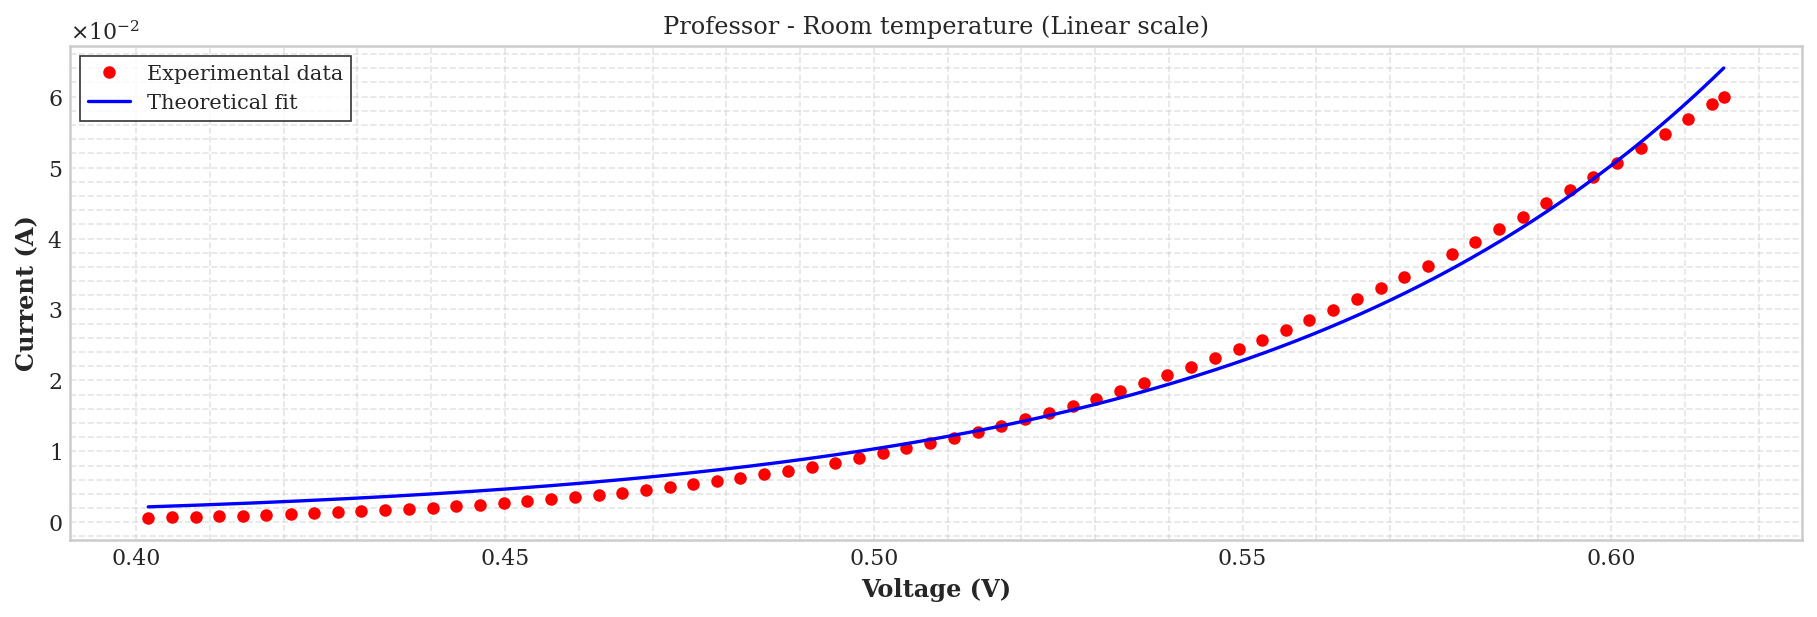


Professor - Nitrogen (Linear scale, fitting only kB)
   Is = 4.556e-19 A
   n  = 1.4621
   kB = 2.9569e-23 J/K
   R² = 0.99254
   χ² reduced = 0.00016
   Kolmogorov-Smirnov: D = 0.16807, p = 0.06926
The model passes the K-S test (p > 0.05).



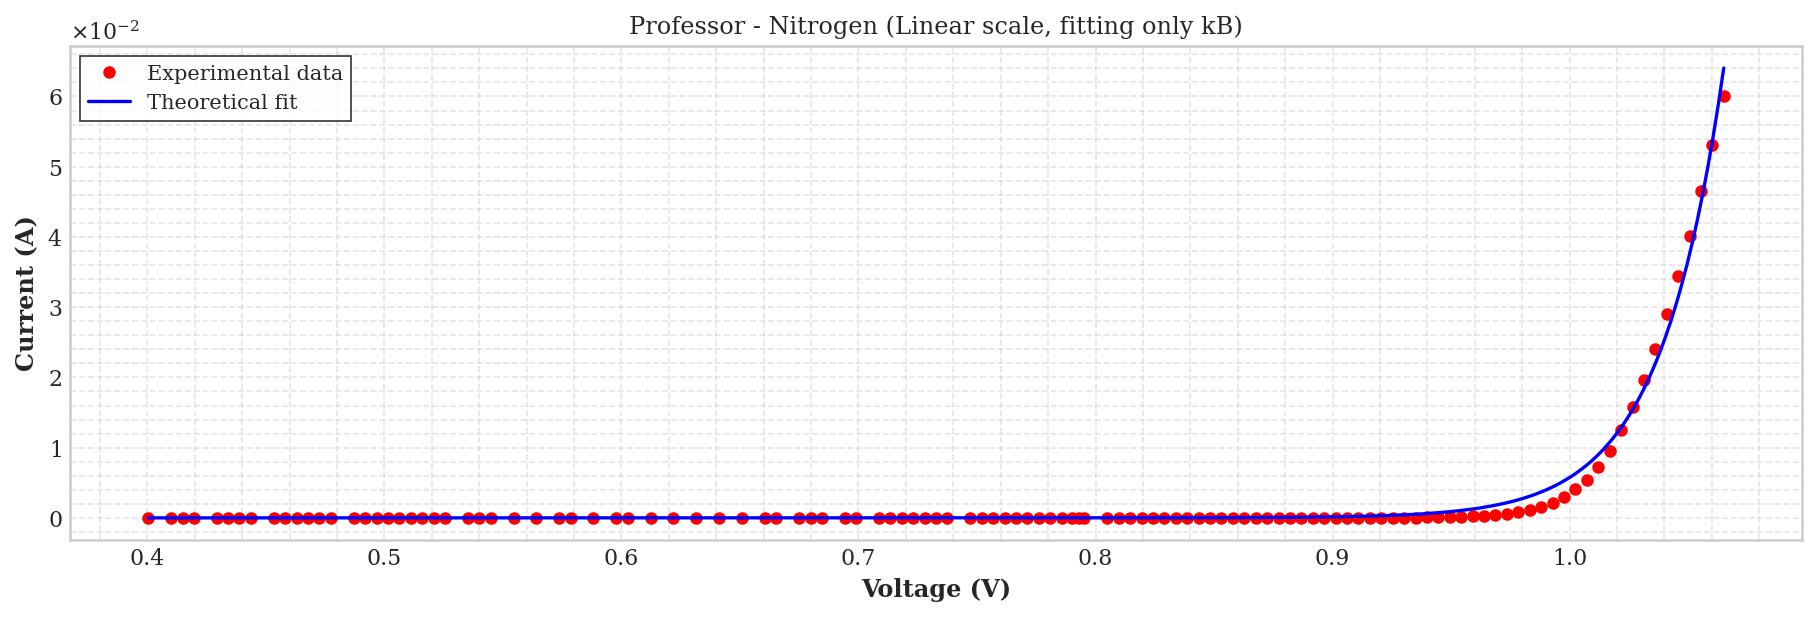

In [16]:
T_professor_room = 297.85
V_prof_room = np.array(professor_room_temperature_data["Value"])
I_prof_room = np.array(professor_room_temperature_data["Reading"])

mask = V_prof_room >= 0.4
V_prof_room = V_prof_room[mask]
I_prof_room = I_prof_room[mask]

fig, axs = plt.subplots(1, 1, figsize=(12, 4), constrained_layout=True)
res_room, _ = fit_and_plot(
    V_prof_room, I_prof_room, T_professor_room,
    p0=[1e-12, 1.0, kB_theoretical],
    title='Professor - Room temperature (Linear scale)',
    log_scale=False, ax=axs
)
plt.show()

# Fitting diode at liquid nitrogen temperature
# (only kB is fitted, keeping Is and n from room temperature)
T_nitrogen_professor = 99.95
V_prof_nit = np.array(professor_nitrogen_data["Value"])
I_prof_nit = np.array(professor_nitrogen_data["Reading"])

mask = V_prof_nit >= 0.4
V_prof_nit_t = V_prof_nit[mask]
I_prof_nit_t = I_prof_nit[mask]

fig, axs = plt.subplots(1, 1, figsize=(12, 4), constrained_layout=True)
res_nit, _ = fit_and_plot(
    V_prof_nit_t, I_prof_nit_t, T_nitrogen_professor,
    p0=[1e-26, 1.3e-23],
    title='Professor - Nitrogen (Linear scale, fitting only kB)',
    n_fixed=res_room["n"],
    log_scale=False, ax=axs
)
plt.show()

**Important note on the analysis of this notebook:** for the nitrogen and room temperature data, there will be moments when data masks (filters) are used to eliminate a certain amount of data that allows the curve_fit function to avoid divergences. However, it is always ensured that the amount of data is sufficient for a good representation of the sample and the I-V relationship.

In the figure corresponding to the professor's data at room temperature, with $T = 297.85 \, \text{K}$, a fitting of the diode current-voltage curve was performed using Shockley's equation on a linear scale with the Python Scipy "curve_fit" function. From the fit, the values $I_S = 3.784 \times 10^{-6} \, \text{A}$, $n = 1.4621$, and $k_B = 2.3245 \times 10^{-23} \, \text{J/K}$ were obtained. The fit quality is high, as indicated by the coefficient of determination $R^2 = 0.99070$ and the reduced chi-squared value $\chi^2 = 0.00040$. Additionally, the Kolmogorov-Smirnov test yielded $p = 0.16705$, which satisfies $p > 0.05$ and does not reject the hypothesis of model compatibility with the experimental data.

For the case of the diode submerged in liquid nitrogen, a fitting on linear scale was performed keeping the ideality factor $n = 1.4621$ fixed and fitting only the Boltzmann constant. In this case, a saturation current $I_S = 4.556 \times 10^{-19} \, \text{A}$ and a value of $k_B = 2.9569 \times 10^{-23} \, \text{J/K}$ were obtained. The fit again shows excellent agreement with the experimental data, with $R^2 = 0.99254$ and $\chi^2 = 0.00016$. The Kolmogorov-Smirnov test gave a value $p = 0.06926$, satisfying $p > 0.05$, which indicates that the Shockley model adequately describes the diode behavior at low temperatures.

## Our data analysis - ambient temperature


Our data - Room temperature (Linear scale)
   Is = 2.522e-09 A
   n  = 1.3835
   kB = 1.2729e-23 J/K
   R² = 0.91090
   χ² reduced = 0.00000
   Kolmogorov-Smirnov: D = 0.09375, p = 0.21079
The model passes the K-S test (p > 0.05).



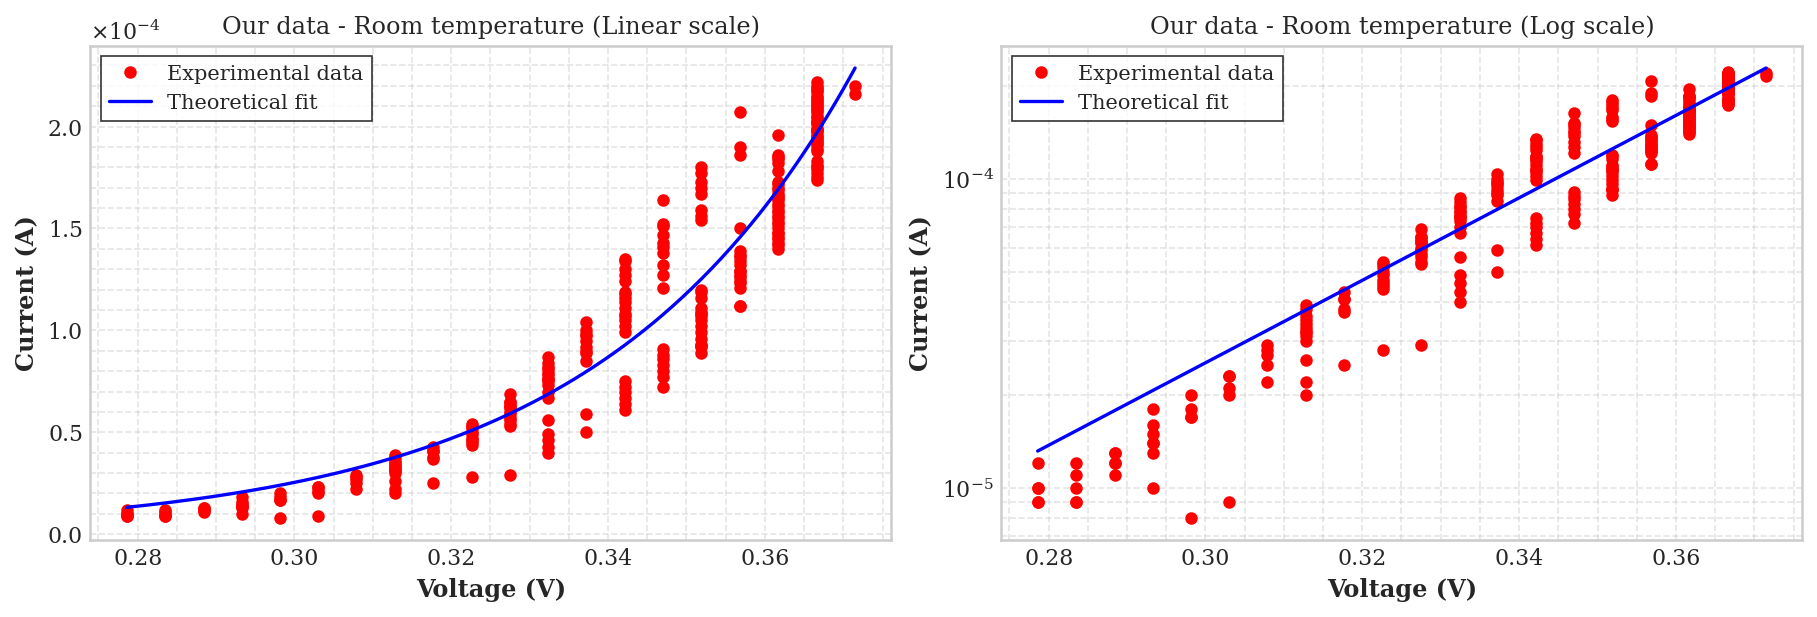

In [17]:
T_room = 296.05
V_our_room = np.array(diode_room_temperature["Vdiodo(V)"])
I_our_room = np.array(diode_room_temperature["Idiodo(A)"])

mask = V_our_room >= 0
V_our_room = V_our_room[mask]
I_our_room = I_our_room[mask]

fig, axs = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)

# Linear scale
res_our_room, _ = fit_and_plot(
    V_our_room, I_our_room, T_room,
    p0=[1e-12, 1.5, kB_theoretical],
    title='Our data - Room temperature (Linear scale)',
    log_scale=False, ax=axs[0]
)

# Logarithmic scale (visual only, without printing results again)
fit_and_plot(
    V_our_room, I_our_room, T_room,
    p0=[res_our_room["Is"], res_our_room["n"], res_our_room["kB"]],
    title='Our data - Room temperature (Log scale)',
    log_scale=True, show_results=False, ax=axs[1]
)

plt.show()

## Our data analysis - liquid nitrogen temperature


data_1_nitrogen
   Is = 1.851e-09 A
   n  = 1.6122
   kB = 8.0454e-23 J/K
   R² = 0.88270
   χ² reduced = 0.00000
   Kolmogorov-Smirnov: D = 0.11255, p = 0.10718
The model passes the K-S test (p > 0.05).


data_2_nitrogen
   Is = -3.657e-31 A
   n  = 1.6122
   kB = 1.3800e-23 J/K
   R² = -624876.35451
   χ² reduced = 0.03311
   Kolmogorov-Smirnov: D = 1.00000, p = 0.00000
The model does NOT pass the K-S test (p ≤ 0.05).


data_3_nitrogen
   Is = 2.109e-31 A
   n  = 1.6122
   kB = 1.3800e-23 J/K
   R² = -161518.88497
   χ² reduced = 0.01696
   Kolmogorov-Smirnov: D = 0.98551, p = 0.00000
The model does NOT pass the K-S test (p ≤ 0.05).


data_4_nitrogen
   Is = -2.690e-31 A
   n  = 1.6122
   kB = 1.3800e-23 J/K
   R² = -280104.92950
   χ² reduced = 0.02444
   Kolmogorov-Smirnov: D = 1.00000, p = 0.00000
The model does NOT pass the K-S test (p ≤ 0.05).


data_5_nitrogen
   Is = 3.949e-26 A
   n  = 1.6122
   kB = 1.8714e-23 J/K
   R² = 0.93664
   χ² reduced = 0.00000
   Kolmogorov-Smirno

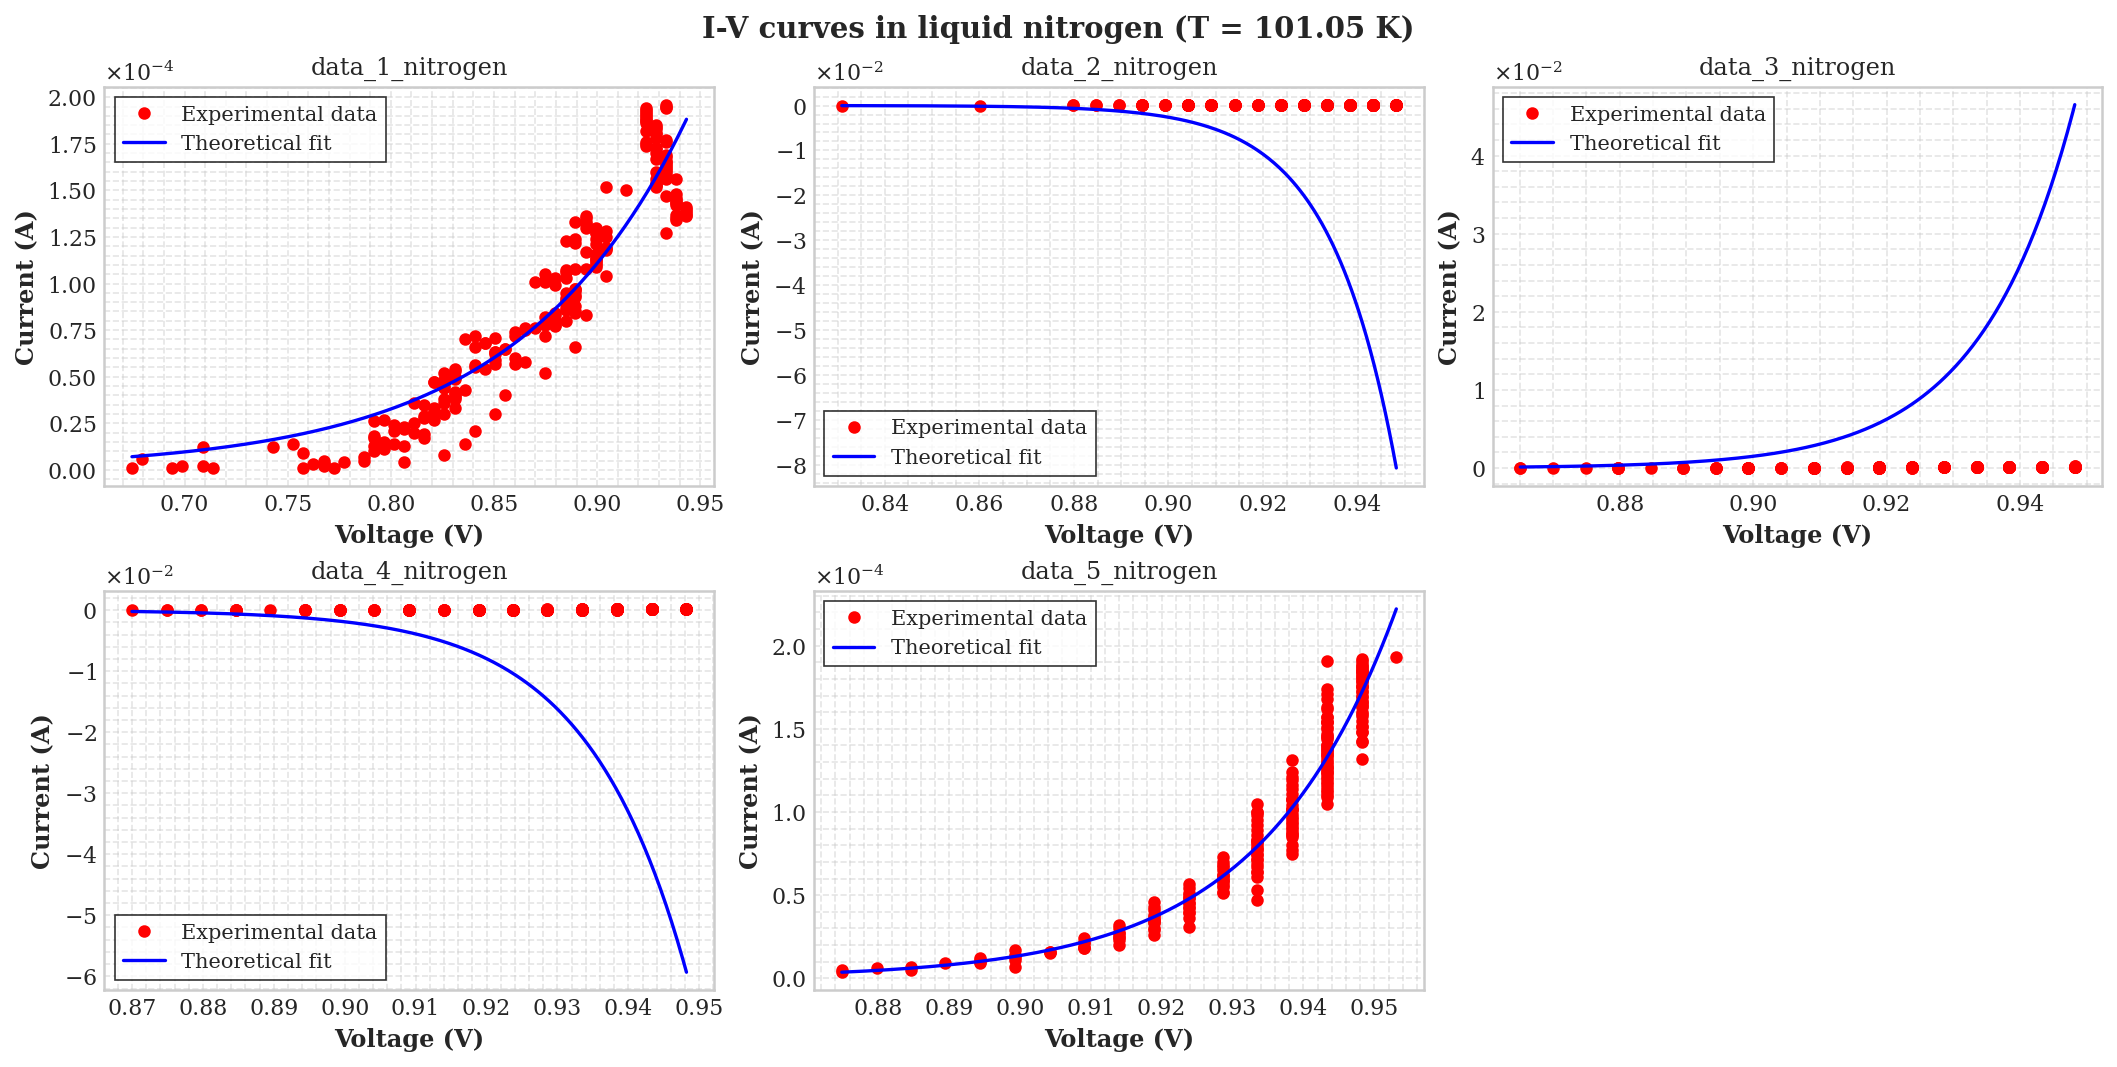

In [18]:
T_nitrogen = 101.05
n_fixed = 1.6122  # Experimentally determined value from the previous code block
p0_nit = [1e-17, kB_theoretical]  # Initial theoretical values: [Is, kB]

fig, axs = plt.subplots(2, 3, figsize=(14, 7), constrained_layout=True)
axs = axs.flatten()

nitrogen_results = {}  # To save results for each sample

for i, (name, df) in enumerate(nitrogen_data_dictionary.items()):
    V = np.array(df["Vdiodo(V)"])
    I = np.array(df["Idiodo(A)"])

    mask = V >= 0.55
    V = V[mask]
    I = I[mask]

    # Outlier removal using IQR method
    # which removes points that are outside 1.5 times the
    # interquartile range (IQR)
    Q1, Q3 = np.percentile(V, [25, 75])
    IQR = Q3 - Q1
    lower_lim, upper_lim = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    mask = (V >= lower_lim) & (V <= upper_lim)
    V, I = V[mask], I[mask]

    # Model fitting (Is and kB free, n fixed)
    results, _ = fit_and_plot(
        V, I, T_nitrogen, p0=p0_nit,
        title=f'{name}',
        log_scale=False,
        n_fixed=n_fixed,
        ax=axs[i]
    )

    # Results
    nitrogen_results[name] = results

# Remove empty axis number 6
for j in range(i + 1, len(axs)):
    fig.delaxes(axs[j])

plt.suptitle(f'I-V curves in liquid nitrogen (T = {T_nitrogen:.2f} K)',
             fontsize=14, fontweight='bold')
plt.show()

For the data obtained by us at room temperature, a linear scale fitting of the I-V curve was performed using Shockley's equation. From the fit, a saturation current $I_S = 2.522 \times 10^{-9} \, \text{A}$, an ideality factor $n = 1.3835$, and a value of the Boltzmann constant $k_B = 1.2729 \times 10^{-23} \, \text{J/K}$ were obtained. The coefficient of determination was $R^2 = 0.91090$, indicating acceptable agreement between the model and experimental data. Additionally, the Kolmogorov-Smirnov test yielded a value $p = 0.21079$, satisfying $p > 0.05$, so the model is not rejected and consistently describes the diode behavior at room temperature.

For the case of the diode at low temperature, five datasets collected under the same experimental conditions were analyzed. In the data_1_nitrogen set, $I_S = 1.851 \times 10^{-9} \, \text{A}$, $n = 1.6122$, and $k_B = 8.0454 \times 10^{-23} \, \text{J/K}$ were obtained, with acceptable fit reflected in $R^2 = 0.88270$ and a Kolmogorov-Smirnov test with $p = 0.10718$. Similarly, the data_5_nitrogen set showed values $I_S = 3.949 \times 10^{-26} \, \text{A}$ and $k_B = 1.8714 \times 10^{-23} \, \text{J/K}$, with good statistical fit characterized by $R^2 = 0.93664$ and $p = 0.10342$, again satisfying $p > 0.05$.

In contrast, the sets data_2_nitrogen, data_3_nitrogen, and data_4_nitrogen yielded non-physical saturation current values, strongly negative coefficients of determination, and Kolmogorov-Smirnov tests with $p = 0.00000$. In these cases, the model fails to adequately describe the experimental data, so these fits are not considered valid for quantitative analysis of diode parameters under cooling with liquid nitrogen.

# Conclusions

Based on the analysis of the diode semiconductor I-V curves at different temperatures, it is concluded that Shockley's equation adequately describes the electrical behavior of the device both at room temperature and at low temperatures, provided that the experimental data used meet minimum conditions of stability and representativeness. In the data provided by the professor with nanoammeter data, the fits performed show high values of $R^2$, reduced values of $\chi^2$, and Kolmogorov-Smirnov tests with $p > 0.05$, which supports the statistical validity of the model and allows consistent estimation of the parameters $I_S$, $n$, and $k_B$. In particular, a significant decrease in saturation current is observed when reducing the temperature, in agreement with the expected thermal dependence of charge transport in semiconductors.

In the case of the data obtained by us, the results at room temperature show acceptable agreement with the theoretical model, although with greater scatter compared to the professor's data, reflected in lower values of $R^2$. For the liquid nitrogen data, the analysis of five experimental sets shows that not all fits are statistically valid, even though the experimental conditions were similar. Only two sets present physical values of the parameters and pass the Kolmogorov-Smirnov test, while the others lead to non-physical saturation currents and fits incompatible with the model. This reveals the high sensitivity of nonlinear fitting to data selection, especially at low temperatures, and justifies the controlled use of data masks to avoid numerical divergences in the fitting algorithm. Furthermore, it provides the conclusion that data collected with a nanoammeter are much more detailed and accurate than those collected with Arduino by us.

# References

- [1] K. Sharp and F. Matschinsky, "Translation of Ludwig Boltzmann's Paper 'On the Relationship between the Second Fundamental Theorem of the Mechanical Theory of Heat and Probability Calculations Regarding the Conditions for Thermal Equilibrium' Sitzungberichte der Kaiserlichen Akademie der Wissenschaften. Mathematisch-Naturwissen Classe. Abt. II, LXXVI 1877, pp 373-435 (Wien. Ber. 1877, 76:373-435). Reprinted in Wiss. Abhandlungen, Vol. II, reprint 42, p. 164-223, Barth, Leipzig, 1909," Entropy, vol. 17, no. 4, pp. 1971-2009, Apr. 2015, doi: https://doi.org/10.3390/e17041971.

- [2] Mechanical Engineering Phénix, "The diode: What is it and what is it for? - Mechanical Engineering Phénix," Mechanical Engineering Phénix, Jul. 10, 2018. https://www.ingmecafenix.com/electronica/componentes/diodo-semiconductor/.

- [3] W. Shockley, "The Theory of p-n Junctions in Semiconductors and p-n Junction Transistors," Bell System Technical Journal, vol. 28, no. 3, pp. 435-489, Jul. 1949, doi: https://doi.org/10.1002/j.1538-7305.1949.tb03645.x.

- [4] alldatasheet.com, "STTH10002 Datasheet(PDF)," Alldatasheet.com, 2026. https://www.alldatasheet.com/datasheet-pdf/pdf/153426/STMICROELECTRONICS/STTH10002.html.